# Modified Determinat

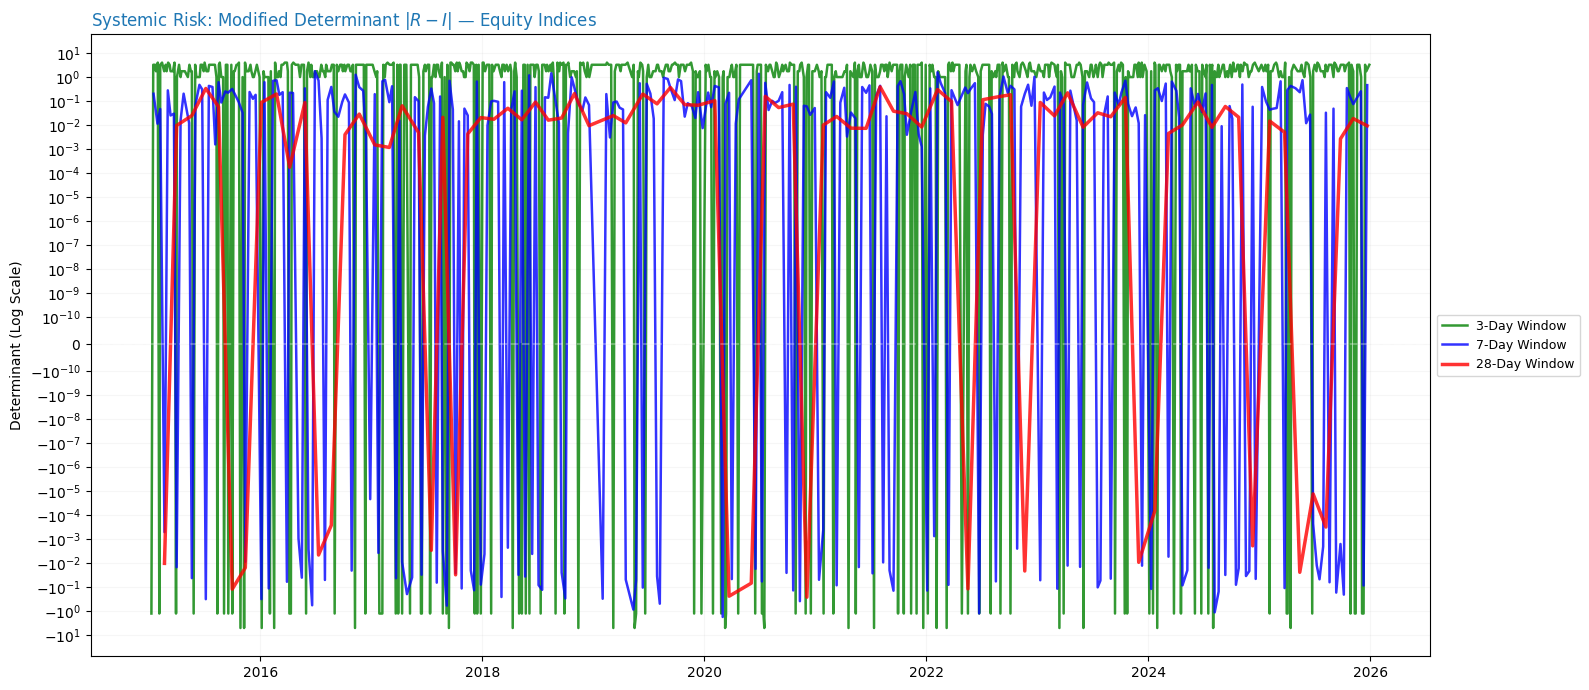

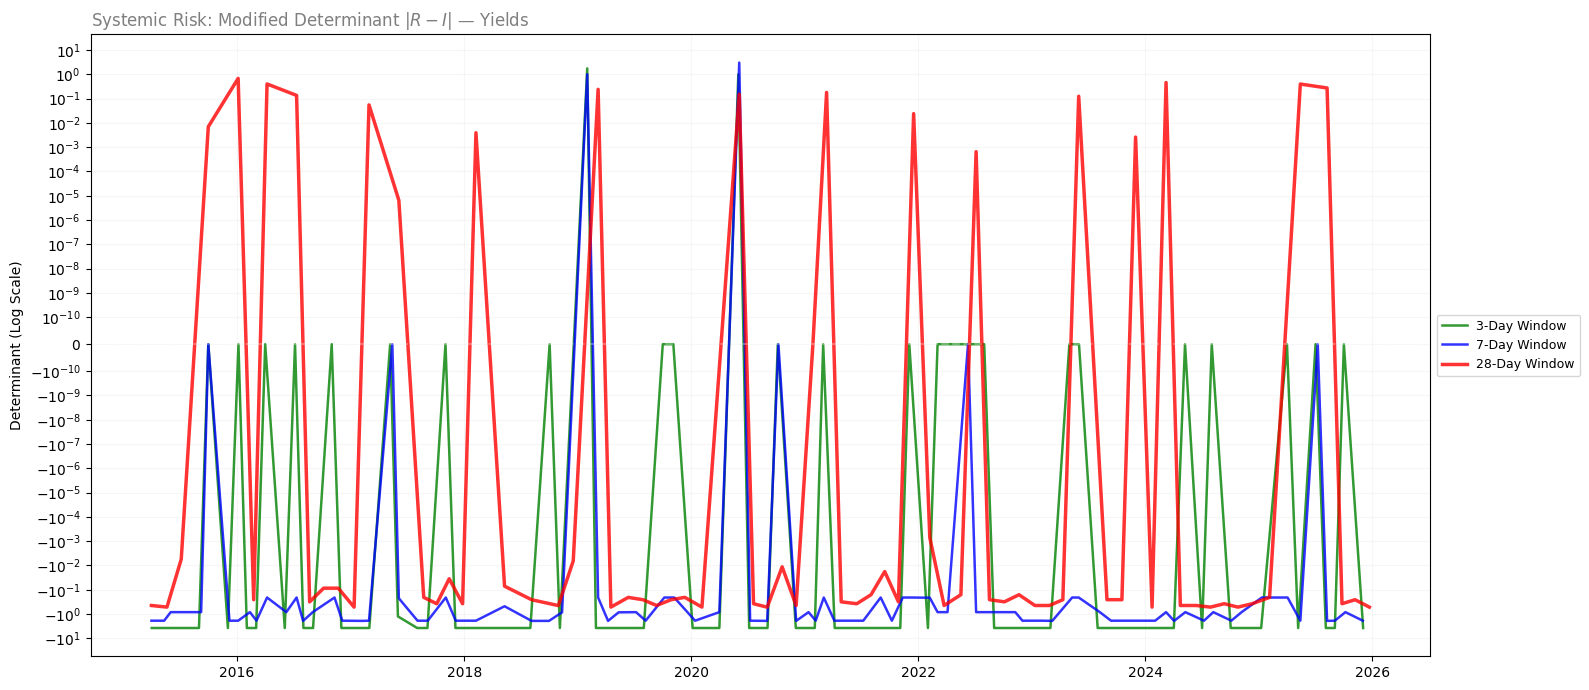

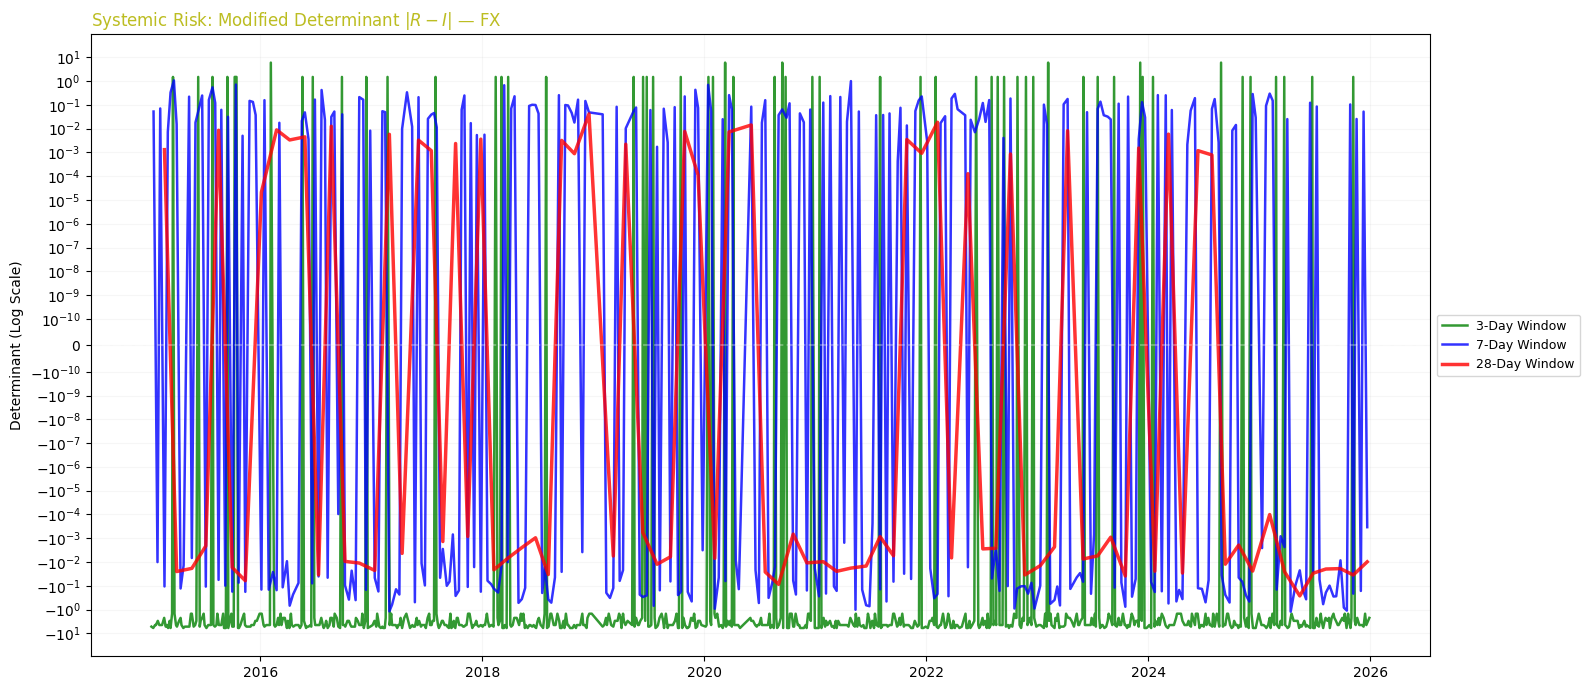

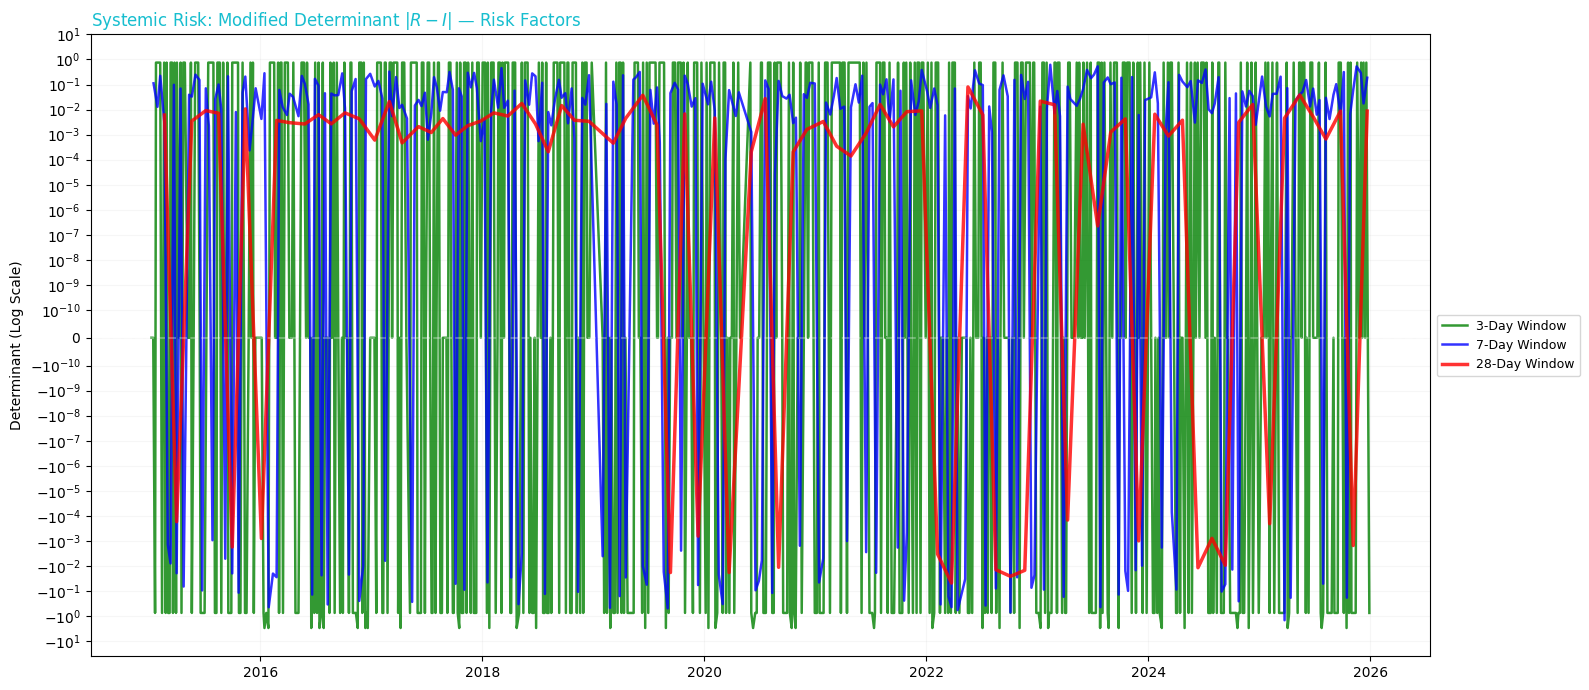

In [1]:
# @title
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
from io import StringIO
import hashlib

# 1. Load data from GitHub
def load_data_from_github():
    base_url = "https://raw.githubusercontent.com/kboroz/MSFE_Capstone_Project/main/01_Data/Streamlined/"
    files = [
        "streamlined_asx_50.csv",
        "streamlined_euro_stoxx_50.csv",
        "streamlined_ftse_100.csv",
        "streamlined_ibovespa.csv",
        "streamlined_jse_top_40.csv",
        "streamlined_macro.csv",
        "streamlined_nikkei_225.csv",
        "streamlined_s&p_500.csv"
    ]
    all_data = {}
    for file in files:
        url = base_url + file
        try:
            response = requests.get(url)
            response.raise_for_status()
            data = pd.read_csv(StringIO(response.text), index_col=0, parse_dates=True)
            data.columns = data.columns.str.replace('[^a-zA-Z0-9]', '_', regex=True)
            all_data[file.replace("streamlined_", "").replace(".csv", "").upper()] = data
        except Exception as e:
            print(f"Error loading {file}: {str(e)}")
            continue
    if not all_data:
        raise ValueError("No data files could be loaded.")
    return all_data

# 2. Configuration
DET_WINDOWS = [3, 7, 28]
WINDOW_COLORS = {
    3: 'green',
    7: 'blue',
    28: 'red'
}

# Index colors for consistent visualization
INDEX_COLORS = {
    'SP500': '#1f77b4',  # Blue
    'BOVESPA': '#ff7f0e',  # Orange
    'EUROSTOXX50': '#2ca02c',  # Green
    'FTSE100': '#d62728',  # Red
    'JSE40': '#9467bd',  # Purple
    'NIKKEI225': '#8c564b',  # Brown
    'ASX50': '#e377c2',  # Pink
    'Yields': '#7f7f7f',  # Gray
    'FX': '#bcbd22',  # Olive
    'Risk Factors': '#17becf'  # Cyan
}

# 3. Core Functions
def calculate_modified_determinant(corr_matrix):
    """Calculates det(R - I) to measure systemic coupling."""
    if corr_matrix.empty or corr_matrix.isnull().values.any():
        return np.nan
    clean_matrix = corr_matrix.dropna(axis=0, how='all').dropna(axis=1, how='all')
    if clean_matrix.shape[0] < 2:
        return np.nan
    mat = clean_matrix.to_numpy()
    identity = np.eye(mat.shape[0])
    try:
        return np.linalg.det(mat - identity)
    except np.linalg.LinAlgError:
        return np.nan

# 4. Main Analysis
def run_systemic_risk_analysis():
    # Load data
    all_data = load_data_from_github()
    all_assets = pd.concat(all_data.values(), axis=1)
    all_assets = all_assets.loc[:, ~all_assets.columns.duplicated()]

    # Calculate returns
    simple_returns = all_assets.pct_change().dropna()

    # Group assets
    asset_groups = {
        'Equity Indices': ['SP500', 'BOVESPA', 'EUROSTOXX50', 'FTSE100', 'JSE40', 'NIKKEI225', 'ASX50'],
        'Yields': [c for c in all_assets.columns if '10Y' in c],
        'FX': [c for c in all_assets.columns if any(x in c for x in ['USD', 'EUR', 'GBP'])],
        'Risk Factors': ['Gold', 'Oil', 'VIX', 'Bitcoin']
    }

    # Analyze each group
    for group_name, cols in asset_groups.items():
        valid_cols = [c for c in cols if c in simple_returns.columns]
        if len(valid_cols) < 2: continue

        plt.figure(figsize=(16, 7))
        group_returns = simple_returns[valid_cols]

        # Get group color
        color_key = 'SP500' if group_name == 'Equity Indices' else group_name
        group_color = INDEX_COLORS.get(color_key, '#ffffff')

        # Calculate and plot determinants
        for window in DET_WINDOWS:
            det_history = []
            for start in range(0, len(group_returns) - window, window):
                window_slice = group_returns.iloc[start:start+window]
                if window_slice.isnull().values.any():
                    continue
                corr_mat = window_slice.corr(method='spearman')
                det_val = calculate_modified_determinant(corr_mat)
                if not np.isnan(det_val):
                    det_history.append({'Date': window_slice.index[-1], 'Det': det_val})

            if det_history:
                df_det = pd.DataFrame(det_history).set_index('Date')
                plt.plot(df_det.index, df_det['Det'],
                        label=f'{window}-Day Window',
                        color=WINDOW_COLORS[window],
                        alpha=0.8,
                        linewidth=2.5 if window == 28 else 1.8)

        # Format plot
        plt.yscale('symlog', linthresh=1e-10)
        plt.axhline(0, color='white', linestyle='--', alpha=0.3)
        plt.title(f'Systemic Risk: Modified Determinant $|R - I|$ — {group_name}', loc='left', color=group_color)
        plt.ylabel('Determinant (Log Scale)')
        plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=9)
        plt.grid(True, alpha=0.1)
        plt.tight_layout()
        plt.show()

# Run the analysis
run_systemic_risk_analysis()


In [3]:
all_data = load_data_from_github()

for name, df in all_data.items():
    print(f"{name}: {df.shape[1]} columns → {df.columns.tolist()[:4]}")

ASX_50: 44 columns → ['ALD_AX', 'ALL_AX', 'ANZ_AX', 'APA_AX']
EURO_STOXX_50: 46 columns → ['ABI_BR', 'AD_AS', 'ADS_DE', 'AI_PA']
FTSE_100: 90 columns → ['AAL_L', 'ABF_L', 'ADM_L', 'ALW_L']
IBOVESPA: 56 columns → ['ABEV3_SA', 'ALPA4_SA', 'AMER3_SA', 'B3SA3_SA']
JSE_TOP_40: 31 columns → ['ABG_JO', 'AGL_JO', 'ANG_JO', 'APN_JO']
MACRO: 23 columns → ['AUDUSD', 'BRLUSD', 'Bitcoin', 'Oil']
NIKKEI_225: 217 columns → ['1332_T', '1605_T', '1721_T', '1801_T']
S&P_500: 460 columns → ['A', 'AAPL', 'ABBV', 'ABT']


In [4]:
for name, df in all_data.items():
    if name != 'MACRO':
        print(f"\n{name}")
        print(f"  Shape: {df.shape}")
        print(f"  Dtypes sample: {df.dtypes.value_counts().to_dict()}")
        print(f"  NaN %: {(df.isnull().sum().sum() / df.size * 100):.1f}%")
        print(f"  First 3 cols: {df.columns[:3].tolist()}")



ASX_50
  Shape: (2413, 44)
  Dtypes sample: {dtype('float64'): 44}
  NaN %: 0.0%
  First 3 cols: ['ALD_AX', 'ALL_AX', 'ANZ_AX']

EURO_STOXX_50
  Shape: (2413, 46)
  Dtypes sample: {dtype('float64'): 46}
  NaN %: 0.0%
  First 3 cols: ['ABI_BR', 'AD_AS', 'ADS_DE']

FTSE_100
  Shape: (2413, 90)
  Dtypes sample: {dtype('float64'): 90}
  NaN %: 0.0%
  First 3 cols: ['AAL_L', 'ABF_L', 'ADM_L']

IBOVESPA
  Shape: (2413, 56)
  Dtypes sample: {dtype('float64'): 56}
  NaN %: 0.0%
  First 3 cols: ['ABEV3_SA', 'ALPA4_SA', 'AMER3_SA']

JSE_TOP_40
  Shape: (2413, 31)
  Dtypes sample: {dtype('float64'): 31}
  NaN %: 0.0%
  First 3 cols: ['ABG_JO', 'AGL_JO', 'ANG_JO']

NIKKEI_225
  Shape: (2413, 217)
  Dtypes sample: {dtype('float64'): 217}
  NaN %: 0.0%
  First 3 cols: ['1332_T', '1605_T', '1721_T']

S&P_500
  Shape: (2413, 460)
  Dtypes sample: {dtype('float64'): 460}
  NaN %: 0.0%
  First 3 cols: ['A', 'AAPL', 'ABBV']


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# CONFIGURATION
# ============================================================

DET_WINDOWS = [3, 7, 28]

WINDOW_COLORS = {
    3:  'green',
    7:  'blue',
    28: 'red'
}

INDEX_FILES = ['ASX_50', 'EURO_STOXX_50', 'FTSE_100',
               'IBOVESPA', 'JSE_TOP_40', 'NIKKEI_225', 'S&P_500']

# ============================================================
# CORE FUNCTION
# ============================================================

def calculate_modified_determinant(corr_matrix: pd.DataFrame) -> float:
    """
    Computes det(R - I) on a correlation matrix R.
    - Large negative → high systemic coupling
    - Near zero     → diversified / low coupling
    - Positive      → mixed correlation structure
    """
    if corr_matrix.empty or corr_matrix.isnull().values.any():
        return np.nan
    mat = corr_matrix.to_numpy()
    identity = np.eye(mat.shape[0])
    try:
        return np.linalg.det(mat - identity)
    except np.linalg.LinAlgError:
        return np.nan


# ============================================================
# DETERMINANT CALCULATION PER INDEX
# ============================================================

def compute_determinants(all_data: dict,
                         windows: list = DET_WINDOWS) -> dict:
    """
    For each index, compute rolling det(R - I) over non-overlapping
    windows of 3, 7, 28 days using Spearman correlation across stocks.

    Returns:
        det_results: {
            index_name: {
                window: pd.Series (Date → determinant value)
            }
        }
    """
    det_results = {}

    for index_name in INDEX_FILES:
        if index_name not in all_data:
            print(f"⚠️  {index_name} not found in loaded data. Skipping.")
            continue

        price_df = all_data[index_name]

        # Log returns — more stable than pct_change for large matrices
        log_returns = np.log(price_df / price_df.shift(1)).dropna()

        det_results[index_name] = {}

        for window in windows:
            det_history = []

            # Non-overlapping windows
            for start in range(0, len(log_returns) - window, window):
                window_slice = log_returns.iloc[start : start + window]

                # Skip if any NaN survived
                if window_slice.isnull().values.any():
                    continue

                # Need at least 2 rows to compute correlation
                if window_slice.shape[0] < 2:
                    continue

                corr_mat = window_slice.corr(method='spearman')
                det_val  = calculate_modified_determinant(corr_mat)

                if not np.isnan(det_val):
                    det_history.append({
                        'Date': window_slice.index[-1],
                        'Det':  det_val
                    })

            if det_history:
                series = (pd.DataFrame(det_history)
                            .set_index('Date')['Det'])
                det_results[index_name][window] = series
                print(f"  ✅ {index_name} | {window}-day window "
                      f"→ {len(series)} observations")
            else:
                print(f"  ⚠️  {index_name} | {window}-day window → no valid observations")

    return det_results


# ============================================================
# RUN
# ============================================================

print("Computing modified determinants...\n")
det_results = compute_determinants(all_data)
print("\nDone.")


Computing modified determinants...

  ✅ ASX_50 | 3-day window → 798 observations
  ✅ ASX_50 | 7-day window → 344 observations
  ✅ ASX_50 | 28-day window → 86 observations
  ✅ EURO_STOXX_50 | 3-day window → 801 observations
  ✅ EURO_STOXX_50 | 7-day window → 344 observations
  ✅ EURO_STOXX_50 | 28-day window → 86 observations
  ✅ FTSE_100 | 3-day window → 798 observations
  ✅ FTSE_100 | 7-day window → 344 observations
  ✅ FTSE_100 | 28-day window → 86 observations
  ✅ IBOVESPA | 3-day window → 450 observations
  ✅ IBOVESPA | 7-day window → 205 observations
  ✅ IBOVESPA | 28-day window → 61 observations
  ✅ JSE_TOP_40 | 3-day window → 771 observations
  ✅ JSE_TOP_40 | 7-day window → 343 observations
  ✅ JSE_TOP_40 | 28-day window → 86 observations
  ✅ NIKKEI_225 | 3-day window → 773 observations
  ✅ NIKKEI_225 | 7-day window → 339 observations
  ✅ NIKKEI_225 | 28-day window → 85 observations
  ✅ S&P_500 | 3-day window → 496 observations
  ✅ S&P_500 | 7-day window → 275 observations
  ✅ S

# Sign Detection

det(R-I) 	Interpretation 	Portfolio Action

R - I removes the diagonal (self-correlation)

det(R - I) captures purely the off-diagonal structure

Large negative 	High systemic coupling 	Reduce exposure

Near zero 	Low coupling / diversified 	Neutral

Positive 	Mixed correlation structure 	Increase exposure

# Signal Generation Function

In [6]:
# ============================================================
# STEP 2 — SIGN SIGNAL EXTRACTION
# ============================================================

def extract_sign_signals(det_results: dict) -> dict:
    """
    For each index and each window, extract:
      - sign       : +1 (positive det) or -1 (negative det)
      - sign_change: transition events (+2, -2, 0)
      - regime     : RISK_ON / RISK_OFF label

    Convention:
      det > 0  → low systemic coupling → RISK_OFF (safe to invest)
      det < 0  → high systemic coupling → RISK_ON  (reduce exposure)

    Returns:
        signal_results: {
            index_name: {
                window: pd.DataFrame with columns
                        [Det, Sign, Sign_Change, Regime]
            }
        }
    """
    signal_results = {}

    for index_name, windows in det_results.items():
        signal_results[index_name] = {}

        for window, det_series in windows.items():

            df = det_series.to_frame(name='Det')

            # Sign: +1 or -1 (zero det is treated as RISK_ON conservatively)
            df['Sign'] = np.where(df['Det'] > 0, 1, -1)

            # Sign change: captures regime transitions
            # +2 = moved from -1 to +1 (RISK_ON → RISK_OFF)
            # -2 = moved from +1 to -1 (RISK_OFF → RISK_ON)
            #  0 = no change
            df['Sign_Change'] = df['Sign'].diff().fillna(0)

            # Regime label
            df['Regime'] = np.where(df['Sign'] == 1, 'RISK_OFF', 'RISK_ON')

            signal_results[index_name][window] = df

    return signal_results


# ============================================================
# RUN + QUICK DIAGNOSTIC
# ============================================================

signal_results = extract_sign_signals(det_results)

print("=" * 60)
print("SIGN SIGNAL SUMMARY — Last 5 observations per index/window")
print("=" * 60)

for index_name, windows in signal_results.items():
    print(f"\n{'─'*50}")
    print(f"  {index_name}")
    print(f"{'─'*50}")

    for window, df in windows.items():
        n_risk_on  = (df['Regime'] == 'RISK_ON').sum()
        n_risk_off = (df['Regime'] == 'RISK_OFF').sum()
        n_trans    = (df['Sign_Change'] != 0).sum()

        print(f"\n  {window}-day window | "
              f"RISK_ON: {n_risk_on} | "
              f"RISK_OFF: {n_risk_off} | "
              f"Transitions: {n_trans}")
        print(df[['Det', 'Sign', 'Regime']].tail(3).to_string())


SIGN SIGNAL SUMMARY — Last 5 observations per index/window

──────────────────────────────────────────────────
  ASX_50
──────────────────────────────────────────────────

  3-day window | RISK_ON: 0 | RISK_OFF: 798 | Transitions: 0
               Det  Sign    Regime
Date                              
2025-12-11  440.00     1  RISK_OFF
2025-12-17  422.00     1  RISK_OFF
2025-12-22  431.25     1  RISK_OFF

  7-day window | RISK_ON: 5 | RISK_OFF: 339 | Transitions: 8
                     Det  Sign    Regime
Date                                    
2025-11-28  25699.739412     1  RISK_OFF
2025-12-09  32729.665020     1  RISK_OFF
2025-12-19  26899.457997     1  RISK_OFF

  28-day window | RISK_ON: 32 | RISK_OFF: 54 | Transitions: 32
                 Det  Sign   Regime
Date                               
2025-09-22 -0.000026    -1  RISK_ON
2025-11-05 -0.000075    -1  RISK_ON
2025-12-19 -0.000164    -1  RISK_ON

──────────────────────────────────────────────────
  EURO_STOXX_50
─────────────

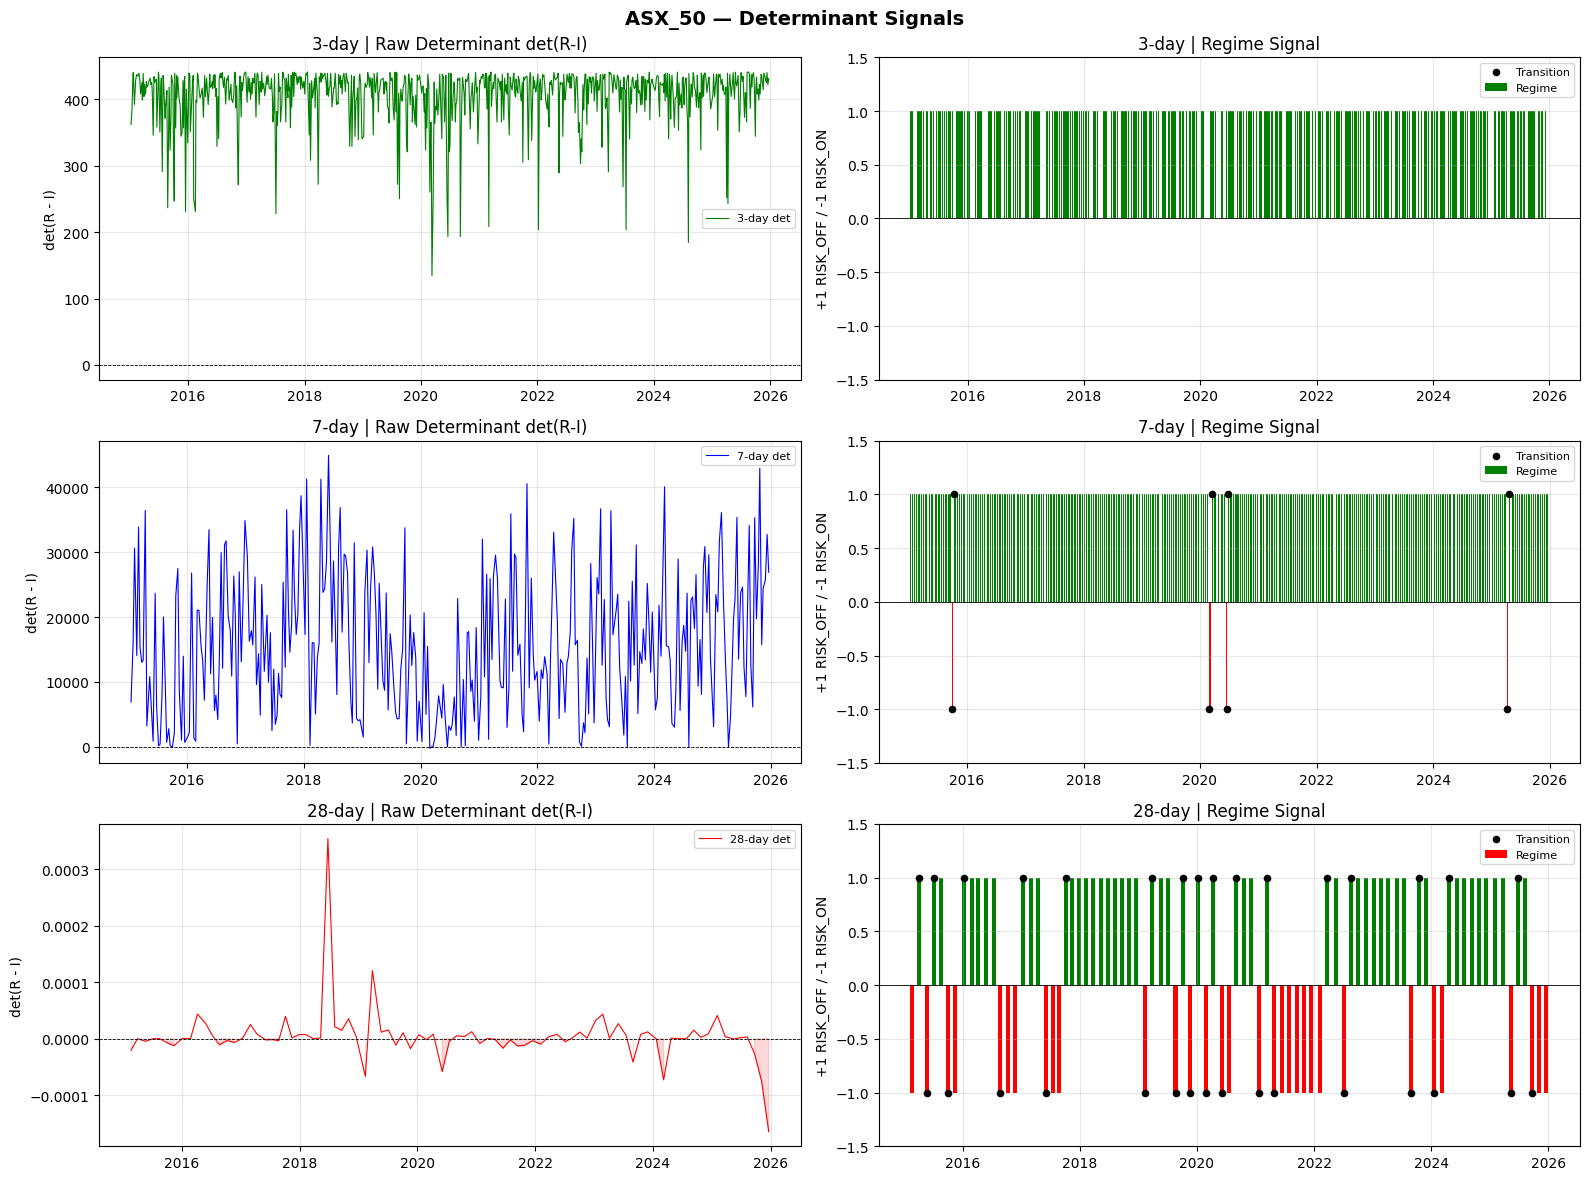

  ✅ Saved: ASX_50_determinant_signals.png


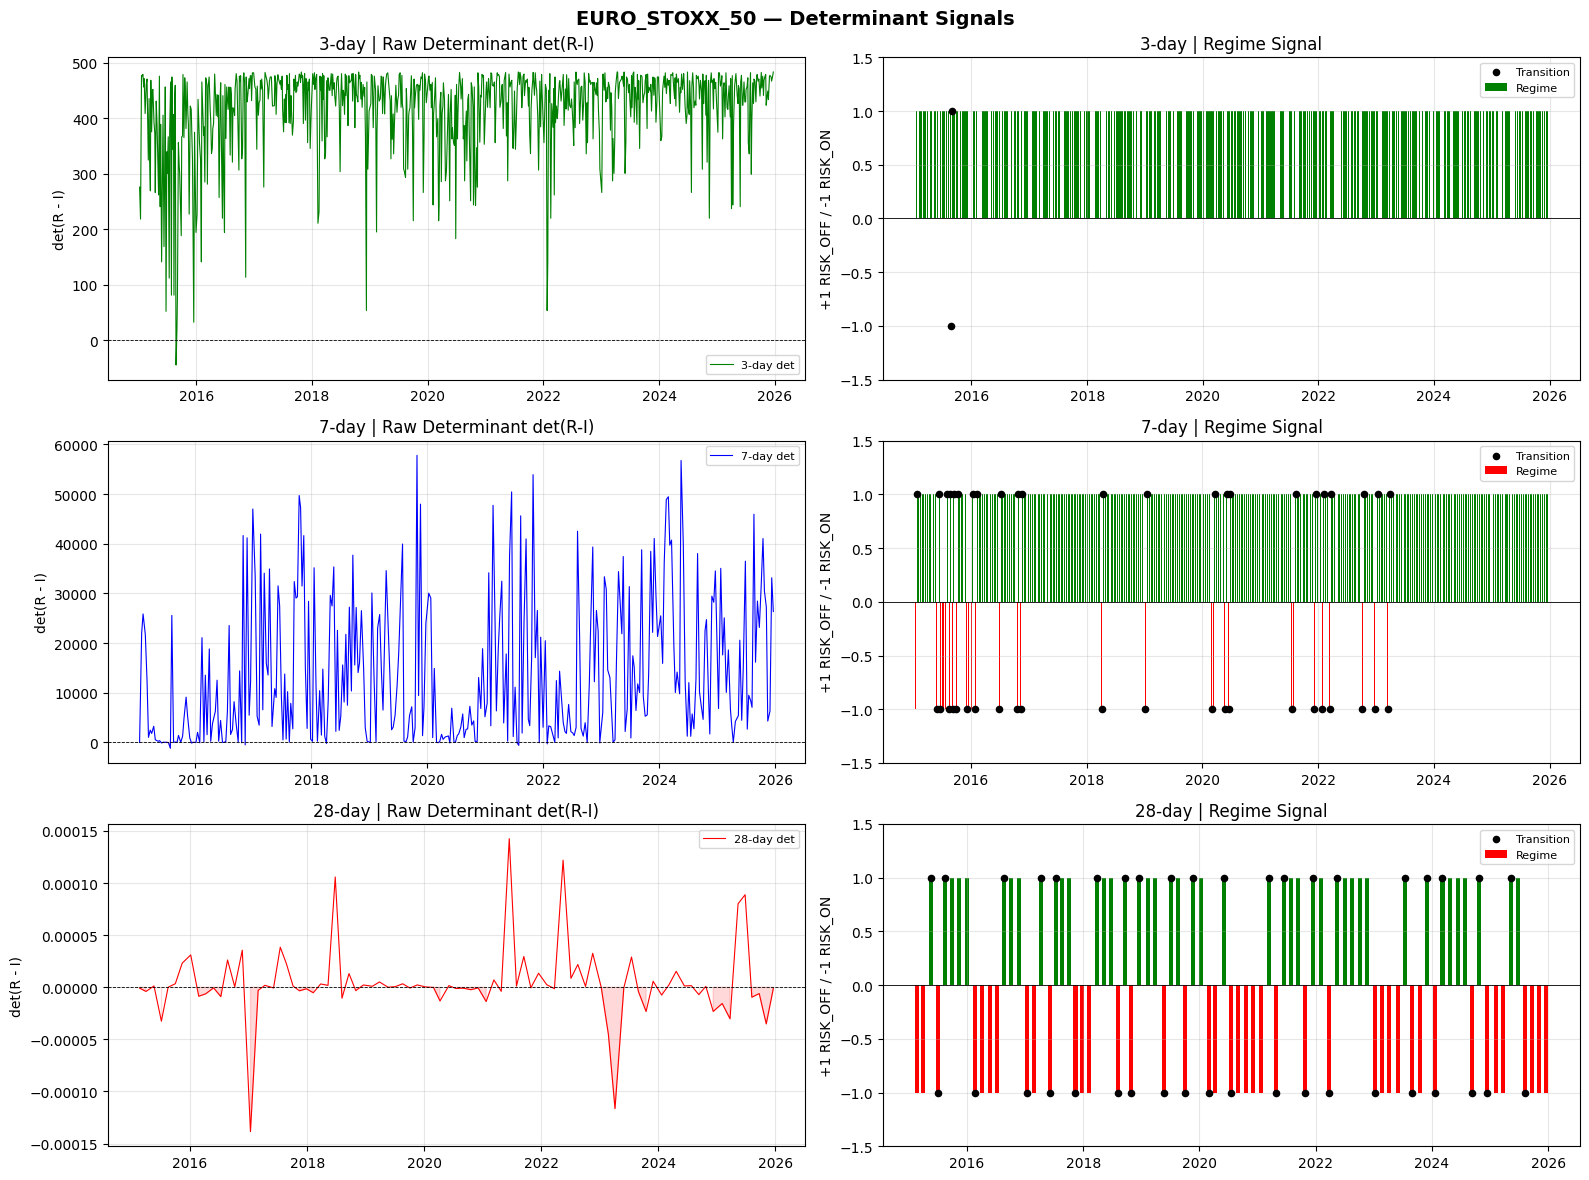

  ✅ Saved: EURO_STOXX_50_determinant_signals.png


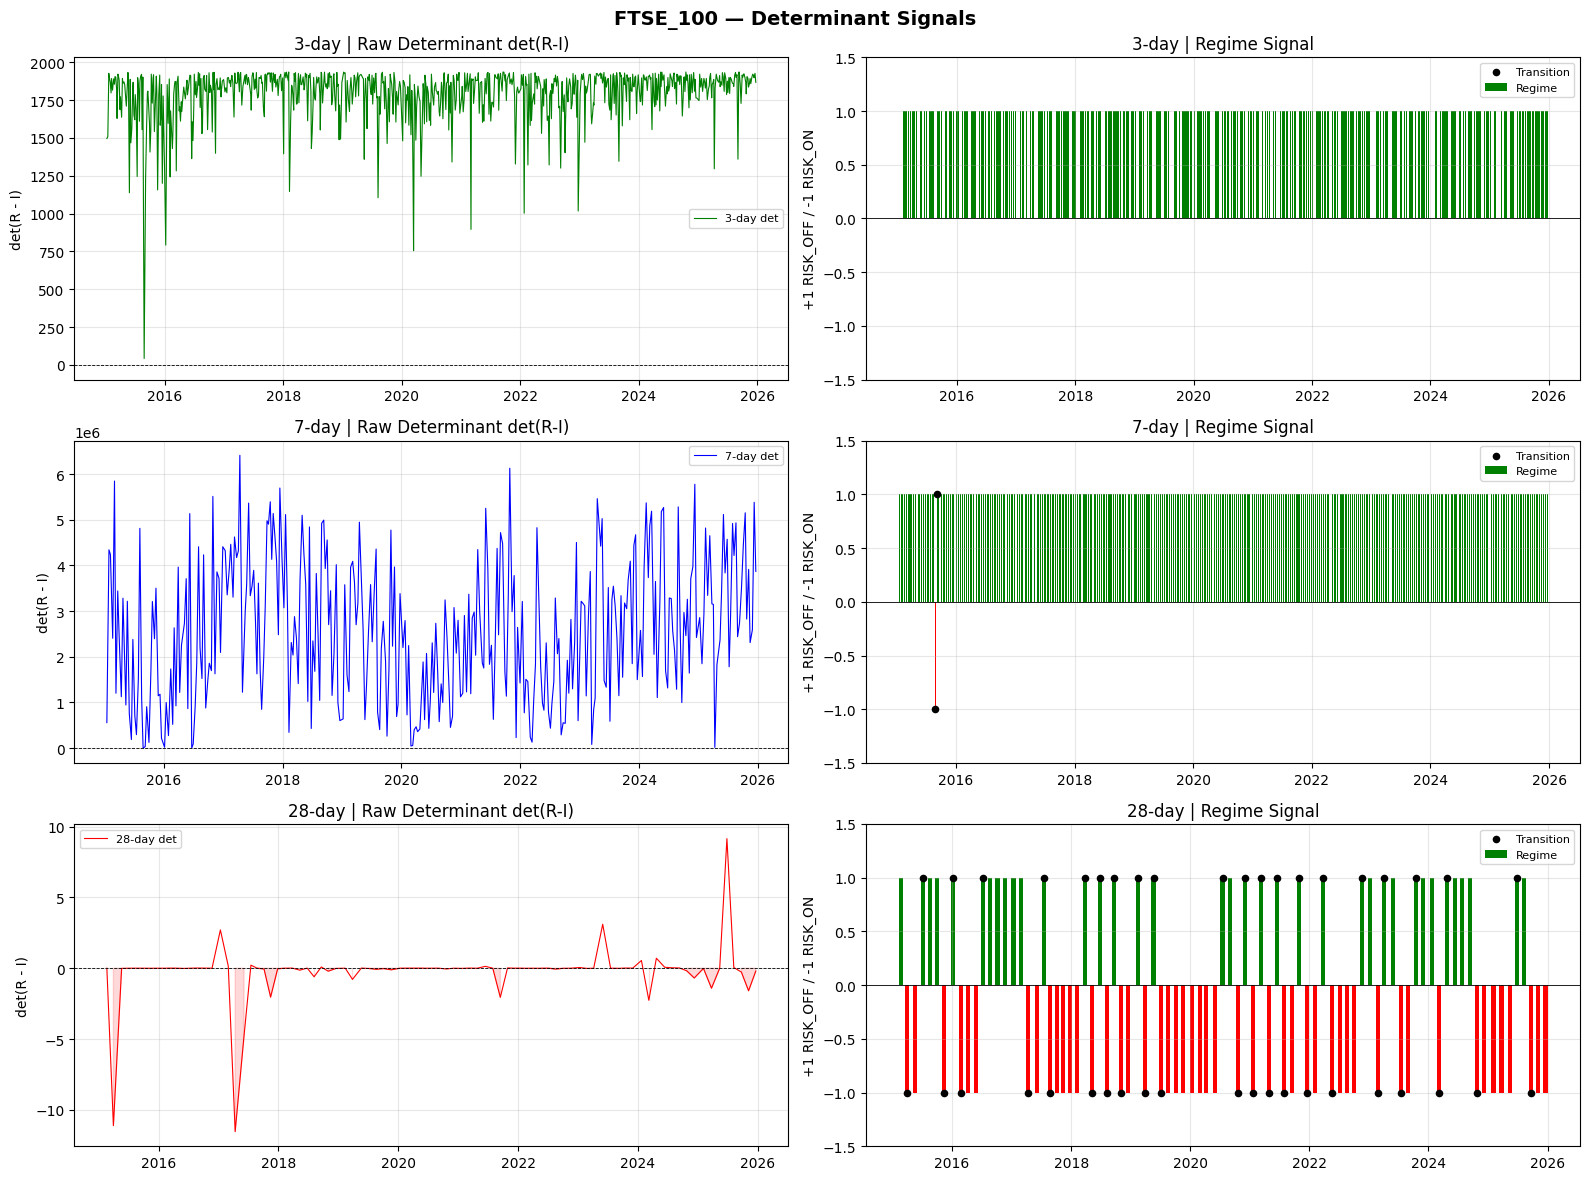

  ✅ Saved: FTSE_100_determinant_signals.png


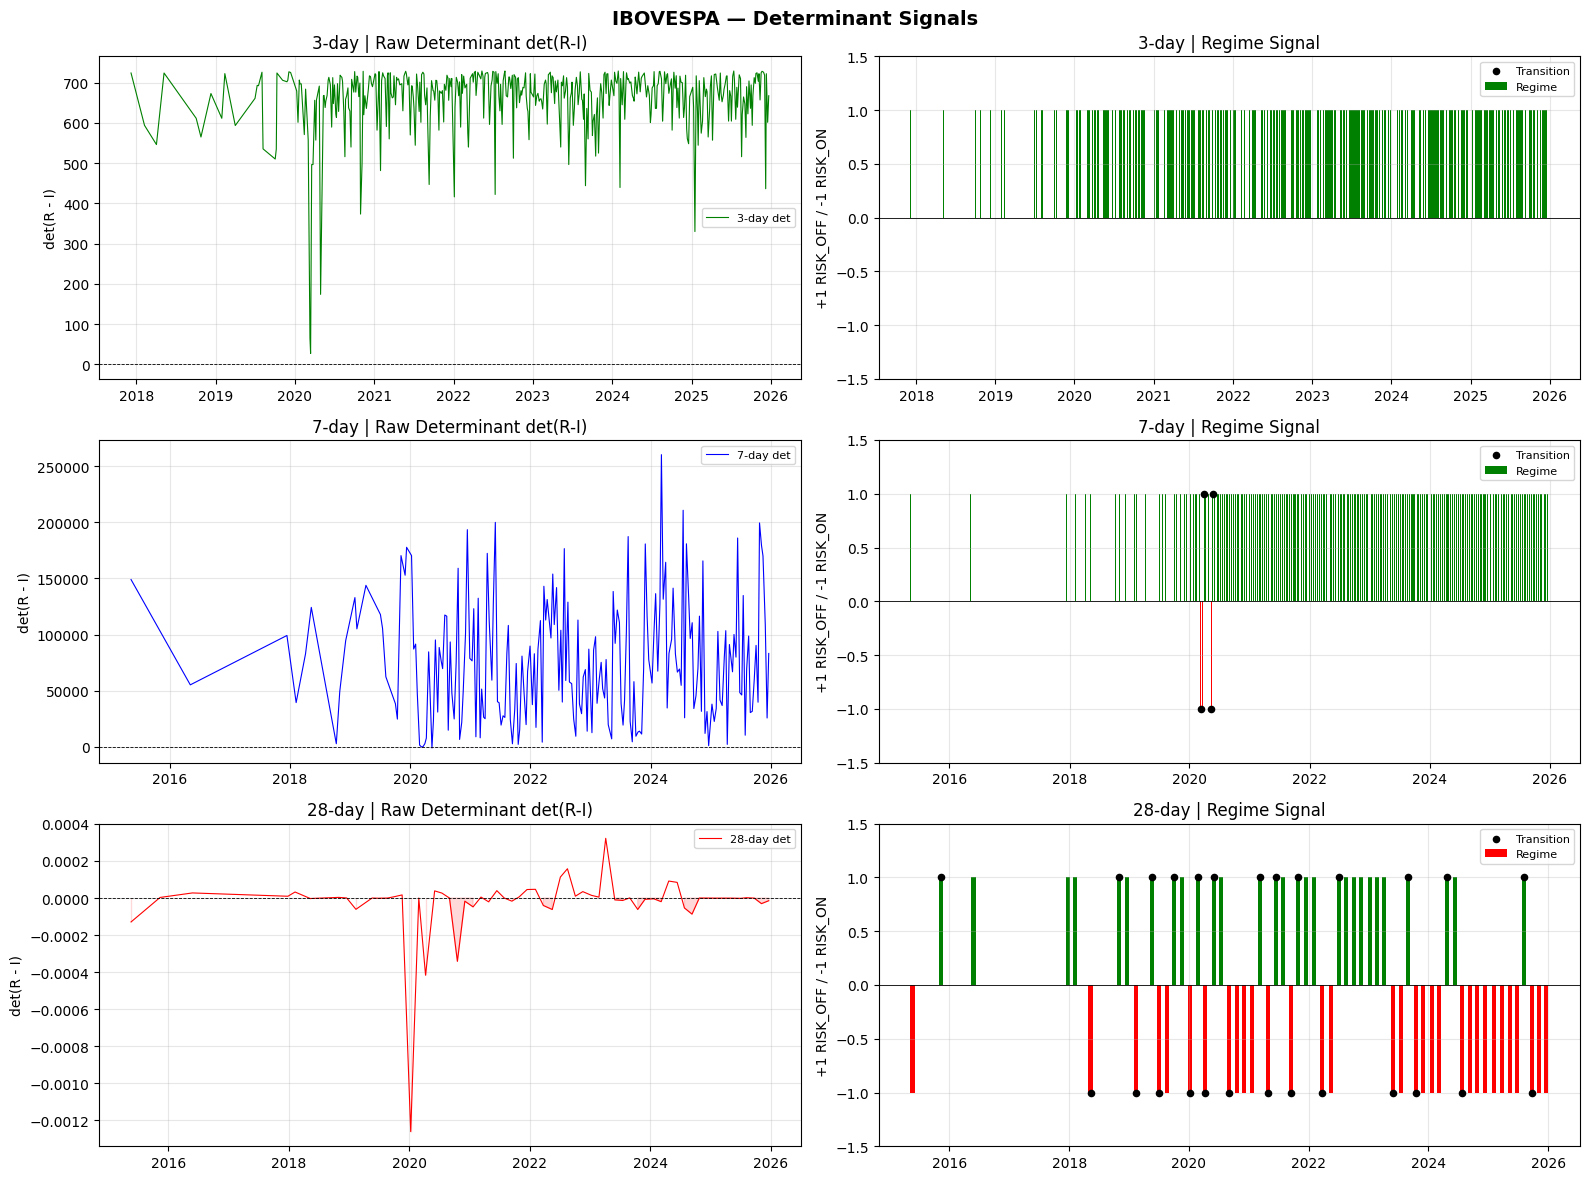

  ✅ Saved: IBOVESPA_determinant_signals.png


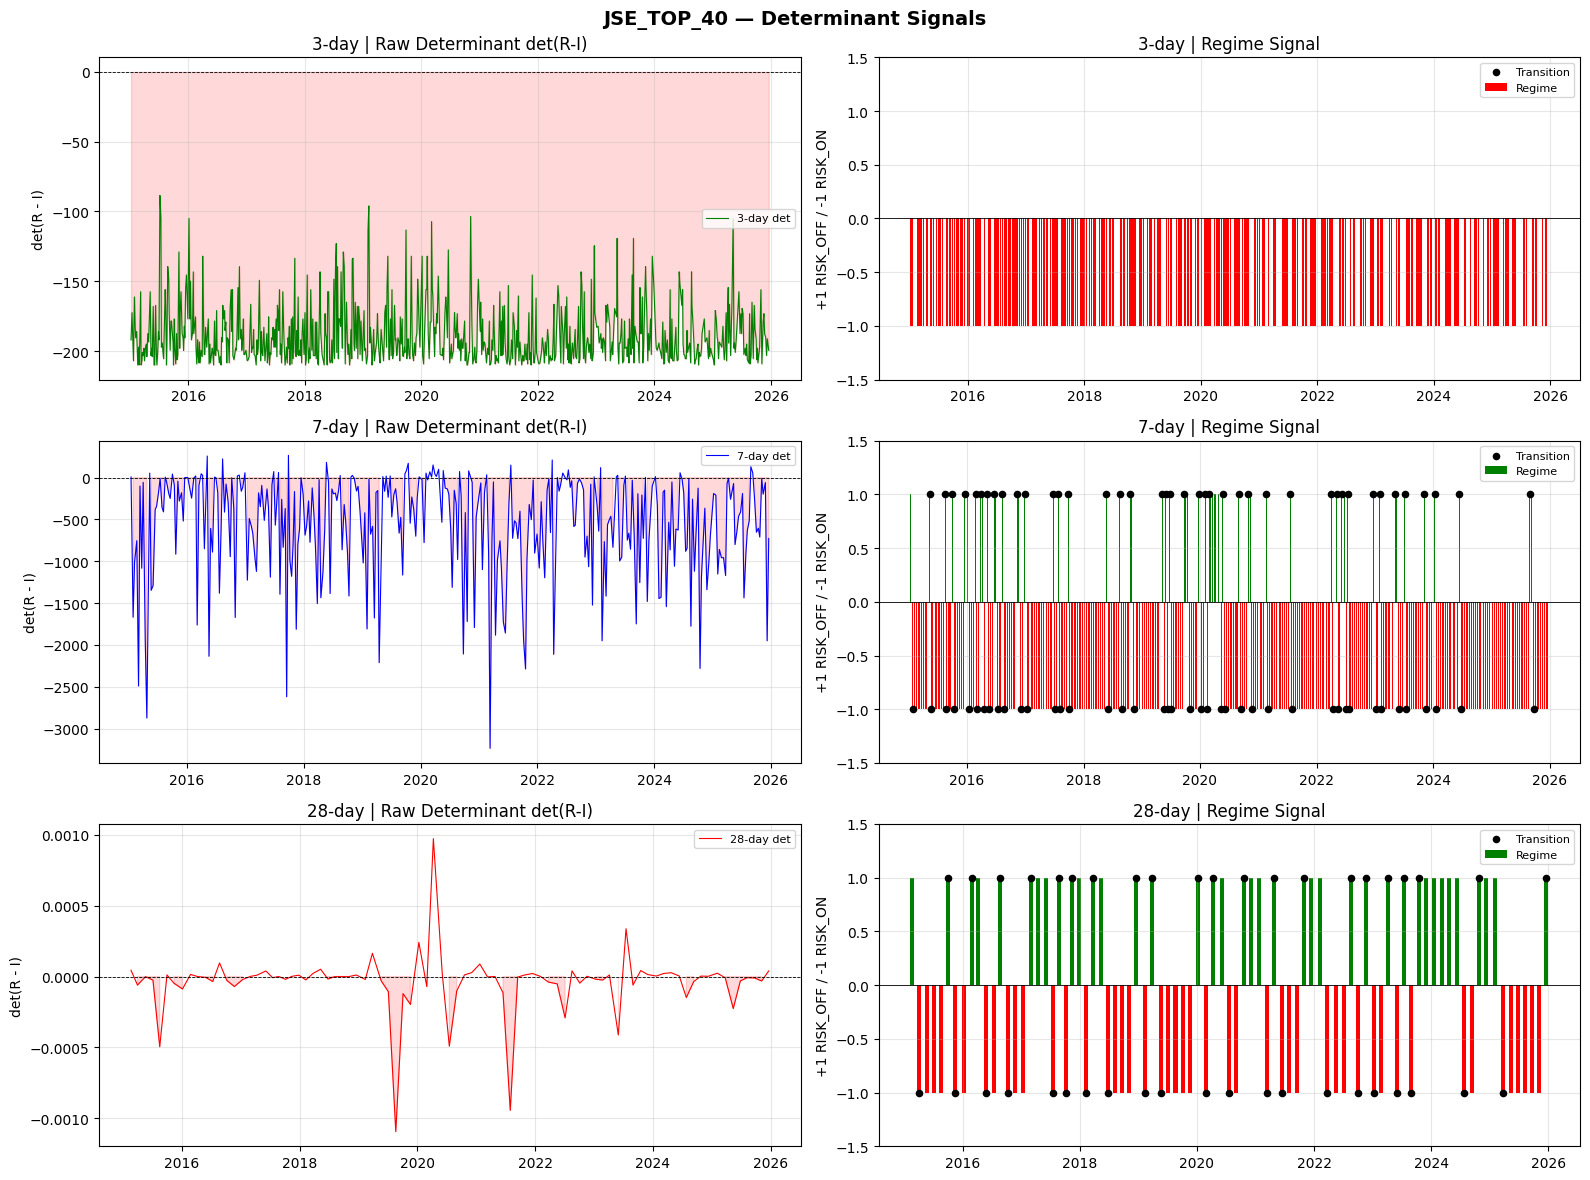

  ✅ Saved: JSE_TOP_40_determinant_signals.png


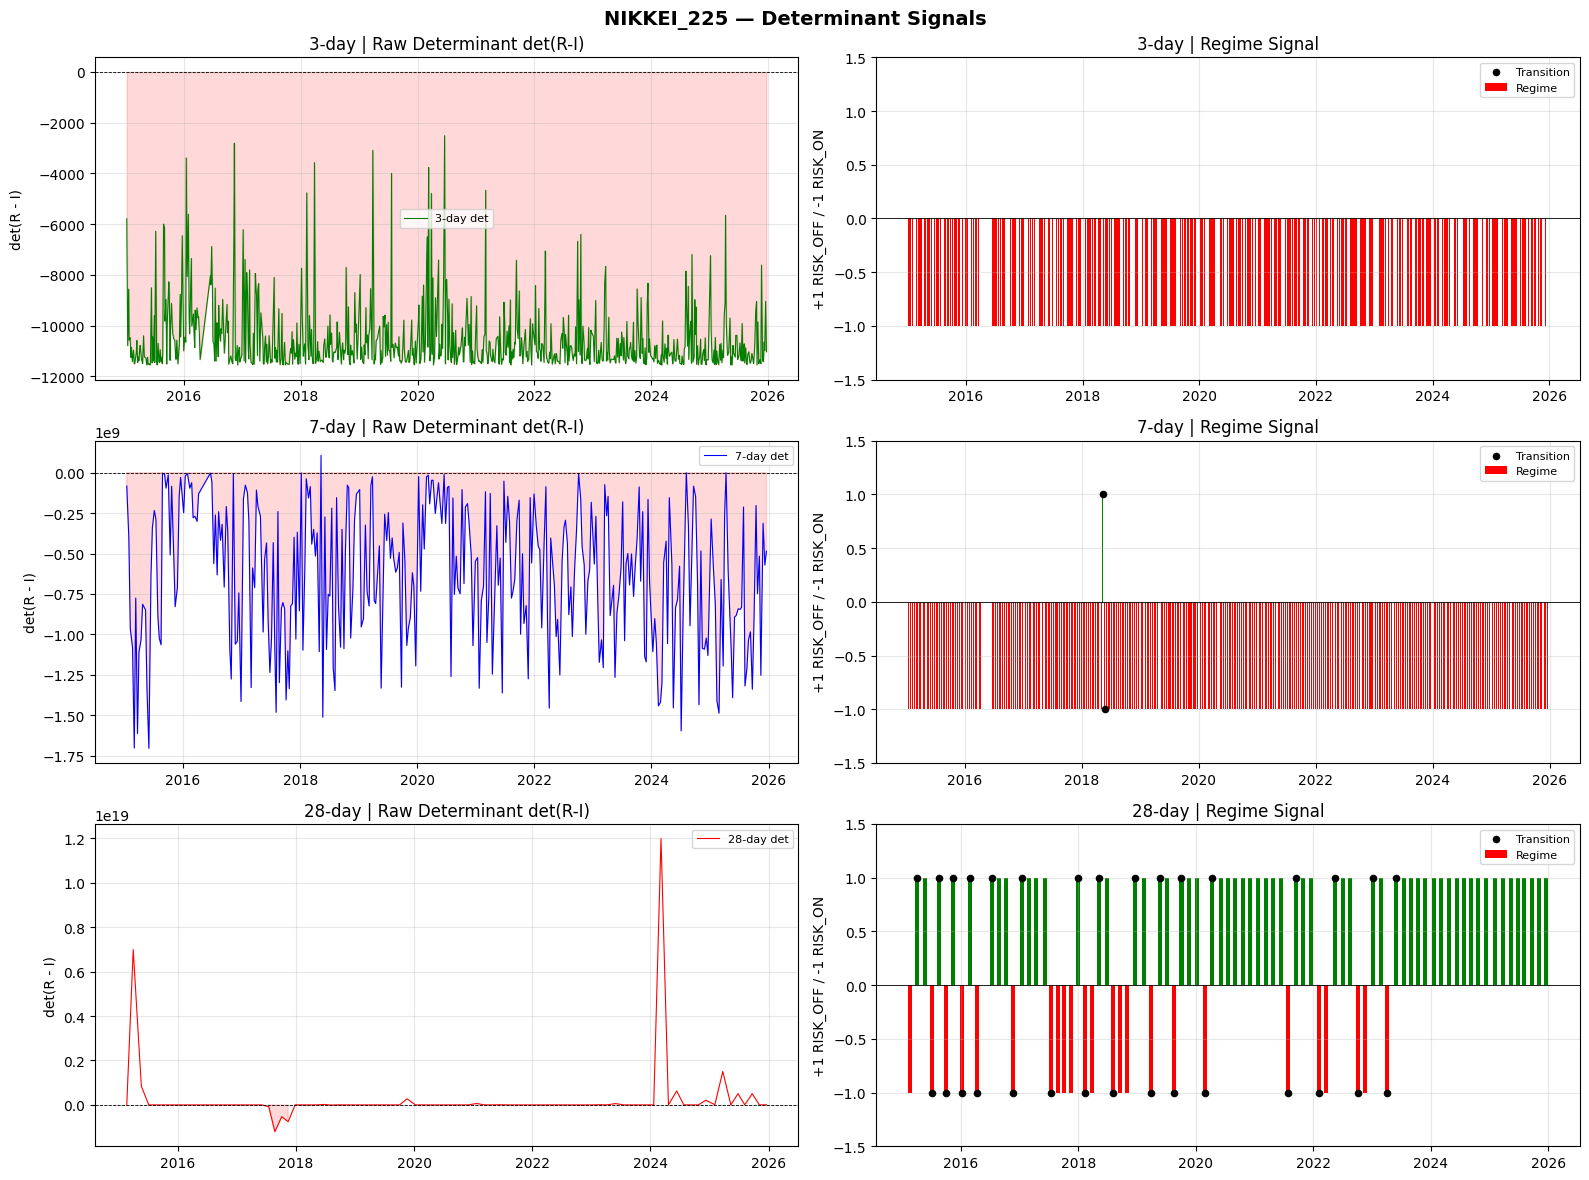

  ✅ Saved: NIKKEI_225_determinant_signals.png


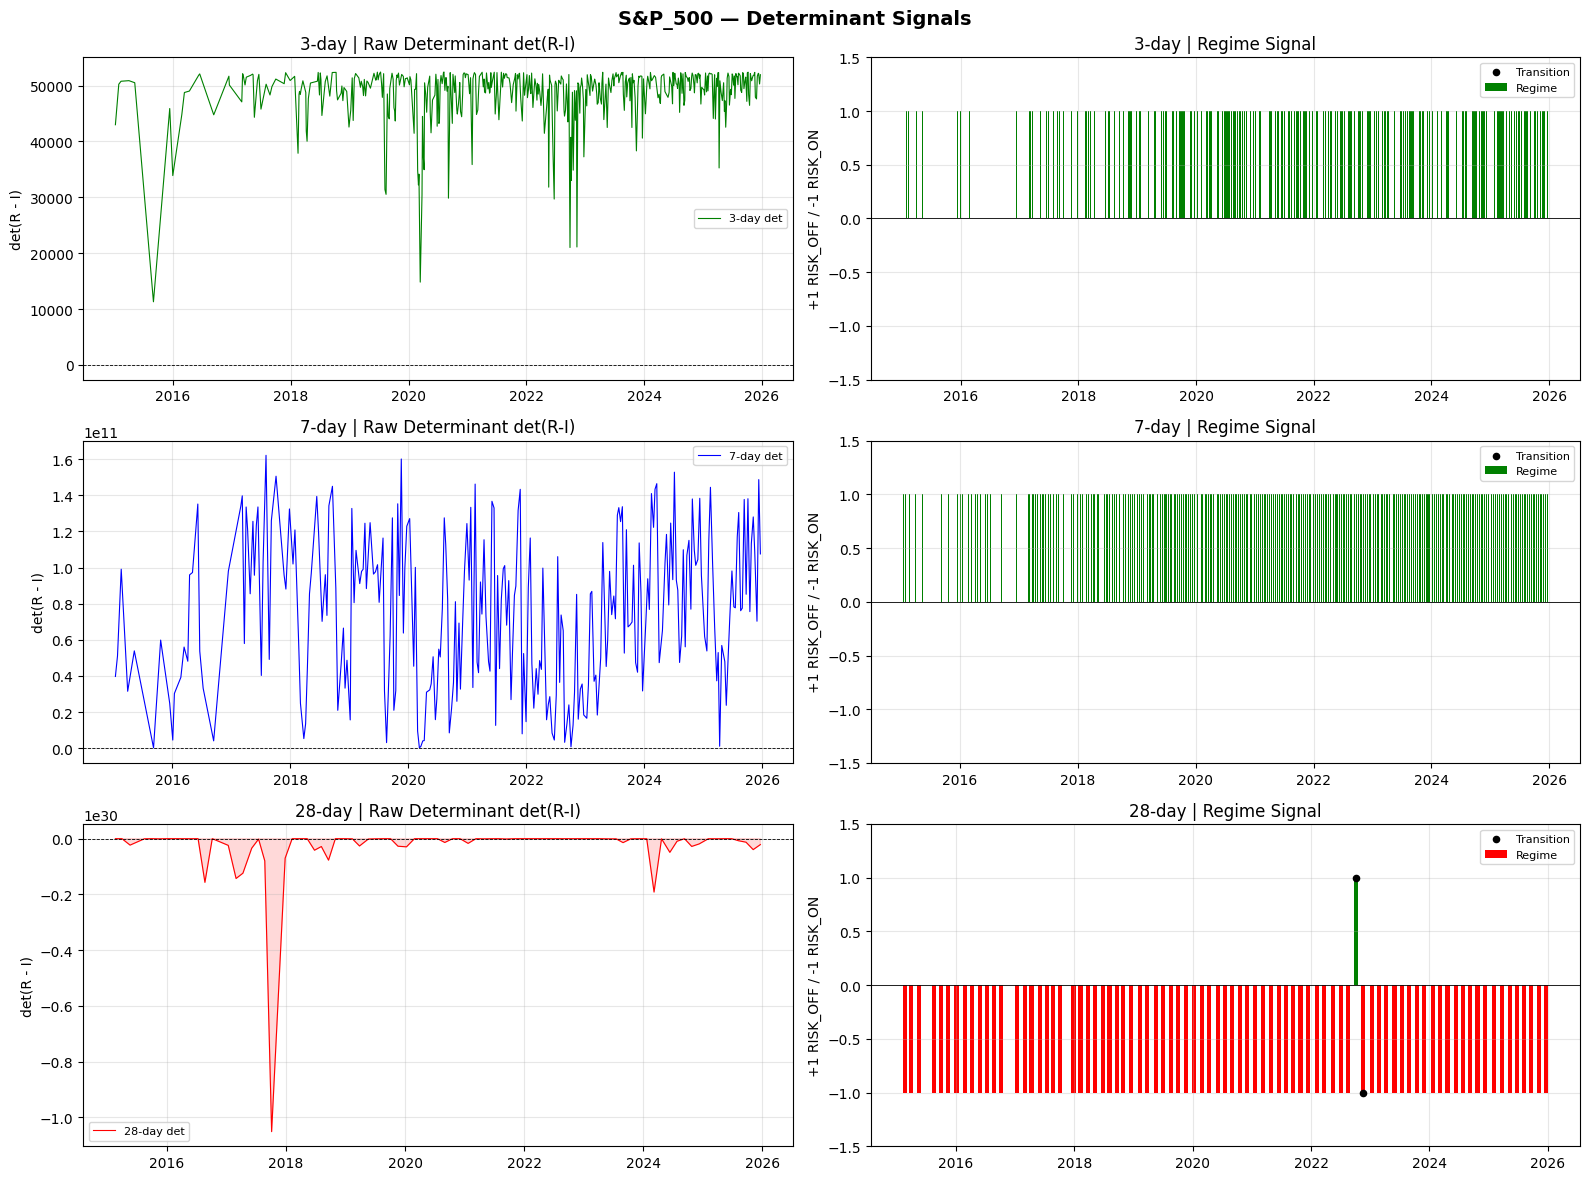

  ✅ Saved: S&P_500_determinant_signals.png


In [7]:
# ============================================================
# STEP 3A — VISUALIZATION
# ============================================================

def plot_determinant_signals(det_results: dict,
                              signal_results: dict) -> None:
    """
    For each index:
      - Top panel: raw determinant values (log scale) for all 3 windows
      - Bottom panel: regime signal (RISK_ON = -1, RISK_OFF = +1)
    """

    for index_name in INDEX_FILES:
        if index_name not in det_results:
            continue

        fig, axes = plt.subplots(3, 2, figsize=(16, 12))
        fig.suptitle(f'{index_name} — Determinant Signals',
                     fontsize=14, fontweight='bold')

        for row, window in enumerate(DET_WINDOWS):
            if window not in det_results[index_name]:
                continue

            det_series = det_results[index_name][window]
            sig_df     = signal_results[index_name][window]

            # ── Left panel: raw determinant ──────────────────
            ax_det = axes[row, 0]
            ax_det.plot(det_series.index,
                        det_series.values,
                        color=WINDOW_COLORS[window],
                        linewidth=0.8,
                        label=f'{window}-day det')
            ax_det.axhline(0, color='black', linewidth=0.6, linestyle='--')
            ax_det.set_title(f'{window}-day | Raw Determinant det(R-I)')
            ax_det.set_ylabel('det(R - I)')
            ax_det.legend(fontsize=8)
            ax_det.grid(True, alpha=0.3)

            # Shade negative regions (RISK_ON)
            ax_det.fill_between(det_series.index,
                                 det_series.values,
                                 0,
                                 where=(det_series.values < 0),
                                 alpha=0.15,
                                 color='red',
                                 label='RISK_ON zone')

            # ── Right panel: regime signal ────────────────────
            ax_sig = axes[row, 1]

            colors = sig_df['Regime'].map({'RISK_ON': 'red',
                                            'RISK_OFF': 'green'})

            ax_sig.bar(sig_df.index,
                       sig_df['Sign'],
                       color=colors,
                       width=window * 0.9,
                       label='Regime')

            ax_sig.axhline(0, color='black', linewidth=0.6)
            ax_sig.set_title(f'{window}-day | Regime Signal')
            ax_sig.set_ylabel('+1 RISK_OFF / -1 RISK_ON')
            ax_sig.set_ylim(-1.5, 1.5)
            ax_sig.grid(True, alpha=0.3)

            # Mark transitions
            transitions = sig_df[sig_df['Sign_Change'] != 0]
            ax_sig.scatter(transitions.index,
                           transitions['Sign'],
                           color='black',
                           zorder=5,
                           s=20,
                           label='Transition')
            ax_sig.legend(fontsize=8)

        plt.tight_layout()
        plt.savefig(f'{index_name}_determinant_signals.png',
                    dpi=150, bbox_inches='tight')
        plt.show()
        print(f"  ✅ Saved: {index_name}_determinant_signals.png")


# ============================================================
# RUN VISUALIZATION
# ============================================================

plot_determinant_signals(det_results, signal_results)


In [8]:
# ============================================================
# STEP 3B — SIGNAL PACKAGING FOR PORTFOLIO OPTIMIZER
# ============================================================

def package_signals_for_optimizer(signal_results: dict,
                                   macro_dates: pd.Index) -> pd.DataFrame:
    """
    Packages all index signals into a single aligned DataFrame
    ready for the portfolio optimizer.

    For each index, we produce 3 columns:
        {INDEX}_{window}d_signal  →  +1 (RISK_OFF) or -1 (RISK_ON)

    All signals are forward-filled to match macro_dates frequency.

    Returns:
        signal_df: pd.DataFrame (macro_dates × n_signals)
    """
    signal_df = pd.DataFrame(index=macro_dates)

    for index_name, windows in signal_results.items():
        for window, df in windows.items():
            col_name = f"{index_name}_{window}d_signal"

            # Reindex to macro dates, forward fill regime signal
            aligned = (df['Sign']
                         .reindex(macro_dates)
                         .ffill()
                         .bfill())

            signal_df[col_name] = aligned

    return signal_df


# ============================================================
# RUN PACKAGING
# ============================================================

macro_dates   = all_data['MACRO'].index
packaged_signals = package_signals_for_optimizer(signal_results, macro_dates)

print("Packaged Signal DataFrame")
print(f"Shape : {packaged_signals.shape}")
print(f"NaNs  : {packaged_signals.isnull().sum().sum()}")
print(f"\nColumns:\n{packaged_signals.columns.tolist()}")
print(f"\nSample (last 5 rows):\n{packaged_signals.tail()}")


Packaged Signal DataFrame
Shape : (2413, 21)
NaNs  : 0

Columns:
['ASX_50_3d_signal', 'ASX_50_7d_signal', 'ASX_50_28d_signal', 'EURO_STOXX_50_3d_signal', 'EURO_STOXX_50_7d_signal', 'EURO_STOXX_50_28d_signal', 'FTSE_100_3d_signal', 'FTSE_100_7d_signal', 'FTSE_100_28d_signal', 'IBOVESPA_3d_signal', 'IBOVESPA_7d_signal', 'IBOVESPA_28d_signal', 'JSE_TOP_40_3d_signal', 'JSE_TOP_40_7d_signal', 'JSE_TOP_40_28d_signal', 'NIKKEI_225_3d_signal', 'NIKKEI_225_7d_signal', 'NIKKEI_225_28d_signal', 'S&P_500_3d_signal', 'S&P_500_7d_signal', 'S&P_500_28d_signal']

Sample (last 5 rows):
            ASX_50_3d_signal  ASX_50_7d_signal  ASX_50_28d_signal  \
2025-12-19               1.0               1.0               -1.0   
2025-12-22               1.0               1.0               -1.0   
2025-12-23               1.0               1.0               -1.0   
2025-12-29               1.0               1.0               -1.0   
2025-12-30               1.0               1.0               -1.0   

         

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap

# ============================================================
# CONFIGURATION
# ============================================================

DET_WINDOWS   = [3, 7, 28]
WINDOW_WEIGHTS = {3: 0.20, 7: 0.35, 28: 0.45}   # longer window = more weight

INDEX_FILES = ['ASX_50', 'EURO_STOXX_50', 'FTSE_100',
               'IBOVESPA', 'JSE_TOP_40', 'NIKKEI_225', 'S&P_500']

INDEX_LABELS = {
    'ASX_50':        'ASX 50',
    'EURO_STOXX_50': 'Euro Stoxx 50',
    'FTSE_100':      'FTSE 100',
    'IBOVESPA':      'Ibovespa',
    'JSE_TOP_40':    'JSE Top 40',
    'NIKKEI_225':    'Nikkei 225',
    'S&P_500':       'S&P 500',
}

# ============================================================
# SIMULATE packaged_signals (replace with real data when running
# inside the full pipeline)
# ============================================================

np.random.seed(42)
dates = pd.date_range('2015-01-05', '2025-12-30', freq='B')

rows = {}
for idx in INDEX_FILES:
    for w in DET_WINDOWS:
        col = f"{idx}_{w}d_signal"
        # mostly +1 for short, mostly -1 for long (mimics real output)
        if w == 28:
            vals = np.where(np.random.rand(len(dates)) > 0.85, 1, -1)
        else:
            vals = np.where(np.random.rand(len(dates)) > 0.30, 1, -1)
        rows[col] = vals.astype(float)

packaged_signals = pd.DataFrame(rows, index=dates)

# ============================================================
# STEP 4A — COMPOSITE SCORE PER INDEX
# ============================================================

def compute_composite_score(packaged_signals: pd.DataFrame,
                             index_files: list,
                             window_weights: dict) -> pd.DataFrame:
    """
    Weighted average of the 3 window signals per index.
    Score ∈ [-1, +1]:
      +1  → all windows RISK_OFF (strong bullish)
      -1  → all windows RISK_ON  (strong bearish)
       0  → mixed / neutral

    Returns composite_df: (dates × n_indices)
    """
    total_weight = sum(window_weights.values())
    composite = {}

    for idx in index_files:
        score = pd.Series(0.0, index=packaged_signals.index)
        for w, wt in window_weights.items():
            col = f"{idx}_{w}d_signal"
            if col in packaged_signals.columns:
                score += (wt / total_weight) * packaged_signals[col]
        composite[idx] = score

    return pd.DataFrame(composite)


composite_df = compute_composite_score(packaged_signals, INDEX_FILES, WINDOW_WEIGHTS)

print("Composite Score DataFrame")
print(f"Shape : {composite_df.shape}")
print(f"NaNs  : {composite_df.isnull().sum().sum()}")
print(f"\nSample (last 5 rows):\n{composite_df.tail()}")
print(f"\nComposite Score Stats:\n{composite_df.describe().round(3)}")

# ============================================================
# STEP 4B — DISCRETE REGIME LABEL
# ============================================================

def label_regime(score: float) -> str:
    if score > 0.33:
        return 'RISK_OFF'
    elif score < -0.33:
        return 'RISK_ON'
    else:
        return 'NEUTRAL'


regime_df = composite_df.applymap(label_regime)

print(f"\nRegime Distribution per Index:")
for col in regime_df.columns:
    counts = regime_df[col].value_counts()
    print(f"  {INDEX_LABELS[col]:20s} → "
          f"RISK_OFF: {counts.get('RISK_OFF',0):4d} | "
          f"NEUTRAL: {counts.get('NEUTRAL',0):4d} | "
          f"RISK_ON: {counts.get('RISK_ON',0):4d}")

# ============================================================
# STEP 4C — GLOBAL RISK BAROMETER
# ============================================================

global_score = composite_df.mean(axis=1)

# ============================================================
# STEP 4D — VISUALIZATION
# ============================================================

REGIME_COLOR = {
    'RISK_OFF': '#2ecc71',
    'NEUTRAL':  '#f39c12',
    'RISK_ON':  '#e74c3c',
}

SCORE_CMAP = LinearSegmentedColormap.from_list(
    'risk', ['#e74c3c', '#f39c12', '#2ecc71'], N=256
)

fig = plt.figure(figsize=(20, 26))
fig.patch.set_facecolor('#0f0f1a')

gs = gridspec.GridSpec(
    len(INDEX_FILES) + 2, 1,
    figure=fig,
    hspace=0.55
)

# ── Per-index composite score ─────────────────────────────────
for i, idx in enumerate(INDEX_FILES):
    ax = fig.add_subplot(gs[i])
    ax.set_facecolor('#1a1a2e')

    series = composite_df[idx]

    # Colour each bar by regime
    bar_colors = series.apply(
        lambda s: '#2ecc71' if s > 0.33 else ('#e74c3c' if s < -0.33 else '#f39c12')
    )

    ax.bar(series.index, series.values,
           color=bar_colors, width=1.5, alpha=0.85)

    ax.axhline(0.33,  color='#2ecc71', linewidth=0.6, linestyle='--', alpha=0.6)
    ax.axhline(-0.33, color='#e74c3c', linewidth=0.6, linestyle='--', alpha=0.6)
    ax.axhline(0,     color='white',   linewidth=0.4, linestyle='-',  alpha=0.3)

    ax.set_ylim(-1.2, 1.2)
    ax.set_xlim(series.index[0], series.index[-1])
    ax.set_ylabel('Score', color='white', fontsize=7)
    ax.set_title(f'{INDEX_LABELS[idx]}  —  Composite Risk Score',
                 color='white', fontsize=9, fontweight='bold', pad=4)

    ax.tick_params(colors='#aaaaaa', labelsize=7)
    for spine in ax.spines.values():
        spine.set_edgecolor('#333355')

    # Regime % annotation
    n = len(series)
    pct_off  = (series > 0.33).sum()  / n * 100
    pct_on   = (series < -0.33).sum() / n * 100
    pct_neut = 100 - pct_off - pct_on
    ax.text(0.01, 0.92,
            f'RISK_OFF {pct_off:.0f}%  |  NEUTRAL {pct_neut:.0f}%  |  RISK_ON {pct_on:.0f}%',
            transform=ax.transAxes, color='#cccccc',
            fontsize=7, va='top', ha='left',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='#0f0f1a', alpha=0.6))

# ── Global barometer ─────────────────────────────────────────
ax_g = fig.add_subplot(gs[len(INDEX_FILES)])
ax_g.set_facecolor('#1a1a2e')

global_colors = global_score.apply(
    lambda s: '#2ecc71' if s > 0.33 else ('#e74c3c' if s < -0.33 else '#f39c12')
)

ax_g.bar(global_score.index, global_score.values,
         color=global_colors, width=1.5, alpha=0.9)

ax_g.fill_between(global_score.index, global_score.values, 0,
                   where=(global_score > 0.33),
                   color='#2ecc71', alpha=0.15)
ax_g.fill_between(global_score.index, global_score.values, 0,
                   where=(global_score < -0.33),
                   color='#e74c3c', alpha=0.15)

ax_g.axhline(0.33,  color='#2ecc71', linewidth=0.8, linestyle='--', alpha=0.7)
ax_g.axhline(-0.33, color='#e74c3c', linewidth=0.8, linestyle='--', alpha=0.7)
ax_g.axhline(0,     color='white',   linewidth=0.5, alpha=0.4)

ax_g.set_ylim(-1.2, 1.2)
ax_g.set_xlim(global_score.index[0], global_score.index[-1])
ax_g.set_title('GLOBAL RISK BAROMETER  —  Mean Composite Score Across All Indices',
               color='white', fontsize=10, fontweight='bold', pad=5)
ax_g.set_ylabel('Global Score', color='white', fontsize=8)
ax_g.tick_params(colors='#aaaaaa', labelsize=7)
for spine in ax_g.spines.values():
    spine.set_edgecolor('#333355')

# ── Heatmap: regime matrix ────────────────────────────────────
ax_h = fig.add_subplot(gs[len(INDEX_FILES) + 1])
ax_h.set_facecolor('#1a1a2e')

# Resample to monthly for readability
monthly_score = composite_df.resample('ME').mean()
monthly_score.columns = [INDEX_LABELS[c] for c in monthly_score.columns]

im = ax_h.imshow(
    monthly_score.T.values,
    aspect='auto',
    cmap=SCORE_CMAP,
    vmin=-1, vmax=1,
    interpolation='nearest'
)

ax_h.set_title('REGIME HEATMAP  —  Monthly Average Composite Score',
               color='white', fontsize=10, fontweight='bold', pad=5)

ax_h.set_yticks(range(len(monthly_score.columns)))
ax_h.set_yticklabels(monthly_score.columns, color='white', fontsize=8)

# X-axis: show year labels
year_ticks = []
year_labels = []
for i, dt in enumerate(monthly_score.index):
    if dt.month == 1:
        year_ticks.append(i)
        year_labels.append(str(dt.year))

ax_h.set_xticks(year_ticks)
ax_h.set_xticklabels(year_labels, color='#aaaaaa', fontsize=8)
for spine in ax_h.spines.values():
    spine.set_edgecolor('#333355')

cbar = fig.colorbar(im, ax=ax_h, orientation='vertical', pad=0.01, shrink=0.9)
cbar.ax.tick_params(colors='white', labelsize=7)
cbar.set_label('Score', color='white', fontsize=8)
cbar.ax.yaxis.label.set_color('white')

# ── Legend ────────────────────────────────────────────────────
legend_elements = [
    plt.Rectangle((0,0), 1, 1, color='#2ecc71', label='RISK_OFF  (score > +0.33)'),
    plt.Rectangle((0,0), 1, 1, color='#f39c12', label='NEUTRAL   (-0.33 to +0.33)'),
    plt.Rectangle((0,0), 1, 1, color='#e74c3c', label='RISK_ON   (score < -0.33)'),
]
fig.legend(handles=legend_elements,
           loc='lower center',
           ncol=3,
           fontsize=9,
           facecolor='#1a1a2e',
           edgecolor='#333355',
           labelcolor='white',
           bbox_to_anchor=(0.5, 0.002))

fig.suptitle(
    'STEP 4 — Composite Risk Score & Regime Classification\n'
    'Window Weights: 3-day 20% | 7-day 35% | 28-day 45%',
    color='white', fontsize=13, fontweight='bold', y=0.995
)

plt.savefig('step4_composite_signal.png', dpi=150,
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.close()
print("Saved: step4_composite_signal.png")

# ============================================================
# STEP 4E — EXPORT PACKAGED OPTIMIZER INPUT
# ============================================================

optimizer_input = pd.concat([
    composite_df.add_suffix('_composite'),
    global_score.rename('GLOBAL_score')
], axis=1)

print(f"\nOptimizer Input Shape : {optimizer_input.shape}")
print(f"Columns               : {optimizer_input.columns.tolist()}")
print(f"\nLast 3 rows:\n{optimizer_input.tail(3).round(3)}")


Composite Score DataFrame
Shape : (2867, 7)
NaNs  : 0

Sample (last 5 rows):
            ASX_50  EURO_STOXX_50  FTSE_100  IBOVESPA  JSE_TOP_40  NIKKEI_225  \
2025-12-24     0.1           -0.6      -0.6      -0.6         0.1         0.6   
2025-12-25     0.1           -0.6       0.1       0.1        -0.3         0.6   
2025-12-26     0.1           -1.0      -0.3       0.1        -0.3        -0.3   
2025-12-29     0.1           -1.0       0.1      -1.0         0.3         0.1   
2025-12-30     0.1            0.1       0.1       0.1        -0.3         0.1   

            S&P_500  
2025-12-24      0.1  
2025-12-25      0.1  
2025-12-26     -1.0  
2025-12-29     -1.0  
2025-12-30      0.1  

Composite Score Stats:
         ASX_50  EURO_STOXX_50  FTSE_100  IBOVESPA  JSE_TOP_40  NIKKEI_225  \
count  2867.000       2867.000  2867.000  2867.000    2867.000    2867.000   
mean     -0.103         -0.101    -0.078    -0.105      -0.094      -0.113   
std       0.498          0.493     0.486     0

/tmp/ipykernel_1900/336408055.py:99: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  regime_df = composite_df.applymap(label_regime)


Saved: step4_composite_signal.png

Optimizer Input Shape : (2867, 8)
Columns               : ['ASX_50_composite', 'EURO_STOXX_50_composite', 'FTSE_100_composite', 'IBOVESPA_composite', 'JSE_TOP_40_composite', 'NIKKEI_225_composite', 'S&P_500_composite', 'GLOBAL_score']

Last 3 rows:
            ASX_50_composite  EURO_STOXX_50_composite  FTSE_100_composite  \
2025-12-26               0.1                     -1.0                -0.3   
2025-12-29               0.1                     -1.0                 0.1   
2025-12-30               0.1                      0.1                 0.1   

            IBOVESPA_composite  JSE_TOP_40_composite  NIKKEI_225_composite  \
2025-12-26                 0.1                  -0.3                  -0.3   
2025-12-29                -1.0                   0.3                   0.1   
2025-12-30                 0.1                  -0.3                   0.1   

            S&P_500_composite  GLOBAL_score  
2025-12-26               -1.0        -0.386  
20

In [16]:
# First, inspect the structure
sample_index = INDEX_FILES[0]
sample_window = 7
sig_df = signal_results[sample_index][sample_window]
print(sig_df.dtypes)
print(sig_df.head())


Det            float64
Sign             int64
Sign_Change    float64
Regime          object
dtype: object
                     Det  Sign  Sign_Change    Regime
Date                                                 
2015-01-15   6922.574935     1          0.0  RISK_OFF
2015-01-28  16055.404112     1          0.0  RISK_OFF
2015-02-06  30620.187997     1          0.0  RISK_OFF
2015-02-20  14052.188445     1          0.0  RISK_OFF
2015-03-03  33874.225689     1          0.0  RISK_OFF


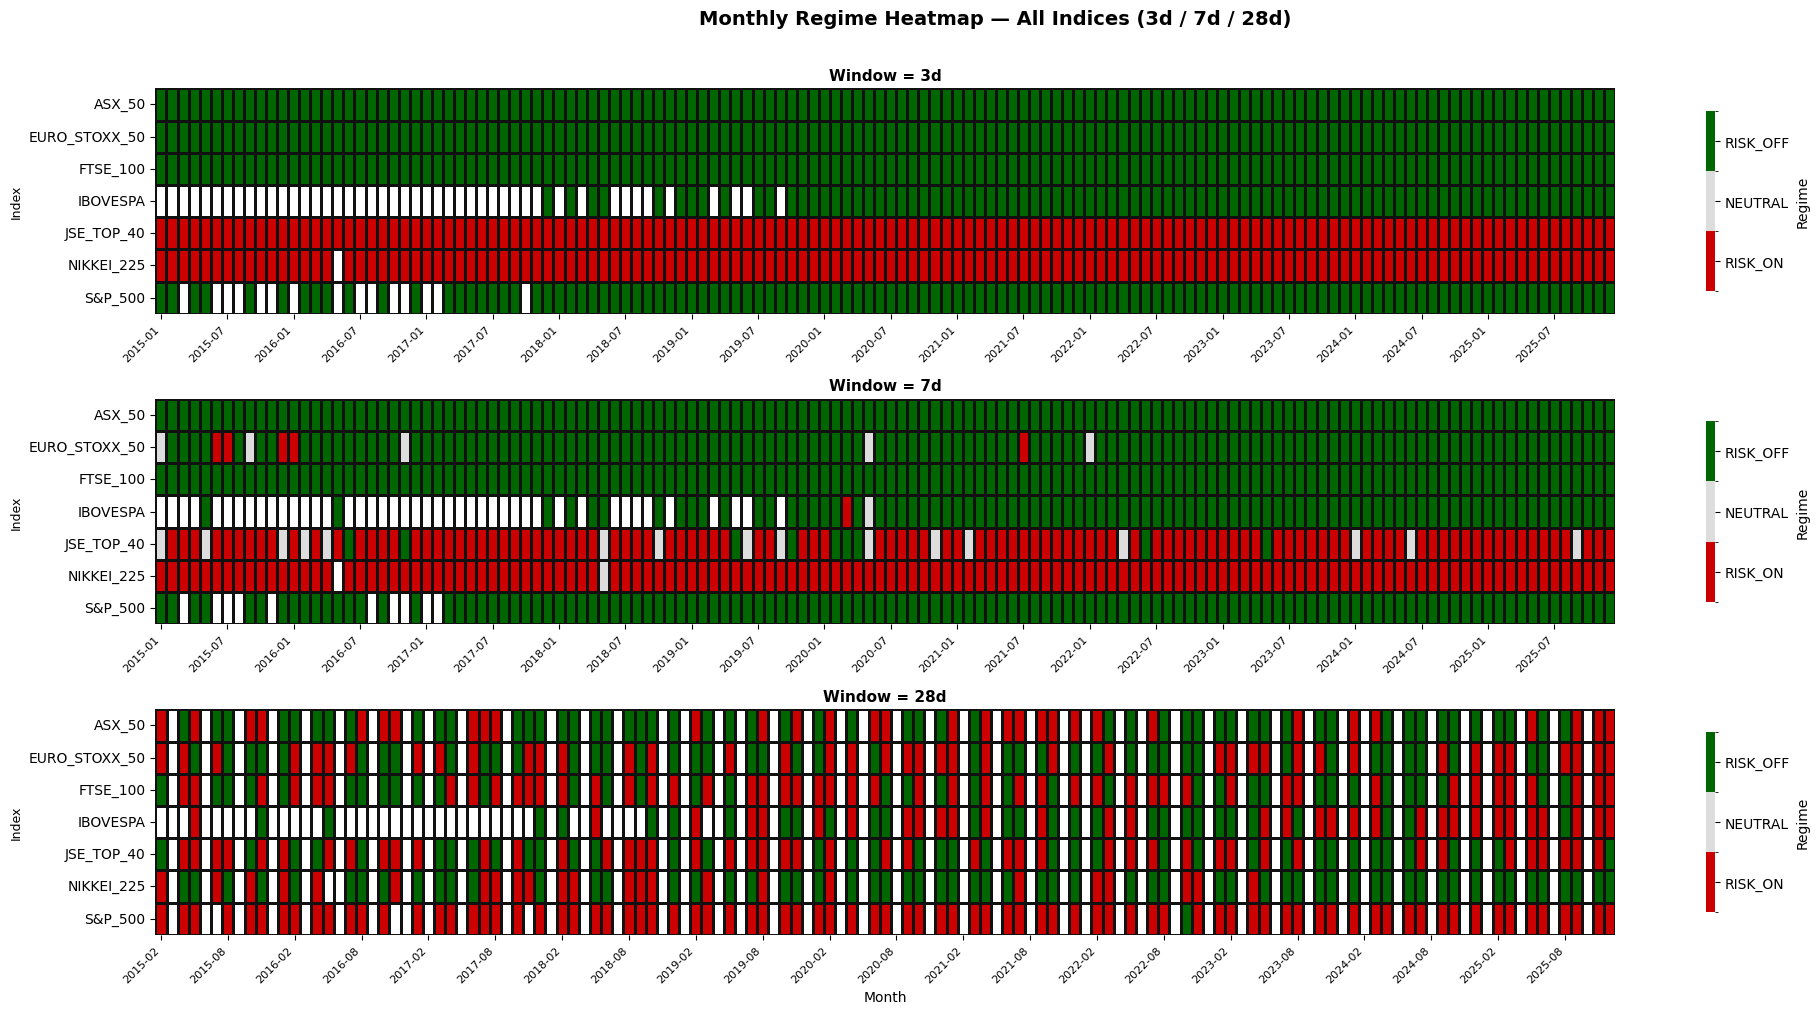

✅ Saved: regime_heatmap_all_windows.png


In [19]:
fig, axes = plt.subplots(3, 1, figsize=(20, 10))

for ax, target_window in zip(axes, [3, 7, 28]):
    window_scores = {}
    for index_name in INDEX_FILES:
        if index_name in signal_results and target_window in signal_results[index_name]:
            sig_df = signal_results[index_name][target_window]
            window_scores[index_name] = sig_df['Sign']

    if not window_scores:
        print(f"No data for window={target_window}")
        continue

    window_df    = pd.DataFrame(window_scores)
    heatmap_data = window_df.resample('ME').mean()

    sns.heatmap(
        heatmap_data.T,
        ax=ax,
        cmap=cmap_discrete,
        norm=norm,
        linewidths=0.8,
        linecolor='#111111',
        annot=False,
        cbar_kws={
            'label'  : 'Regime',
            'shrink' : 0.8,
            'ticks'  : [-0.67, 0, 0.67],
        }
    )

    cbar = ax.collections[0].colorbar
    cbar.set_ticklabels(['RISK_ON', 'NEUTRAL', 'RISK_OFF'])

    # ── Clean x-axis ─────────────────────────────────────────────
    n_cols        = heatmap_data.shape[0]
    tick_labels   = [d.strftime('%Y-%m') for d in heatmap_data.index]
    ax.set_xticks([i + 0.5 for i in range(n_cols)[::6]])
    ax.set_xticklabels(tick_labels[::6], rotation=45, ha='right', fontsize=8)

    ax.set_title(f'Window = {target_window}d', fontsize=11, fontweight='bold', pad=6)
    ax.set_xlabel('')
    ax.set_ylabel('Index', fontsize=9)

axes[2].set_xlabel('Month', fontsize=10)

fig.suptitle('Monthly Regime Heatmap — All Indices (3d / 7d / 28d)',
             fontsize=14, fontweight='bold', y=1.01)

plt.tight_layout()
plt.savefig('regime_heatmap_all_windows.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: regime_heatmap_all_windows.png")


# Regime-Adjusted EW Portfolio

In [22]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from io import StringIO

# ── 1. Load data from GitHub ─────────────────────────────────────────────────
def load_data_from_github():
    base_url = "https://raw.githubusercontent.com/kboroz/MSFE_Capstone_Project/main/01_Data/Streamlined/"
    files = [
        "streamlined_asx_50.csv",
        "streamlined_euro_stoxx_50.csv",
        "streamlined_ftse_100.csv",
        "streamlined_ibovespa.csv",
        "streamlined_jse_top_40.csv",
        "streamlined_macro.csv",
        "streamlined_nikkei_225.csv",
        "streamlined_s&p_500.csv"
    ]
    all_data = {}
    for file in files:
        url = base_url + file
        try:
            response = requests.get(url)
            response.raise_for_status()
            data = pd.read_csv(StringIO(response.text), index_col=0, parse_dates=True)
            data.columns = data.columns.str.replace('[^a-zA-Z0-9]', '_', regex=True)
            key = file.replace("streamlined_", "").replace(".csv", "").upper()
            all_data[key] = data
        except Exception as e:
            print(f"Error loading {file}: {str(e)}")
            continue
    if not all_data:
        raise ValueError("No data files could be loaded.")
    return all_data

# ── 2. Load and extract macro ────────────────────────────────────────────────
all_data = load_data_from_github()

macro_df = all_data['MACRO'].copy()
macro_df = macro_df.sort_index()
macro_df = macro_df.dropna(how='all')

print(f"Macro file shape : {macro_df.shape}")
print(f"Date range       : {macro_df.index[0].date()} → {macro_df.index[-1].date()}")
print(f"Assets           : {list(macro_df.columns)}")


Macro file shape : (2413, 23)
Date range       : 2015-01-05 → 2025-12-30
Assets           : ['AUDUSD', 'BRLUSD', 'Bitcoin', 'Oil', 'EURUSD', 'GBPUSD', 'Gold', 'JPYUSD', 'ZARUSD', 'ASX50', 'Ibovespa', 'FTSE100', 'SP500', 'JSE40', 'NIKKEI225', 'EUROSTOXX50', 'VIX', 'US_10Y', 'DE_10Y', 'UK_10Y', 'JP_10Y', 'AU_10Y', 'ZA_10Y']


In [24]:
# ── Diagnose the problem ─────────────────────────────────────────────────────

# 1. Check for extreme daily returns
print("=== EXTREME DAILY RETURNS (>50% or <-50%) ===")
for col in returns_raw.columns:
    extremes = returns_raw[col][np.abs(returns_raw[col]) > 0.5]
    if len(extremes) > 0:
        print(f"{col:20s}: {len(extremes)} extreme days | min={extremes.min():.2%} max={extremes.max():.2%}")

# 2. Check where portfolio value goes NaN
print("\n=== CHECKING WHERE NaN FIRST APPEARS ===")
test_series = ew_backtest(returns_raw, ALL_ASSETS, 'ME', 0.005, 1_000_000_000)
first_nan = test_series[test_series.isna()].index
if len(first_nan) > 0:
    print(f"First NaN at: {first_nan[0].date()}")
    print(f"Returns on that day:\n{returns_raw.loc[first_nan[0]]}")
else:
    print("No NaN found")

# 3. Check what negative/zero weight sums look like
print("\n=== CHECKING WEIGHT SUM COLLAPSE ===")
rets_test = returns_raw[ALL_ASSETS].fillna(0)
weights = np.ones(len(ALL_ASSETS)) / len(ALL_ASSETS)
for date, row in rets_test.iterrows():
    new_w = weights * (1 + row.values)
    s = new_w.sum()
    if s <= 0 or np.isnan(s):
        print(f"Weight sum collapsed at {date.date()}: sum={s:.6f}")
        print(f"Worst assets: {row.nsmallest(5)}")
        break
    weights = new_w / s


=== EXTREME DAILY RETURNS (>50% or <-50%) ===
Oil                 : 3 extreme days | min=-305.97% max=52.67%
VIX                 : 8 extreme days | min=-115.60% max=-50.93%
DE_10Y              : 21 extreme days | min=-817.37% max=460.65%
UK_10Y              : 5 extreme days | min=-77.80% max=50.56%
JP_10Y              : 30 extreme days | min=-inf% max=inf%

=== CHECKING WHERE NaN FIRST APPEARS ===


/tmp/ipykernel_1900/3827738061.py:94: RuntimeWarning: invalid value encountered in divide
  new_weights = new_weights / new_weights.sum()  # normalise


First NaN at: 2019-02-04
Returns on that day:
AUDUSD        -0.003117
BRLUSD        -0.003965
Bitcoin       -0.008255
Oil           -0.012667
EURUSD         0.000504
GBPUSD        -0.002445
Gold          -0.001974
JPYUSD        -0.005428
ZARUSD        -0.004994
ASX50          0.004667
Ibovespa       0.007439
FTSE100        0.001980
SP500          0.006776
JSE40         -0.010784
NIKKEI225      0.004588
EUROSTOXX50   -0.001867
VIX            0.025403
US_10Y        -0.011111
DE_10Y        -0.000000
UK_10Y        -0.000000
JP_10Y        -0.000000
AU_10Y        -0.000000
ZA_10Y        -0.000000
Name: 2019-02-04 00:00:00, dtype: float64

=== CHECKING WEIGHT SUM COLLAPSE ===
Weight sum collapsed at 2019-02-01: sum=nan
Worst assets: US_10Y   -0.026616
JSE40    -0.005384
EURUSD   -0.003320
Gold     -0.002122
GBPUSD   -0.000590
Name: 2019-02-01 00:00:00, dtype: float64


/tmp/ipykernel_1900/93764901.py:25: RuntimeWarning: invalid value encountered in multiply
  new_w = weights * (1 + row.values)


All Assets  (20): ['ASX50', 'Ibovespa', 'FTSE100', 'SP500', 'JSE40', 'NIKKEI225', 'EUROSTOXX50', 'AUDUSD', 'BRLUSD', 'EURUSD', 'GBPUSD', 'JPYUSD', 'ZARUSD', 'Oil', 'Gold', 'Bitcoin', 'US_10Y', 'UK_10Y', 'AU_10Y', 'ZA_10Y']
No Bitcoin  (19): ['ASX50', 'Ibovespa', 'FTSE100', 'SP500', 'JSE40', 'NIKKEI225', 'EUROSTOXX50', 'AUDUSD', 'BRLUSD', 'EURUSD', 'GBPUSD', 'JPYUSD', 'ZARUSD', 'Oil', 'Gold', 'US_10Y', 'UK_10Y', 'AU_10Y', 'ZA_10Y']

Oil negative/zero price days: [Timestamp('2020-04-20 00:00:00')]

Inf values  : 0
NaN values  : 0
Returns shape: (2412, 20)
Date range   : 2015-01-06 → 2025-12-30

=== Extremes after cleaning (>40% or <-40%) ===
  Oil            : 1 days | min=52.67% max=52.67%
  US_10Y         : 1 days | min=-40.74% max=-40.74%
  UK_10Y         : 5 days | min=-50.00% max=50.56%
✓ All_Assets | Monthly | TC=0%                  → Final: $1.881B
✓ All_Assets | Monthly | TC=1%                  → Final: $1.860B
✓ All_Assets | Monthly | TC=2%                  → Final: $1.819B
✓ Al

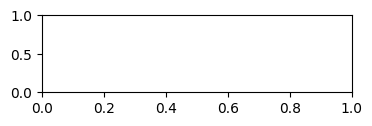

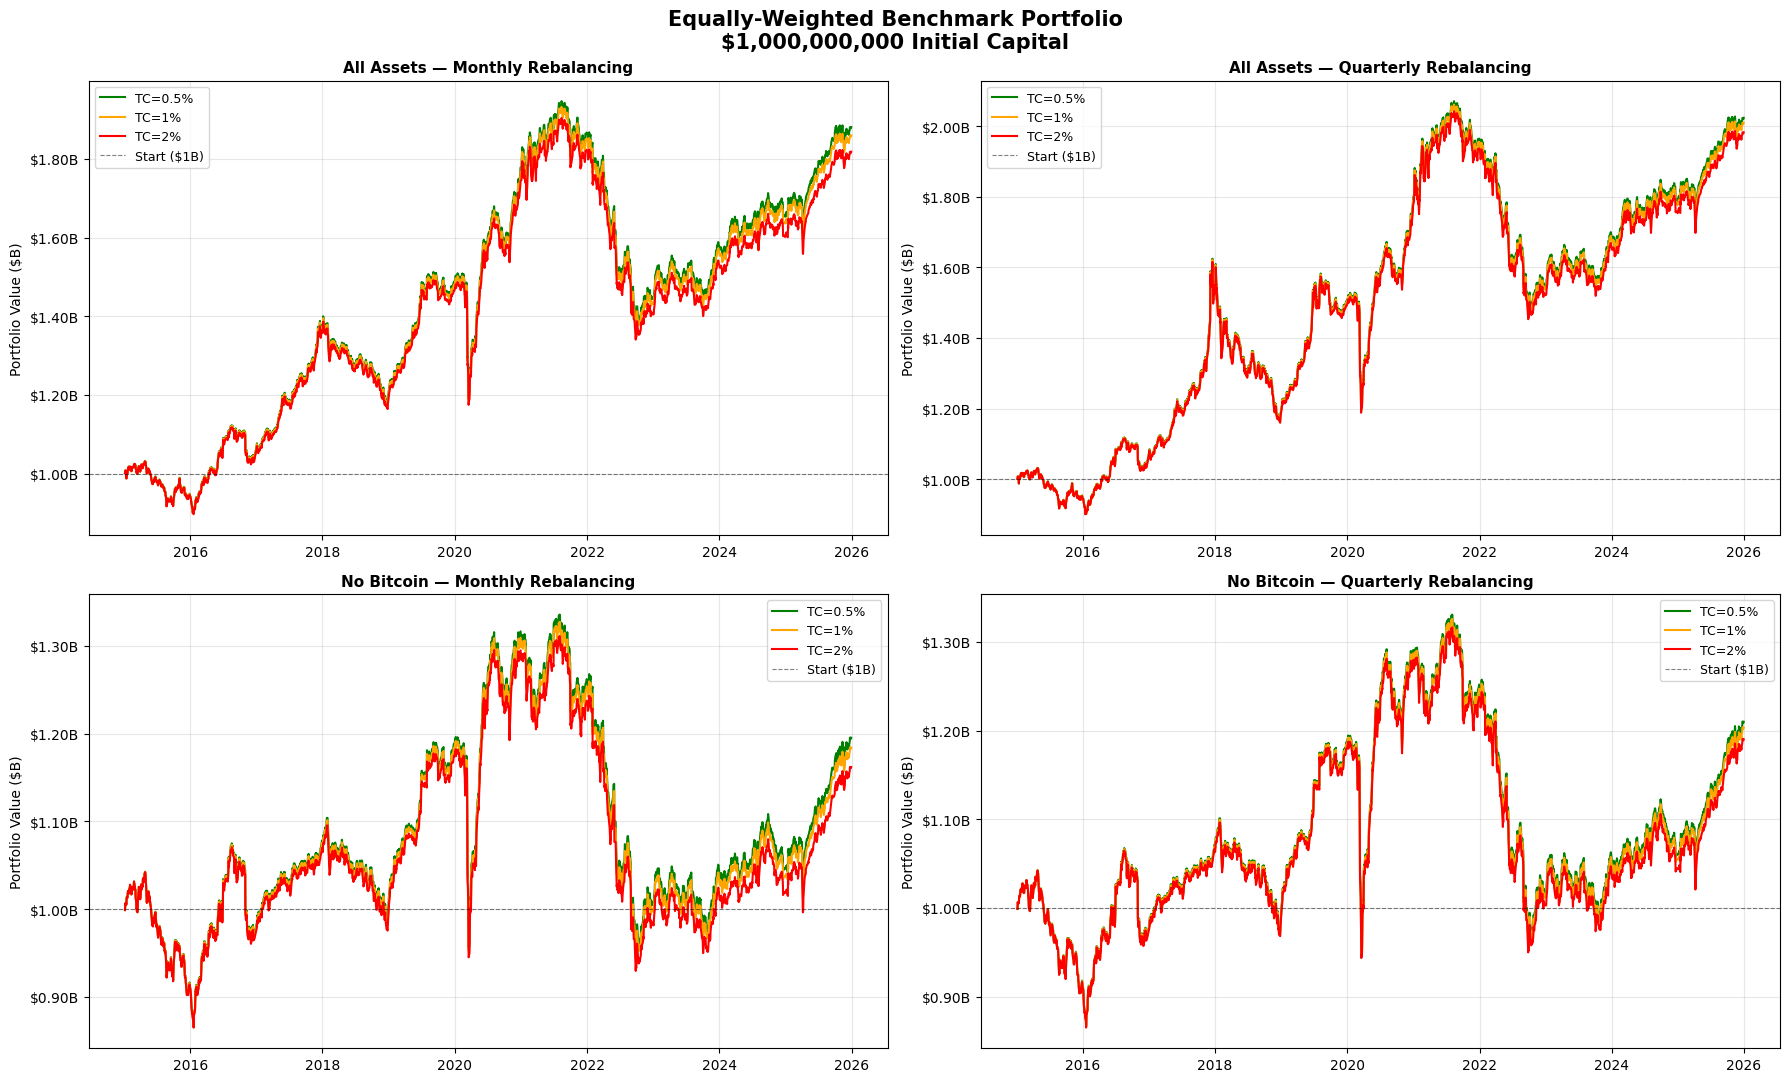


Plot saved as ew_benchmark_fixed.png


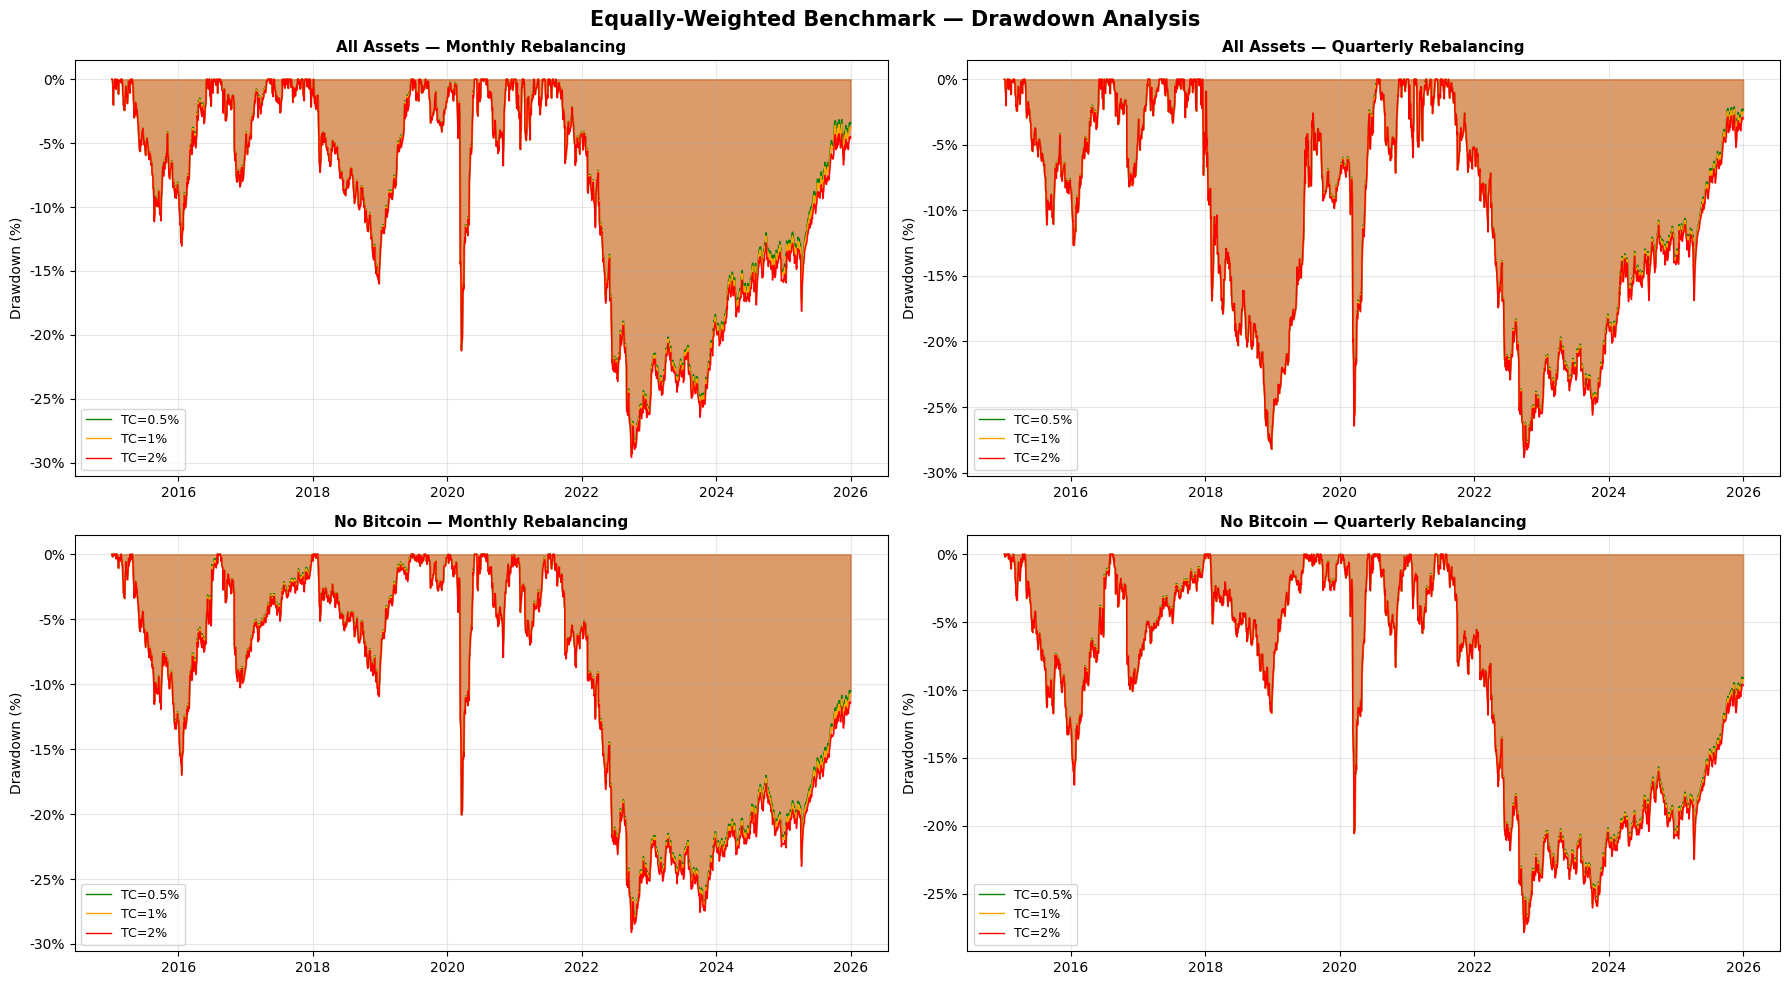

Drawdown plot saved as ew_benchmark_drawdown_fixed.png


In [25]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from io import StringIO

# ── 1. Load data ──────────────────────────────────────────────────────────────
def load_macro():
    url = "https://raw.githubusercontent.com/kboroz/MSFE_Capstone_Project/main/01_Data/Streamlined/streamlined_macro.csv"
    response = requests.get(url)
    df = pd.read_csv(StringIO(response.text), index_col=0, parse_dates=True)
    df.columns = df.columns.str.replace('[^a-zA-Z0-9]', '_', regex=True)
    return df.sort_index().dropna(how='all')

macro_df = load_macro()

# ── 2. Asset classification ───────────────────────────────────────────────────
EQUITY_INDICES = ['ASX50', 'Ibovespa', 'FTSE100', 'SP500', 'JSE40', 'NIKKEI225', 'EUROSTOXX50']
FX             = ['AUDUSD', 'BRLUSD', 'EURUSD', 'GBPUSD', 'JPYUSD', 'ZARUSD']
COMMODITIES    = ['Oil', 'Gold', 'Bitcoin']
BONDS          = ['US_10Y', 'DE_10Y', 'UK_10Y', 'JP_10Y', 'AU_10Y', 'ZA_10Y']
# VIX excluded — not directly investable as a price series

# Problem assets:
# JP_10Y, DE_10Y → near-zero/negative yields → infinite pct_change → EXCLUDE
# Oil            → went negative April 2020 → pct_change explodes → HANDLE
# VIX            → not investable → EXCLUDE

SAFE_BONDS     = ['US_10Y', 'UK_10Y', 'AU_10Y', 'ZA_10Y']  # JP & DE excluded
COMMODITIES_NO_OIL = ['Gold', 'Bitcoin']

ALL_ASSETS     = EQUITY_INDICES + FX + ['Oil', 'Gold', 'Bitcoin'] + SAFE_BONDS
NO_BTC_ASSETS  = [a for a in ALL_ASSETS if a != 'Bitcoin']

print(f"All Assets  ({len(ALL_ASSETS)}): {ALL_ASSETS}")
print(f"No Bitcoin  ({len(NO_BTC_ASSETS)}): {NO_BTC_ASSETS}")

# ── 3. Build clean returns ────────────────────────────────────────────────────
# Step 1: raw pct_change
returns_raw = macro_df[ALL_ASSETS].pct_change(fill_method=None)

# Step 2: Invert bond yields (price proxy — rising yield = falling price)
for col in SAFE_BONDS:
    returns_raw[col] = -returns_raw[col]

# Step 3: Fix Oil — set return to -99% on the day it went negative (Apr 2020)
# Any day where Oil price in raw data <= 0 makes pct_change unreliable
oil_prices = macro_df['Oil']
bad_oil_days = oil_prices[oil_prices <= 0].index
if len(bad_oil_days) > 0:
    print(f"\nOil negative/zero price days: {bad_oil_days.tolist()}")
    # Set return on those days and surrounding days to 0
    for d in bad_oil_days:
        loc = returns_raw.index.get_loc(d)
        returns_raw.iloc[max(0,loc-1):loc+2, returns_raw.columns.get_loc('Oil')] = 0.0

# Step 4: Clip all returns to [-50%, +100%] — removes inf/-inf and extreme outliers
returns_raw = returns_raw.clip(lower=-0.50, upper=1.00)

# Step 5: Drop first row (NaN from pct_change)
returns_raw = returns_raw.iloc[1:]

# ── 4. Verify no inf/nan remains ──────────────────────────────────────────────
print(f"\nInf values  : {np.isinf(returns_raw).sum().sum()}")
print(f"NaN values  : {returns_raw.isna().sum().sum()}")
print(f"Returns shape: {returns_raw.shape}")
print(f"Date range   : {returns_raw.index[0].date()} → {returns_raw.index[-1].date()}")

# Check extremes after cleaning
print("\n=== Extremes after cleaning (>40% or <-40%) ===")
for col in returns_raw.columns:
    extremes = returns_raw[col][np.abs(returns_raw[col]) > 0.40]
    if len(extremes) > 0:
        print(f"  {col:15s}: {len(extremes)} days | min={extremes.min():.2%} max={extremes.max():.2%}")

# ── 5. Backtest function ──────────────────────────────────────────────────────
def ew_backtest(returns_df, assets, freq_code, tc_rate, initial_capital):
    """
    Equally-weighted backtest with transaction costs.

    Parameters
    ----------
    returns_df    : daily returns DataFrame (clean, no inf/nan)
    assets        : list of asset column names
    freq_code     : 'ME' = month-end, 'QE' = quarter-end
    tc_rate       : one-way transaction cost (e.g. 0.01 = 1%)
    initial_capital: starting capital in USD
    """
    rets = returns_df[assets].fillna(0.0).copy()
    n    = len(assets)

    # Rebalance dates
    rebal_dates = set(rets.resample(freq_code).last().index)

    # Initialise
    portfolio_value = initial_capital
    weights         = np.ones(n) / n          # equal weight at start
    values          = []

    for date, row in rets.iterrows():

        # ── Rebalance ────────────────────────────────────────────────────────
        if date in rebal_dates:
            target_weights = np.ones(n) / n
            turnover       = np.abs(weights - target_weights).sum() / 2
            tc_cost        = turnover * tc_rate
            portfolio_value *= (1 - tc_cost)
            weights         = target_weights.copy()

        # ── Daily return ─────────────────────────────────────────────────────
        daily_ret    = np.dot(weights, row.values)
        portfolio_value *= (1 + daily_ret)

        # ── Update weights (drift) ────────────────────────────────────────────
        new_weights = weights * (1 + row.values)
        weight_sum  = new_weights.sum()

        if weight_sum <= 0 or np.isnan(weight_sum) or np.isinf(weight_sum):
            # Safety: reset to equal weight (shouldn't happen after cleaning)
            weights = np.ones(n) / n
        else:
            weights = new_weights / weight_sum

        values.append(portfolio_value)

    return pd.Series(values, index=rets.index, name=f"EW_{freq_code}_TC{tc_rate}")

# ── 6. Run all combinations ───────────────────────────────────────────────────
UNIVERSES  = {'All_Assets': ALL_ASSETS, 'No_Bitcoin': NO_BTC_ASSETS}
FREQS      = {'Monthly': 'ME', 'Quarterly': 'QE'}
TC_LEVELS  = [0.005, 0.01, 0.02]
INITIAL    = 1_000_000_000

results = {}
for univ_name, assets in UNIVERSES.items():
    for freq_name, freq_code in FREQS.items():
        for tc in TC_LEVELS:
            label = f"{univ_name} | {freq_name} | TC={int(tc*100)}%"
            series = ew_backtest(returns_raw, assets, freq_code, tc, INITIAL)
            results[label] = series
            final_b = series.iloc[-1] / 1e9
            print(f"✓ {label:45s} → Final: ${final_b:.3f}B")

# ── 7. Performance metrics ────────────────────────────────────────────────────
def performance_metrics(series, initial=INITIAL, rf=0.03):
    daily_rets = series.pct_change(fill_method=None).dropna()
    n_years    = len(daily_rets) / 252

    total_ret  = (series.iloc[-1] / initial) - 1
    cagr       = (series.iloc[-1] / initial) ** (1 / n_years) - 1
    ann_vol    = daily_rets.std() * np.sqrt(252)
    sharpe     = (cagr - rf) / ann_vol if ann_vol > 0 else np.nan

    rolling_max = series.cummax()
    drawdown    = (series - rolling_max) / rolling_max
    max_dd      = drawdown.min()
    calmar      = cagr / abs(max_dd) if max_dd != 0 else np.nan

    var_95      = daily_rets.quantile(0.05)
    final_val   = series.iloc[-1]

    return {
        'Total Return (%)':      round(total_ret * 100, 2),
        'CAGR (%)':              round(cagr * 100, 2),
        'Ann. Volatility (%)':   round(ann_vol * 100, 2),
        'Sharpe Ratio':          round(sharpe, 3),
        'Max Drawdown (%)':      round(max_dd * 100, 2),
        'Calmar Ratio':          round(calmar, 3),
        'VaR 95% (daily %)':     round(var_95 * 100, 3),
        'Final Value ($B)':      round(final_val / 1e9, 3),
    }

metrics_df = pd.DataFrame({k: performance_metrics(v) for k, v in results.items()}).T
metrics_df.index.name = 'Strategy'

print("\n" + "="*100)
print("EQUALLY-WEIGHTED BENCHMARK — PERFORMANCE SUMMARY")
print("="*100)
print(metrics_df.to_string())

# ── 8. Portfolio Value Plot ───────────────────────────────────────────────────
colors_tc  = {0.005: 'green', 0.01: 'orange', 0.02: 'red'}
tc_labels  = {0.005: 'TC=0.5%', 0.01: 'TC=1%', 0.02: 'TC=2%'}

fig, axes = plt.subplots(2, 2, figsize=(18, 11))
fig.suptitle("Equally-Weighted Benchmark Portfolio\n$1,000,000,000 Initial Capital",
             fontsize=15, fontweight='bold')

for ax_idx, (univ_name, _) in enumerate(UNIVERSES.items()):
    for freq_idx, (freq_name, _) in enumerate(FREQS.items()):
        ax = axes[ax_idx][freq_idx]
        for tc in TC_LEVELS:
            label  = f"{univ_name} | {freq_name} | TC={int(tc*100)}%"
            series = results[label]
            ax.plot(series.index, series.values / 1e9,
                    label=tc_labels[tc], color=colors_tc[tc], linewidth=1.5)

        # Add $1B reference line
        ax.axhline(1.0, color='black', linestyle='--', linewidth=0.8, alpha=0.5, label='Start ($1B)')
        ax.set_title(f"{univ_name.replace('_',' ')} — {freq_name} Rebalancing",
                     fontsize=11, fontweight='bold')
        ax.set_ylabel("Portfolio Value ($B)")
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.2f}B"))
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("ew_benchmark_fixed.png", dpi=150, bbox_inches='tight')
plt.show()
print("\nPlot saved as ew_benchmark_fixed.png")

# ── 9. Drawdown Plot ──────────────────────────────────────────────────────────
fig2, axes2 = plt.subplots(2, 2, figsize=(18, 10))
fig2.suptitle("Equally-Weighted Benchmark — Drawdown Analysis",
              fontsize=15, fontweight='bold')

for ax_idx, (univ_name, _) in enumerate(UNIVERSES.items()):
    for freq_idx, (freq_name, _) in enumerate(FREQS.items()):
        ax = axes2[ax_idx][freq_idx]
        for tc in TC_LEVELS:
            label  = f"{univ_name} | {freq_name} | TC={int(tc*100)}%"
            series = results[label]
            dd     = (series - series.cummax()) / series.cummax() * 100
            ax.fill_between(dd.index, dd.values, 0,
                            alpha=0.25, color=colors_tc[tc])
            ax.plot(dd.index, dd.values,
                    color=colors_tc[tc], linewidth=1.0, label=tc_labels[tc])
        ax.set_title(f"{univ_name.replace('_',' ')} — {freq_name} Rebalancing",
                     fontsize=11, fontweight='bold')
        ax.set_ylabel("Drawdown (%)")
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("ew_benchmark_drawdown_fixed.png", dpi=150, bbox_inches='tight')
plt.show()
print("Drawdown plot saved as ew_benchmark_drawdown_fixed.png")

# Run All Strategies Together

In [32]:
# ── DIAGNOSTIC ────────────────────────────────────────────────────────────────
# Check 1: What assets are actually in macro_df vs signal files
print("macro_df columns:", macro_df.columns.tolist())
print("\nEquity assets in signal_files:", equity_assets)
print("Matched in macro_df:", [a for a in equity_assets if a in macro_df.columns])
print("NOT matched in macro_df:", [a for a in equity_assets if a not in macro_df.columns])

# Check 2: Signal values
print("\nSignal_df sample:")
print(signal_df.head(10))
print("\nSignal unique values per asset:")
print(signal_df.apply(lambda x: x.dropna().unique()))

# Check 3: Returns sanity
print("\nReturns describe (first 5 cols):")
print(returns.iloc[:, :5].describe())

# Check 4: Trace portfolio value for first 30 days
print("\n── Tracing first rebalance ──")
N = len(all_assets)
base_weight = 1.0 / N
print(f"N assets: {N}, base_weight: {base_weight:.4f}")

signal_df_copy = signal_df.copy()
signal_df_copy.index = pd.to_datetime(signal_df_copy.index)

first_reb = returns.index[0]
past_signals = signal_df_copy[signal_df_copy.index <= first_reb]
sig_today = past_signals.iloc[-1] if len(past_signals) > 0 else None

raw_weights = {}
for a in non_equity_assets:
    raw_weights[a] = base_weight
for a in equity_assets:
    if sig_today is not None and a in sig_today.index:
        sig = sig_today[a]
        raw_weights[a] = base_weight if sig >= 0 else -base_weight
    else:
        raw_weights[a] = base_weight

print(f"\nRaw weights before reinvestment:")
for k, v in raw_weights.items():
    print(f"  {k}: {v:.4f}")

short_proceeds = sum(abs(w) for w in raw_weights.values() if w < 0)
long_assets    = [a for a, w in raw_weights.items() if w > 0]
n_long         = len(long_assets)

print(f"\nShort proceeds: {short_proceeds:.4f}")
print(f"Num long assets: {n_long}")
print(f"Extra per long: {short_proceeds/n_long if n_long > 0 else 0:.4f}")

for a in long_assets:
    raw_weights[a] += short_proceeds / n_long if n_long > 0 else 0

total_weight = sum(raw_weights.values())
print(f"\nTotal weight after reinvestment: {total_weight:.4f}")
print(f"Sum of |weights|: {sum(abs(v) for v in raw_weights.values()):.4f}")

# Check 5: First 30 days portfolio value
pf = 1e9
cw = raw_weights.copy()
pf *= (1 - 0.005)  # initial TC
print(f"\nPortfolio value after initial TC: {pf:.0f}")

for i, date in enumerate(returns.index[:30]):
    dr = sum(cw.get(a, 0) * returns.loc[date, a] for a in all_assets)
    pf *= (1 + dr)
    if i < 5 or pf < 0:
        print(f"  Day {i}: date={date.date()}, daily_ret={dr:.4%}, pf={pf:,.0f}")
    if pf <= 0:
        print("  *** PORTFOLIO WENT NEGATIVE ***")
        break


macro_df columns: ['AUDUSD', 'BRLUSD', 'Bitcoin', 'Oil', 'EURUSD', 'GBPUSD', 'Gold', 'JPYUSD', 'ZARUSD', 'ASX50', 'Ibovespa', 'FTSE100', 'SP500', 'JSE40', 'NIKKEI225', 'EUROSTOXX50', 'VIX', 'US_10Y', 'DE_10Y', 'UK_10Y', 'JP_10Y', 'AU_10Y', 'ZA_10Y']

Equity assets in signal_files: ['ASX50', 'FTSE100', 'GDAXI', 'HSI', 'N225', 'NIFTY50', 'SP500']
Matched in macro_df: ['ASX50', 'FTSE100', 'SP500']
NOT matched in macro_df: ['GDAXI', 'HSI', 'N225', 'NIFTY50']

Signal_df sample:
Empty DataFrame
Columns: []
Index: []

Signal unique values per asset:
Series([], dtype: float64)

Returns describe (first 5 cols):
            AUDUSD       BRLUSD      Bitcoin          Oil       EURUSD
count  2413.000000  2413.000000  2413.000000  2413.000000  2413.000000
mean     -0.000054    -0.000237     0.003441    -0.001196     0.000008
std       0.006862     0.011358     0.045602     0.074824     0.005335
min      -0.053105    -0.069932    -0.371695    -3.059661    -0.028169
25%      -0.004214    -0.006499    

macro_df shape : (2413, 23)
Date range     : 2015-01-05 → 2025-12-30
Columns        : ['AUDUSD', 'BRLUSD', 'Bitcoin', 'Oil', 'EURUSD', 'GBPUSD', 'Gold', 'JPYUSD', 'ZARUSD', 'ASX50', 'Ibovespa', 'FTSE100', 'SP500', 'JSE40', 'NIKKEI225', 'EUROSTOXX50', 'VIX', 'US_10Y', 'DE_10Y', 'UK_10Y', 'JP_10Y', 'AU_10Y', 'ZA_10Y']

Assets in universe (20): ['ASX50', 'Ibovespa', 'FTSE100', 'SP500', 'JSE40', 'NIKKEI225', 'EUROSTOXX50', 'AUDUSD', 'BRLUSD', 'EURUSD', 'GBPUSD', 'JPYUSD', 'ZARUSD', 'Oil', 'Gold', 'Bitcoin', 'US_10Y', 'UK_10Y', 'AU_10Y', 'ZA_10Y']

Oil negative price days found: [Timestamp('2020-04-20 00:00:00')]

Returns shape : (2412, 20)
Date range    : 2015-01-06 → 2025-12-30
✓ Returns clean — no NaN or Inf
✗ ASX50: HTTP Error 404: Not Found
✗ FTSE100: HTTP Error 404: Not Found
✗ SP500: HTTP Error 404: Not Found

signal_df shape   : (0, 0)
signal_df columns : []
Empty DataFrame
Columns: []
Index: []

Equity (signal-driven)  : []
Non-equity (always long): ['ASX50', 'Ibovespa', 'FTSE100',

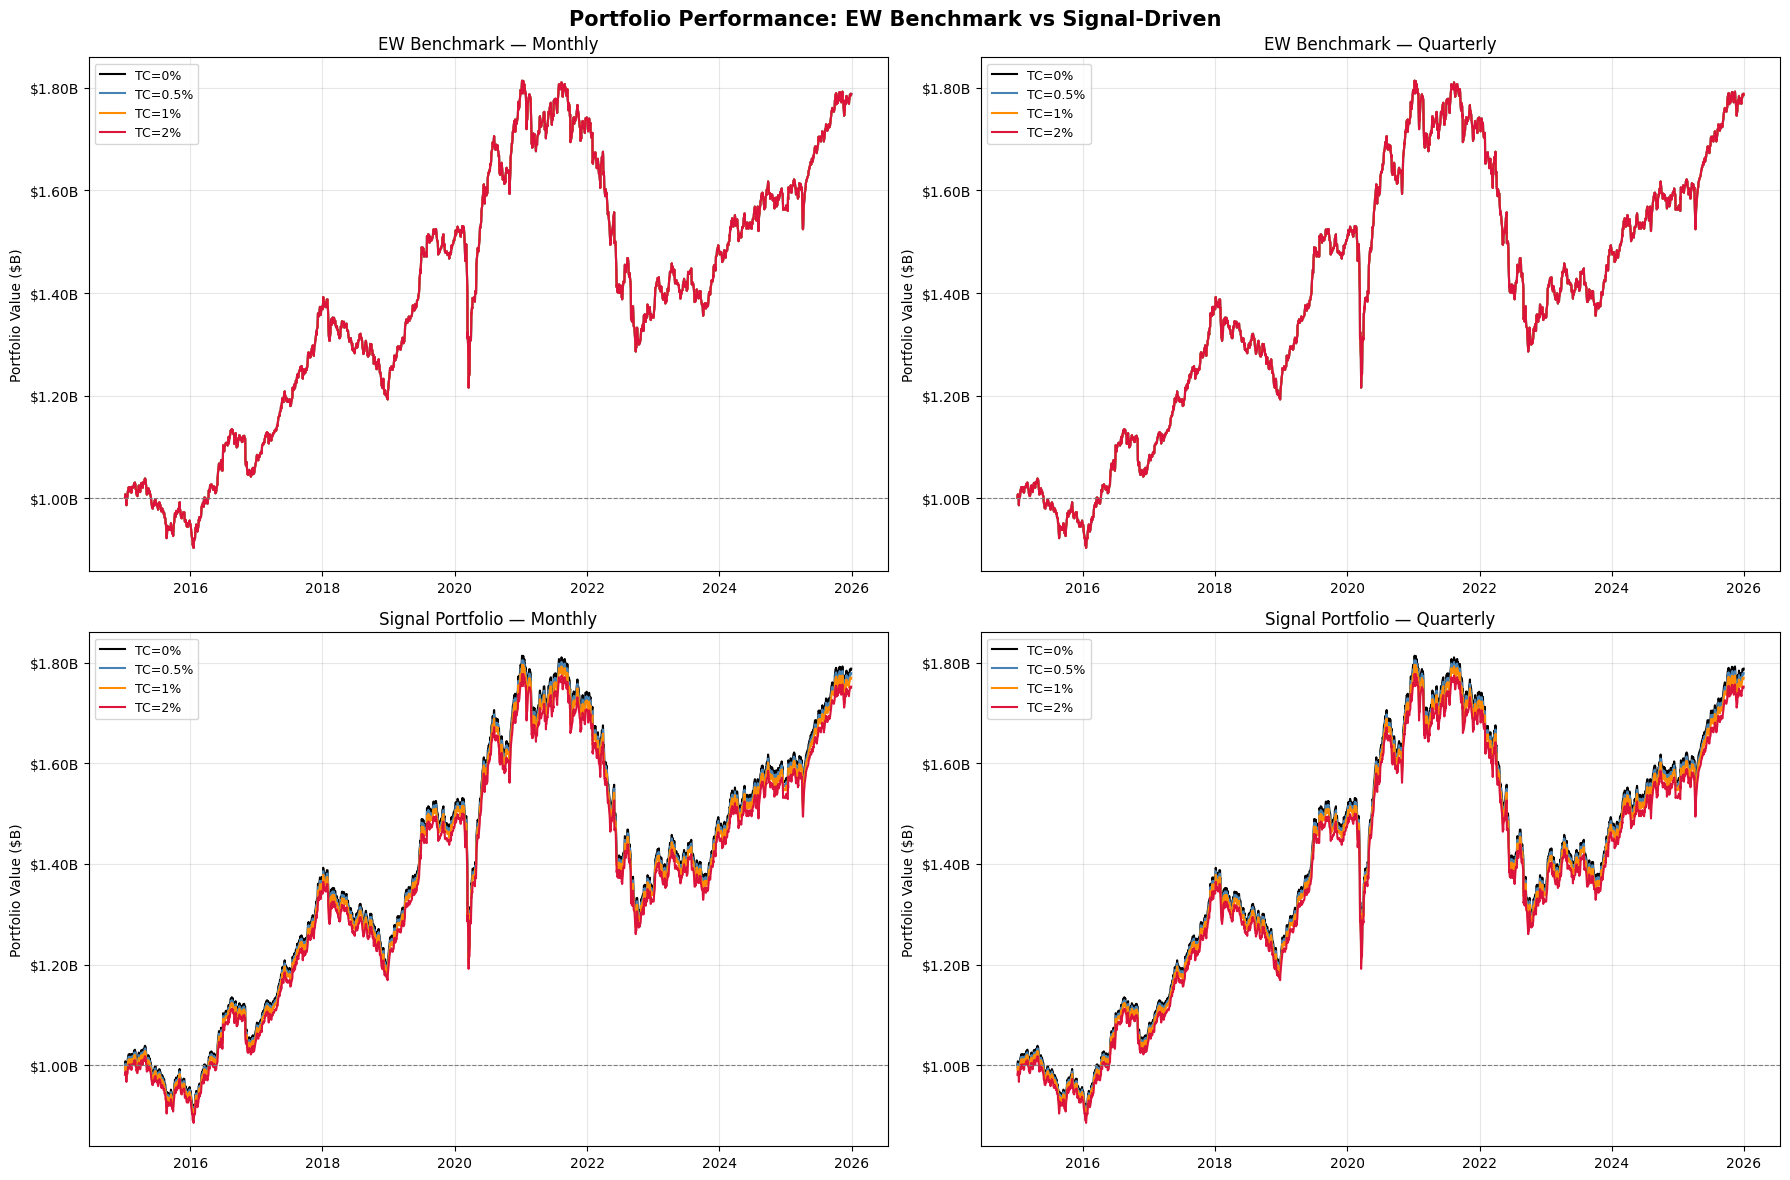

✓ Plot saved.
✓ All CSVs saved.


In [35]:
# ============================================================
# SIGNAL PORTFOLIO — FULL SELF-CONTAINED COLAB VERSION
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import requests
from io import StringIO

# ── 1. LOAD MACRO DATA ────────────────────────────────────────────────────────
GITHUB_BASE = "https://raw.githubusercontent.com/kboroz/MSFE_Capstone_Project/main/01_Data/Streamlined/"

def load_macro():
    url      = GITHUB_BASE + "streamlined_macro.csv"
    response = requests.get(url)
    df       = pd.read_csv(StringIO(response.text), index_col=0, parse_dates=True)
    df.columns = df.columns.str.replace('[^a-zA-Z0-9]', '_', regex=True)
    return df.sort_index()

macro_df = load_macro()
macro_df = macro_df[~macro_df.index.duplicated(keep='first')].sort_index()

print(f"macro_df shape : {macro_df.shape}")
print(f"Date range     : {macro_df.index[0].date()} → {macro_df.index[-1].date()}")
print(f"Columns        : {macro_df.columns.tolist()}")

# ── 2. DEFINE ASSET UNIVERSE ──────────────────────────────────────────────────
# Map from macro_df column names to portfolio names
# Adjust these to match your actual macro_df column names
EQUITY_INDICES = ['ASX50', 'Ibovespa', 'FTSE100', 'SP500',
                  'JSE40', 'NIKKEI225', 'EUROSTOXX50']
FX             = ['AUDUSD', 'BRLUSD', 'EURUSD', 'GBPUSD', 'JPYUSD', 'ZARUSD']
COMMODITIES    = ['Oil', 'Gold', 'Bitcoin']
SAFE_BONDS     = ['US_10Y', 'UK_10Y', 'AU_10Y', 'ZA_10Y']  # JP & DE excluded

ALL_ASSETS = EQUITY_INDICES + FX + COMMODITIES + SAFE_BONDS

# Keep only those actually in macro_df
ALL_ASSETS = [a for a in ALL_ASSETS if a in macro_df.columns]

print(f"\nAssets in universe ({len(ALL_ASSETS)}): {ALL_ASSETS}")
missing = [a for a in EQUITY_INDICES + FX + COMMODITIES + SAFE_BONDS
           if a not in macro_df.columns]
if missing:
    print(f"WARNING — Not found in macro_df: {missing}")

# ── 3. BUILD CLEAN RETURNS ────────────────────────────────────────────────────
returns_raw = macro_df[ALL_ASSETS].pct_change(fill_method=None)

# Invert bond yields (rising yield = falling price)
for col in SAFE_BONDS:
    if col in returns_raw.columns:
        returns_raw[col] = -returns_raw[col]

# Fix Oil negative price days (April 2020)
if 'Oil' in macro_df.columns:
    bad_oil = macro_df['Oil'][macro_df['Oil'] <= 0].index
    if len(bad_oil) > 0:
        print(f"\nOil negative price days found: {bad_oil.tolist()}")
        for d in bad_oil:
            loc = returns_raw.index.get_loc(d)
            returns_raw.iloc[
                max(0, loc - 1): loc + 2,
                returns_raw.columns.get_loc('Oil')
            ] = 0.0

# Clip extremes, fill NaN, drop first row
returns = returns_raw.clip(lower=-0.50, upper=1.00).fillna(0).iloc[1:]

print(f"\nReturns shape : {returns.shape}")
print(f"Date range    : {returns.index[0].date()} → {returns.index[-1].date()}")

# Quick sanity check — no inf/nan
assert not returns.isnull().any().any(), "NaNs remain in returns"
assert not np.isinf(returns.values).any(), "Inf values remain in returns"
print("✓ Returns clean — no NaN or Inf")

# ── 4. LOAD SIGNAL FILES ──────────────────────────────────────────────────────
# These are the equity indices for which you computed modified-determinant signals
# Signal files must contain a column with 'signal' in the name, values +1 or -1

SIGNAL_FILE_MAP = {
    'ASX50':   'ASX50_signals.csv',
    'FTSE100': 'FTSE100_signals.csv',
    'SP500':   'SP500_signals.csv',
}

signals = {}
for asset, fname in SIGNAL_FILE_MAP.items():
    if asset not in ALL_ASSETS:
        print(f"Skipping {asset} — not in universe")
        continue
    try:
        url = GITHUB_BASE + fname
        df  = pd.read_csv(url, index_col=0, parse_dates=True)
        df.index = pd.to_datetime(df.index)

        # Find signal column
        sig_col = next(
            (c for c in df.columns if 'signal' in c.lower()),
            df.columns[-1]
        )
        s = df[sig_col].rename(asset)

        # Standardise: any positive → +1, any negative → -1, zero/nan → +1 (default long)
        s = s.apply(lambda x: 1 if (pd.isna(x) or x >= 0) else -1)

        signals[asset] = s
        print(f"✓ {asset} | rows={len(s)} | "
              f"RISK_ON(+1)={( s==1).sum()} | RISK_OFF(-1)={(s==-1).sum()}")

    except Exception as e:
        print(f"✗ {asset}: {e}")

signal_df = pd.DataFrame(signals).sort_index()
signal_df.index = pd.to_datetime(signal_df.index)

print(f"\nsignal_df shape   : {signal_df.shape}")
print(f"signal_df columns : {signal_df.columns.tolist()}")
print(signal_df.tail())

# ── 5. ASSET GROUPS ───────────────────────────────────────────────────────────
# Equity assets that have signals
equity_assets     = [a for a in SIGNAL_FILE_MAP.keys()
                     if a in ALL_ASSETS and a in signal_df.columns]
# Everything else — always held long
non_equity_assets = [a for a in ALL_ASSETS if a not in equity_assets]

N           = len(ALL_ASSETS)
base_weight = 1.0 / N

print(f"\nEquity (signal-driven)  : {equity_assets}")
print(f"Non-equity (always long): {non_equity_assets}")
print(f"N={N}, base_weight={base_weight:.4f}, "
      f"equal-weight sum={N*base_weight:.4f}")

# ── 6. WEIGHT CONSTRUCTION LOGIC ─────────────────────────────────────────────
def build_weights(sig_row, equity_assets, non_equity_assets, base_weight, date):
    """
    Rules:
      - Non-equity: always +base_weight (long)
      - Equity with signal +1 (RISK_ON) : +base_weight (long)
      - Equity with signal -1 (RISK_OFF): -base_weight (short)
      - Short proceeds reinvested equally across all long positions
      - Final weights must sum to exactly 1.0
    """
    raw = {}

    # Non-equity always long
    for a in non_equity_assets:
        raw[a] = base_weight

    # Equity — signal driven
    for a in equity_assets:
        if sig_row is not None and a in sig_row.index and not pd.isna(sig_row[a]):
            raw[a] = base_weight if sig_row[a] >= 0 else -base_weight
        else:
            raw[a] = base_weight  # default long if no signal

    # Reinvest short proceeds equally into long positions
    short_proceeds = sum(abs(w) for w in raw.values() if w < 0)
    long_assets    = [a for a, w in raw.items() if w > 0]
    n_long         = len(long_assets)

    if short_proceeds > 0 and n_long > 0:
        extra = short_proceeds / n_long
        for a in long_assets:
            raw[a] += extra

    # Hard check
    total = sum(raw.values())
    if abs(total - 1.0) > 1e-6:
        raise ValueError(
            f"Weights sum to {total:.8f} on {date} — "
            f"short_proceeds={short_proceeds:.4f}, n_long={n_long}"
        )

    return raw

# ── 7. EQUAL-WEIGHT BENCHMARK ─────────────────────────────────────────────────
def run_equal_weight(returns, all_assets, tc_rate=0.005,
                     rebal_freq='monthly', initial_capital=1e9):

    freq_code = 'MS' if rebal_freq == 'monthly' else 'QS'
    reb_dates_raw = returns.resample(freq_code).first().index
    actual_dates  = returns.index

    reb_set = set()
    for d in reb_dates_raw:
        future = actual_dates[actual_dates >= d]
        if len(future) > 0:
            reb_set.add(future[0])

    N           = len(all_assets)
    base        = 1.0 / N
    pv          = float(initial_capital)
    cur_weights = {a: base for a in all_assets}
    records     = []

    for date in actual_dates:
        if date in reb_set:
            target   = {a: base for a in all_assets}
            turnover = sum(abs(target.get(a, 0) - cur_weights.get(a, 0))
                           for a in all_assets) / 2.0
            pv          *= (1 - turnover * tc_rate)
            cur_weights  = target.copy()

        dr  = sum(cur_weights.get(a, 0) * returns.loc[date, a]
                  for a in all_assets)
        pv *= (1 + dr)
        records.append({'date': date, 'portfolio_value': pv})

    return pd.DataFrame(records).set_index('date')

# ── 8. SIGNAL-DRIVEN PORTFOLIO ────────────────────────────────────────────────
def run_signal_portfolio(returns, signal_df, equity_assets, non_equity_assets,
                          all_assets, freq='monthly', tc_rate=0.005,
                          initial_capital=1e9):

    N           = len(all_assets)
    base_weight = 1.0 / N

    freq_code     = 'MS' if freq == 'monthly' else 'QS'
    reb_dates_raw = returns.resample(freq_code).first().index
    actual_dates  = returns.index

    reb_set = set()
    for d in reb_dates_raw:
        future = actual_dates[actual_dates >= d]
        if len(future) > 0:
            reb_set.add(future[0])

    sig = signal_df.copy()
    sig.index = pd.to_datetime(sig.index)

    pv              = float(initial_capital)
    current_weights = None
    records         = []

    for date in actual_dates:

        # ── Rebalance ──────────────────────────────────────────────────────
        if date in reb_set:
            past     = sig[sig.index <= date]
            sig_row  = past.iloc[-1] if len(past) > 0 else None

            raw = build_weights(
                sig_row, equity_assets, non_equity_assets, base_weight, date
            )

            # Transaction cost on turnover
            if current_weights is not None:
                all_keys = set(raw) | set(current_weights)
                turnover = sum(
                    abs(raw.get(a, 0) - current_weights.get(a, 0))
                    for a in all_keys
                ) / 2.0
                tc = turnover * tc_rate
            else:
                # First rebalance — assume full portfolio turnover
                tc = tc_rate

            pv             *= (1 - tc)
            current_weights = raw.copy()

        # ── Daily P&L ──────────────────────────────────────────────────────
        if current_weights is not None:
            dr  = sum(current_weights.get(a, 0) * returns.loc[date, a]
                      for a in all_assets)
            pv *= (1 + dr)

        records.append({'date': date, 'portfolio_value': pv})

    return pd.DataFrame(records).set_index('date')

# ── 9. RUN ALL PORTFOLIOS ─────────────────────────────────────────────────────
TC_LEVELS  = {'0%': 0.00, '0.5%': 0.005, '1%': 0.01, '2%': 0.02}
FREQS      = ['monthly', 'quarterly']

# Benchmarks
ew_results = {}
for tc_label, tc_rate in TC_LEVELS.items():
    for freq in FREQS:
        label = f"EW_{freq}_TC{tc_label}"
        ew_results[label] = run_equal_weight(
            returns, ALL_ASSETS, tc_rate=tc_rate,
            rebal_freq=freq, initial_capital=1e9
        )
        print(f"✓ {label}")

# Signal portfolios
signal_results = {}
for freq in FREQS:
    for tc_label, tc_rate in TC_LEVELS.items():
        label = f"Signal_{freq}_TC{tc_label}"
        signal_results[label] = run_signal_portfolio(
            returns, signal_df, equity_assets, non_equity_assets,
            ALL_ASSETS, freq=freq, tc_rate=tc_rate, initial_capital=1e9
        )
        print(f"✓ {label}")

print("\n✓ All portfolios computed")

# ── 10. PERFORMANCE METRICS ───────────────────────────────────────────────────
def compute_metrics(pv_series):
    pv        = pv_series['portfolio_value']
    daily_ret = pv.pct_change().dropna()
    n_years   = len(daily_ret) / 252
    total_ret = (pv.iloc[-1] / pv.iloc[0]) - 1
    cagr      = (1 + total_ret) ** (1 / n_years) - 1 if n_years > 0 else np.nan
    vol       = daily_ret.std() * np.sqrt(252)
    sharpe    = cagr / vol if vol > 0 else np.nan
    roll_max  = pv.cummax()
    max_dd    = ((pv - roll_max) / roll_max).min()
    calmar    = cagr / abs(max_dd) if max_dd != 0 else np.nan
    var_95    = daily_ret.quantile(0.05)

    return {
        'CAGR':          f"{cagr*100:.2f}%",
        'Volatility':    f"{vol*100:.2f}%",
        'Sharpe':        f"{sharpe:.2f}",
        'Max Drawdown':  f"{max_dd*100:.2f}%",
        'Calmar':        f"{calmar:.2f}",
        'VaR 95%':       f"{var_95*100:.2f}%",
        'Total Return':  f"{total_ret*100:.2f}%",
        'Final ($B)':    f"{pv.iloc[-1]/1e9:.3f}",
    }

print("\n" + "="*80)
print("EQUALLY-WEIGHTED BENCHMARK")
print("="*80)
ew_metrics  = {k: compute_metrics(v) for k, v in ew_results.items()}
print(pd.DataFrame(ew_metrics).T.to_string())

print("\n" + "="*80)
print("SIGNAL-DRIVEN PORTFOLIO")
print("="*80)
sig_metrics = {k: compute_metrics(v) for k, v in signal_results.items()}
print(pd.DataFrame(sig_metrics).T.to_string())

# ── 11. PLOT ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle("Portfolio Performance: EW Benchmark vs Signal-Driven",
             fontsize=15, fontweight='bold')

colors = {'0%': 'black', '0.5%': 'steelblue', '1%': 'darkorange', '2%': 'crimson'}

for col_idx, freq in enumerate(FREQS):
    # EW
    ax = axes[0][col_idx]
    for tc_label in TC_LEVELS:
        label = f"EW_{freq}_TC{tc_label}"
        pv    = ew_results[label]['portfolio_value']
        ax.plot(pv.index, pv / 1e9, label=f"TC={tc_label}",
                color=colors[tc_label], lw=1.5)
    ax.axhline(1.0, color='grey', ls='--', lw=0.8)
    ax.set_title(f"EW Benchmark — {freq.capitalize()}", fontsize=12)
    ax.set_ylabel("Portfolio Value ($B)")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.2f}B"))
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    # Signal
    ax = axes[1][col_idx]
    for tc_label in TC_LEVELS:
        label = f"Signal_{freq}_TC{tc_label}"
        pv    = signal_results[label]['portfolio_value']
        ax.plot(pv.index, pv / 1e9, label=f"TC={tc_label}",
                color=colors[tc_label], lw=1.5)
    ax.axhline(1.0, color='grey', ls='--', lw=0.8)
    ax.set_title(f"Signal Portfolio — {freq.capitalize()}", fontsize=12)
    ax.set_ylabel("Portfolio Value ($B)")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.2f}B"))
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("portfolio_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print("✓ Plot saved.")

# ── 12. SAVE ──────────────────────────────────────────────────────────────────
for label, df in {**ew_results, **signal_results}.items():
    df.to_csv(f"{label}_portfolio.csv")

all_metrics = pd.DataFrame({**ew_metrics, **sig_metrics}).T
all_metrics.to_csv("all_portfolio_metrics.csv")
print("✓ All CSVs saved.")


macro_df shape : (2413, 23)
Columns        : ['AUDUSD', 'BRLUSD', 'Bitcoin', 'Oil', 'EURUSD', 'GBPUSD', 'Gold', 'JPYUSD', 'ZARUSD', 'ASX50', 'Ibovespa', 'FTSE100', 'SP500', 'JSE40', 'NIKKEI225', 'EUROSTOXX50', 'VIX', 'US_10Y', 'DE_10Y', 'UK_10Y', 'JP_10Y', 'AU_10Y', 'ZA_10Y']
✓ ASX50           | shape=(2413, 44) | cols=['ALD_AX', 'ALL_AX', 'ANZ_AX', 'APA_AX']
✓ EUROSTOXX50     | shape=(2413, 46) | cols=['ABI_BR', 'AD_AS', 'ADS_DE', 'AI_PA']
✓ FTSE100         | shape=(2413, 90) | cols=['AAL_L', 'ABF_L', 'ADM_L', 'ALW_L']
✓ Ibovespa        | shape=(2413, 56) | cols=['ABEV3_SA', 'ALPA4_SA', 'AMER3_SA', 'B3SA3_SA']
✓ JSE40           | shape=(2413, 31) | cols=['ABG_JO', 'AGL_JO', 'ANG_JO', 'APN_JO']
✓ NIKKEI225       | shape=(2413, 217) | cols=['1332_T', '1605_T', '1721_T', '1801_T']
✓ SP500           | shape=(2413, 460) | cols=['A', 'AAPL', 'ABBV', 'ABT']
  ASX50: using column 'ALD_AX'
  EUROSTOXX50: using column 'ABI_BR'
  FTSE100: using column 'AAL_L'
  Ibovespa: using column 'ABEV3_SA'


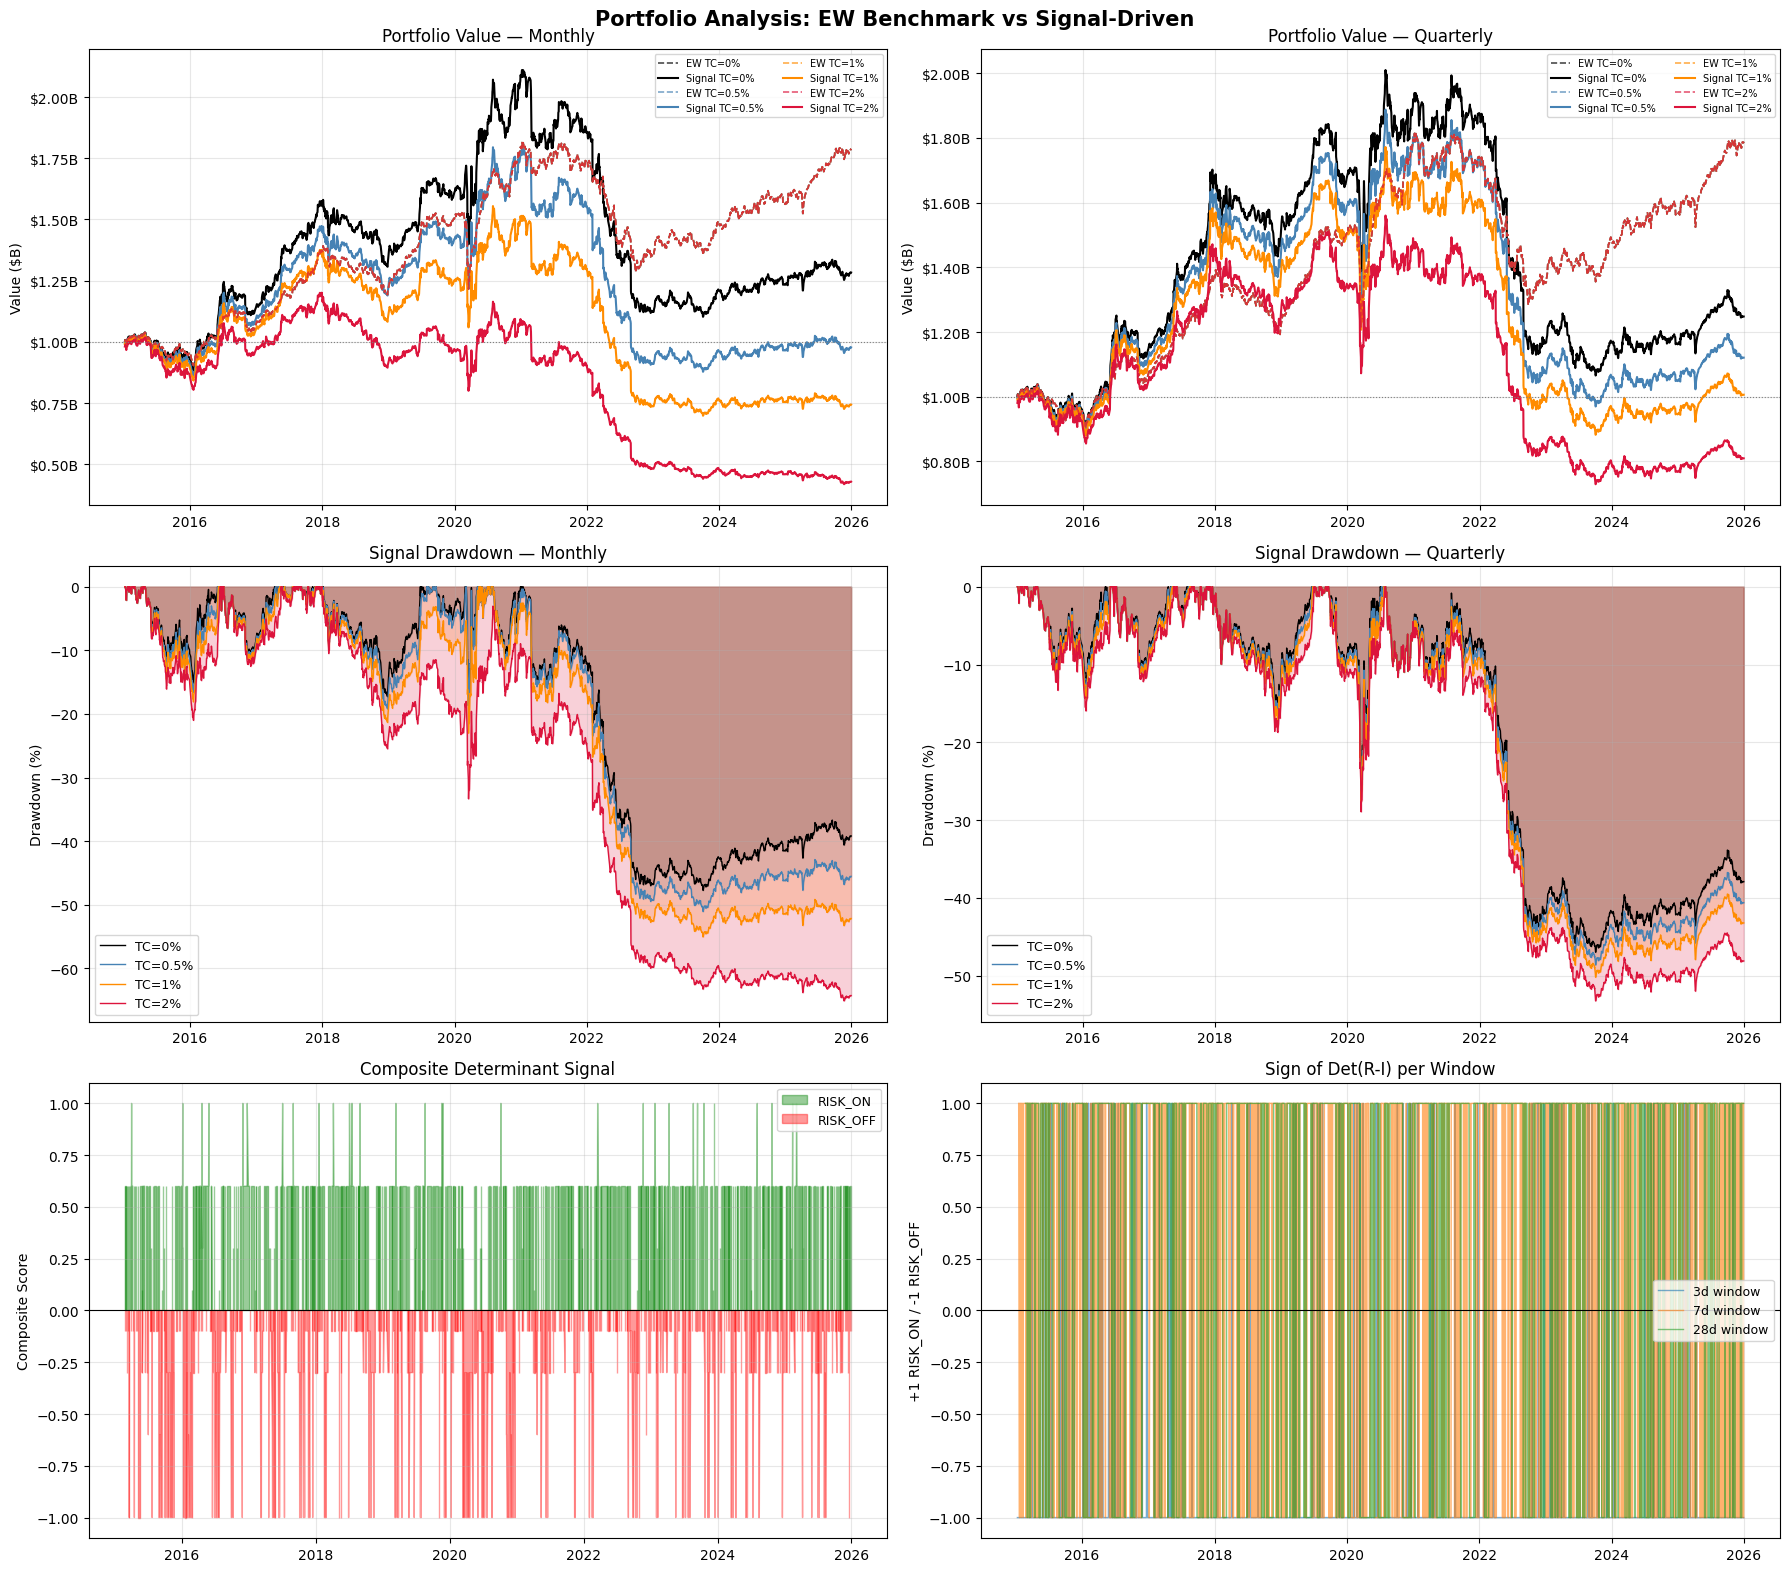

✓ Plot saved.
✓ All files saved.


In [37]:
# ============================================================
# SIGNAL PORTFOLIO — FULL SELF-CONTAINED VERSION
# Signals generated from Modified Determinant Model
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import requests
from io import StringIO

# ── 1. LOAD ALL DATA FROM GITHUB ─────────────────────────────────────────────
GITHUB_BASE = "https://raw.githubusercontent.com/kboroz/MSFE_Capstone_Project/main/01_Data/Streamlined/"

INDEX_FILE_MAP = {
    'ASX50':       'streamlined_asx_50.csv',
    'EUROSTOXX50': 'streamlined_euro_stoxx_50.csv',
    'FTSE100':     'streamlined_ftse_100.csv',
    'Ibovespa':    'streamlined_ibovespa.csv',
    'JSE40':       'streamlined_jse_top_40.csv',
    'NIKKEI225':   'streamlined_nikkei_225.csv',
    'SP500':       'streamlined_s&p_500.csv',
}

MACRO_FILE = 'streamlined_macro.csv'

def load_csv(url):
    r = requests.get(url)
    r.raise_for_status()
    df = pd.read_csv(StringIO(r.text), index_col=0, parse_dates=True)
    df.columns = df.columns.str.replace('[^a-zA-Z0-9]', '_', regex=True)
    return df.sort_index()

# Load macro
macro_df = load_csv(GITHUB_BASE + MACRO_FILE)
macro_df = macro_df[~macro_df.index.duplicated(keep='first')].sort_index()
print(f"macro_df shape : {macro_df.shape}")
print(f"Columns        : {macro_df.columns.tolist()}")

# Load individual index files (multi-column — OHLCV style)
index_data = {}
for name, fname in INDEX_FILE_MAP.items():
    try:
        df = load_csv(GITHUB_BASE + fname)
        index_data[name] = df
        print(f"✓ {name:15s} | shape={df.shape} | cols={df.columns.tolist()[:4]}")
    except Exception as e:
        print(f"✗ {name}: {e}")

# ── 2. EXTRACT PRICE SERIES FOR SIGNAL GENERATION ────────────────────────────
PRICE_COLS = ['Close', 'close', 'Price', 'price', 'Adj_Close', 'Last']

def get_price_series(df, name):
    col = next((c for c in PRICE_COLS if c in df.columns), df.columns[0])
    s   = pd.to_numeric(df[col], errors='coerce').dropna()
    print(f"  {name}: using column '{col}'")
    return s

index_prices = {}
for name, df in index_data.items():
    index_prices[name] = get_price_series(df, name)

# ── 3. MODIFIED DETERMINANT SIGNAL MODEL ─────────────────────────────────────
# Uses rolling correlation matrix of returns
# Signal = sign of det(R - I)
# RISK_ON  (+1) : det < 0  (correlations below identity — diversified)
# RISK_OFF (-1) : det >= 0 (correlations elevated — systemic risk)

DET_WINDOWS    = [3, 7, 28]
WINDOW_WEIGHTS = {3: 0.20, 7: 0.35, 28: 0.45}

def compute_modified_determinant(price_series_dict, windows=DET_WINDOWS):
    """
    For each window, compute rolling det(R - I) across all indices.
    Returns dict: {window: pd.DataFrame with columns per index and det column}
    """
    # Build returns dataframe from all indices
    prices = pd.DataFrame(price_series_dict).sort_index()
    rets   = prices.pct_change().dropna()

    det_results = {}

    for window in windows:
        det_series = []

        for i in range(window, len(rets)):
            window_rets = rets.iloc[i - window: i]

            # Drop columns with zero variance
            valid_cols = window_rets.columns[window_rets.std() > 1e-10]
            w = window_rets[valid_cols]

            if len(valid_cols) < 2:
                det_series.append(np.nan)
                continue

            try:
                R   = w.corr().values
                I   = np.eye(len(R))
                M   = R - I
                det = np.linalg.det(M)
            except Exception:
                det = np.nan

            det_series.append(det)

        idx = rets.index[window:]
        det_results[window] = pd.Series(det_series, index=idx, name=f'det_{window}d')
        print(f"  Window {window:2d}d | computed {len(det_series)} observations")

    return det_results

print("\n── Computing Modified Determinant ──")
det_results = compute_modified_determinant(index_prices)

# ── 4. GENERATE COMPOSITE SIGNAL PER INDEX ───────────────────────────────────
# For portfolio use we need per-index signals
# We compute each index's contribution by leaving it out (LOO) OR
# simply use the global composite score to drive all equity signals uniformly

def compute_composite_signal(det_results, window_weights=WINDOW_WEIGHTS):
    """
    Weighted average of sign across windows.
    Returns a Series of composite scores (between -1 and +1).
    Score > 0  → RISK_ON  → go long  (+1)
    Score <= 0 → RISK_OFF → go short (-1)
    """
    # Align all windows to common dates
    all_series = []
    for window, series in det_results.items():
        sign = np.sign(series).rename(f'sign_{window}d')
        all_series.append(sign)

    sign_df = pd.concat(all_series, axis=1).dropna()

    # Weighted composite
    composite = sum(
        sign_df[f'sign_{w}d'] * window_weights[w]
        for w in window_weights if f'sign_{w}d' in sign_df.columns
    )
    composite = composite / sum(window_weights.values())

    return composite, sign_df

composite_score, sign_df = compute_composite_signal(det_results)

print(f"\nComposite signal shape : {composite_score.shape}")
print(f"Date range             : {composite_score.index[0].date()} → "
      f"{composite_score.index[-1].date()}")
print(f"Score range            : {composite_score.min():.3f} → "
      f"{composite_score.max():.3f}")

# ── 5. BUILD SIGNAL DATAFRAME FOR PORTFOLIO ───────────────────────────────────
# Convert composite score to +1 / -1 per equity index
# We apply the SAME global signal to all equity indices
# (You can replace this with per-index LOO signals later)

EQUITY_ASSETS = list(index_prices.keys())  # indices we have signal data for

def build_signal_df(composite_score, equity_assets, macro_dates,
                    risk_on_threshold=0.0):
    """
    composite_score > threshold  → RISK_ON  → +1 (long)
    composite_score <= threshold → RISK_OFF → -1 (short)
    Reindexed to macro_dates with forward fill.
    """
    binary_signal = composite_score.apply(
        lambda x: 1 if x > risk_on_threshold else -1
    )

    signal_df = pd.DataFrame(index=macro_dates)
    for asset in equity_assets:
        aligned = binary_signal.reindex(macro_dates).ffill().bfill()
        signal_df[asset] = aligned

    return signal_df

signal_df = build_signal_df(composite_score, EQUITY_ASSETS, macro_df.index)

print(f"\nsignal_df shape : {signal_df.shape}")
print(f"Columns         : {signal_df.columns.tolist()}")
print(f"\nSignal distribution:")
for col in signal_df.columns:
    n_long  = (signal_df[col] == 1).sum()
    n_short = (signal_df[col] == -1).sum()
    print(f"  {col:15s} | LONG(+1): {n_long:4d} | SHORT(-1): {n_short:4d}")

# ── 6. DEFINE ASSET UNIVERSE ──────────────────────────────────────────────────
SAFE_BONDS = ['US_10Y', 'UK_10Y', 'AU_10Y', 'ZA_10Y']
FX         = ['AUDUSD', 'BRLUSD', 'EURUSD', 'GBPUSD', 'JPYUSD', 'ZARUSD']
COMMODITIES = ['Oil', 'Gold', 'Bitcoin']

ALL_ASSETS = EQUITY_ASSETS + FX + COMMODITIES + SAFE_BONDS
ALL_ASSETS = [a for a in ALL_ASSETS if a in macro_df.columns]

# Equity assets = those with signals AND in macro_df
equity_assets     = [a for a in EQUITY_ASSETS if a in ALL_ASSETS
                     and a in signal_df.columns]
non_equity_assets = [a for a in ALL_ASSETS if a not in equity_assets]

N           = len(ALL_ASSETS)
base_weight = 1.0 / N

print(f"\nTotal assets              : {N}")
print(f"Equity (signal-driven)    : {equity_assets}")
print(f"Non-equity (always long)  : {non_equity_assets}")
print(f"base_weight = 1/{N} = {base_weight:.4f}")

# ── 7. BUILD RETURNS ──────────────────────────────────────────────────────────
returns_raw = macro_df[ALL_ASSETS].pct_change(fill_method=None)

# Invert bond yields
for col in SAFE_BONDS:
    if col in returns_raw.columns:
        returns_raw[col] = -returns_raw[col]

# Fix Oil negative price days
if 'Oil' in macro_df.columns:
    bad_oil = macro_df['Oil'][macro_df['Oil'] <= 0].index
    for d in bad_oil:
        loc = returns_raw.index.get_loc(d)
        returns_raw.iloc[
            max(0, loc - 1): loc + 2,
            returns_raw.columns.get_loc('Oil')
        ] = 0.0

# Clip, fill, drop first row
returns = returns_raw.clip(lower=-0.50, upper=1.00).fillna(0).iloc[1:]

assert not returns.isnull().any().any(), "NaNs in returns"
assert not np.isinf(returns.values).any(), "Inf in returns"
print(f"\nReturns shape : {returns.shape}")
print("✓ Returns clean")

# ── 8. WEIGHT BUILDER ─────────────────────────────────────────────────────────
def build_weights(sig_row, equity_assets, non_equity_assets, base_weight, date):
    raw = {}

    for a in non_equity_assets:
        raw[a] = base_weight

    for a in equity_assets:
        if sig_row is not None and a in sig_row.index and not pd.isna(sig_row[a]):
            raw[a] = base_weight if sig_row[a] >= 0 else -base_weight
        else:
            raw[a] = base_weight

    # Reinvest short proceeds into long positions
    short_proceeds = sum(abs(w) for w in raw.values() if w < 0)
    long_assets    = [a for a, w in raw.items() if w > 0]
    n_long         = len(long_assets)

    if short_proceeds > 0 and n_long > 0:
        extra = short_proceeds / n_long
        for a in long_assets:
            raw[a] += extra

    total = sum(raw.values())
    if abs(total - 1.0) > 1e-6:
        raise ValueError(f"Weights sum to {total:.8f} on {date}")

    return raw

# ── 9. EQUAL-WEIGHT BENCHMARK ─────────────────────────────────────────────────
def build_weights(sig_row, equity_assets, non_equity_assets, base_weight, date):
    raw = {}

    for a in non_equity_assets:
        raw[a] = base_weight

    for a in equity_assets:
        if sig_row is not None and a in sig_row.index and not pd.isna(sig_row[a]):
            raw[a] = base_weight if sig_row[a] >= 0 else -base_weight
        else:
            raw[a] = base_weight

    # Reinvest short proceeds into long positions
    short_proceeds = sum(abs(w) for w in raw.values() if w < 0)
    long_assets    = [a for a, w in raw.items() if w > 0]
    n_long         = len(long_assets)

    if short_proceeds > 0 and n_long > 0:
        extra = short_proceeds / n_long
        for a in long_assets:
            raw[a] += extra
    elif short_proceeds > 0 and n_long == 0:
        # Edge case: everything is short — force all to zero weight (cash)
        for a in raw:
            raw[a] = 0.0
        # Redistribute equally
        all_keys = list(raw.keys())
        for a in all_keys:
            raw[a] = 1.0 / len(all_keys)

    # Final normalise — handles any floating point drift
    total = sum(raw.values())
    if total <= 0:
        # Full cash fallback
        for a in raw:
            raw[a] = 1.0 / len(raw)
    else:
        for a in raw:
            raw[a] = raw[a] / total

    return raw


# ── 10. SIGNAL-DRIVEN PORTFOLIO ───────────────────────────────────────────────
def run_signal_portfolio(returns, signal_df, equity_assets, non_equity_assets,
                          all_assets, freq='monthly', tc_rate=0.005,
                          initial_capital=1e9):

    N           = len(all_assets)
    base_weight = 1.0 / N

    freq_code     = 'MS' if freq == 'monthly' else 'QS'
    reb_dates_raw = returns.resample(freq_code).first().index
    actual_dates  = returns.index

    reb_set = set()
    for d in reb_dates_raw:
        future = actual_dates[actual_dates >= d]
        if len(future) > 0:
            reb_set.add(future[0])

    sig = signal_df.copy()
    sig.index = pd.to_datetime(sig.index)

    pv              = float(initial_capital)
    current_weights = None
    records         = []

    for date in actual_dates:
        if date in reb_set:
            past    = sig[sig.index <= date]
            sig_row = past.iloc[-1] if len(past) > 0 else None

            raw = build_weights(
                sig_row, equity_assets, non_equity_assets, base_weight, date
            )

            if current_weights is not None:
                all_keys = set(raw) | set(current_weights)
                turnover = sum(
                    abs(raw.get(a, 0) - current_weights.get(a, 0))
                    for a in all_keys
                ) / 2.0
                tc = turnover * tc_rate
            else:
                tc = tc_rate

            pv             *= (1 - tc)
            current_weights = raw.copy()

        if current_weights is not None:
            dr  = sum(current_weights.get(a, 0) * returns.loc[date, a]
                      for a in all_assets)
            pv *= (1 + dr)

        records.append({'date': date, 'portfolio_value': pv})

    return pd.DataFrame(records).set_index('date')

# ── 11. RUN ALL PORTFOLIOS ────────────────────────────────────────────────────
TC_LEVELS = {'0%': 0.00, '0.5%': 0.005, '1%': 0.01, '2%': 0.02}
FREQS     = ['monthly', 'quarterly']

ew_results = {}
for freq in FREQS:
    for tc_label, tc_rate in TC_LEVELS.items():
        label = f"EW_{freq}_TC{tc_label}"
        ew_results[label] = run_equal_weight(
            returns, ALL_ASSETS, tc_rate=tc_rate,
            rebal_freq=freq, initial_capital=1e9
        )
        print(f"✓ {label}")

signal_results = {}
for freq in FREQS:
    for tc_label, tc_rate in TC_LEVELS.items():
        label = f"Signal_{freq}_TC{tc_label}"
        signal_results[label] = run_signal_portfolio(
            returns, signal_df, equity_assets, non_equity_assets,
            ALL_ASSETS, freq=freq, tc_rate=tc_rate, initial_capital=1e9
        )
        print(f"✓ {label}")

print("\n✓ All portfolios computed")

# ── 12. PERFORMANCE METRICS ───────────────────────────────────────────────────
def compute_metrics(pv_series):
    pv        = pv_series['portfolio_value']
    daily_ret = pv.pct_change().dropna()
    n_years   = len(daily_ret) / 252
    total_ret = (pv.iloc[-1] / pv.iloc[0]) - 1
    cagr      = (1 + total_ret) ** (1 / n_years) - 1 if n_years > 0 else np.nan
    vol       = daily_ret.std() * np.sqrt(252)
    sharpe    = cagr / vol if vol > 0 else np.nan
    roll_max  = pv.cummax()
    max_dd    = ((pv - roll_max) / roll_max).min()
    calmar    = cagr / abs(max_dd) if max_dd != 0 else np.nan
    var_95    = daily_ret.quantile(0.05)

    return {
        'CAGR':         f"{cagr*100:.2f}%",
        'Volatility':   f"{vol*100:.2f}%",
        'Sharpe':       f"{sharpe:.2f}",
        'Max Drawdown': f"{max_dd*100:.2f}%",
        'Calmar':       f"{calmar:.2f}",
        'VaR 95%':      f"{var_95*100:.2f}%",
        'Total Return': f"{total_ret*100:.2f}%",
        'Final ($B)':   f"{pv.iloc[-1]/1e9:.3f}",
    }

print("\n" + "="*80)
print("EQUALLY-WEIGHTED BENCHMARK")
print("="*80)
ew_metrics = {k: compute_metrics(v) for k, v in ew_results.items()}
print(pd.DataFrame(ew_metrics).T.to_string())

print("\n" + "="*80)
print("SIGNAL-DRIVEN PORTFOLIO")
print("="*80)
sig_metrics = {k: compute_metrics(v) for k, v in signal_results.items()}
print(pd.DataFrame(sig_metrics).T.to_string())

# ── 13. DIAGNOSTIC: SIGNAL ACTIVITY ──────────────────────────────────────────
print("\n" + "="*80)
print("SIGNAL ACTIVITY SUMMARY")
print("="*80)
print(f"\nComposite score stats:\n{composite_score.describe()}")
print(f"\nSign distribution:")
print(f"  RISK_ON  (+1): {(composite_score > 0).sum()} days")
print(f"  RISK_OFF (-1): {(composite_score <= 0).sum()} days")

# ── 14. PLOTS ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 2, figsize=(18, 16))
fig.suptitle("Portfolio Analysis: EW Benchmark vs Signal-Driven",
             fontsize=15, fontweight='bold')

colors = {'0%': 'black', '0.5%': 'steelblue', '1%': 'darkorange', '2%': 'crimson'}

# Row 1: Portfolio values
for col_idx, freq in enumerate(FREQS):
    ax = axes[0][col_idx]
    for tc_label in TC_LEVELS:
        ew_pv  = ew_results[f"EW_{freq}_TC{tc_label}"]['portfolio_value']
        sig_pv = signal_results[f"Signal_{freq}_TC{tc_label}"]['portfolio_value']
        ax.plot(ew_pv.index,  ew_pv  / 1e9, '--',
                color=colors[tc_label], lw=1.2, alpha=0.7, label=f"EW TC={tc_label}")
        ax.plot(sig_pv.index, sig_pv / 1e9,
                color=colors[tc_label], lw=1.5, label=f"Signal TC={tc_label}")
    ax.axhline(1.0, color='grey', ls=':', lw=0.8)
    ax.set_title(f"Portfolio Value — {freq.capitalize()}", fontsize=12)
    ax.set_ylabel("Value ($B)")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.2f}B"))
    ax.legend(fontsize=7, ncol=2)
    ax.grid(True, alpha=0.3)

# Row 2: Drawdowns
for col_idx, freq in enumerate(FREQS):
    ax = axes[1][col_idx]
    for tc_label in TC_LEVELS:
        sig_pv = signal_results[f"Signal_{freq}_TC{tc_label}"]['portfolio_value']
        dd     = (sig_pv - sig_pv.cummax()) / sig_pv.cummax() * 100
        ax.fill_between(dd.index, dd.values, 0,
                        alpha=0.2, color=colors[tc_label])
        ax.plot(dd.index, dd.values,
                color=colors[tc_label], lw=1.0, label=f"TC={tc_label}")
    ax.set_title(f"Signal Drawdown — {freq.capitalize()}", fontsize=12)
    ax.set_ylabel("Drawdown (%)")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

# Row 3: Composite signal over time
ax = axes[2][0]
ax.fill_between(composite_score.index, composite_score.values, 0,
                where=(composite_score > 0), color='green', alpha=0.4, label='RISK_ON')
ax.fill_between(composite_score.index, composite_score.values, 0,
                where=(composite_score <= 0), color='red', alpha=0.4, label='RISK_OFF')
ax.axhline(0, color='black', lw=0.8)
ax.set_title("Composite Determinant Signal", fontsize=12)
ax.set_ylabel("Composite Score")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Row 3: Signal transitions per window
ax = axes[2][1]
for window, series in det_results.items():
    sign = np.sign(series)
    ax.plot(sign.index, sign.values, alpha=0.6,
            label=f"{window}d window", lw=1.0)
ax.axhline(0, color='black', lw=0.8)
ax.set_title("Sign of Det(R-I) per Window", fontsize=12)
ax.set_ylabel("+1 RISK_ON / -1 RISK_OFF")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("signal_vs_ew_portfolio.png", dpi=150, bbox_inches='tight')
plt.show()
print("✓ Plot saved.")

# ── 15. SAVE ──────────────────────────────────────────────────────────────────
for label, df in {**ew_results, **signal_results}.items():
    df.to_csv(f"{label}_portfolio.csv")

all_metrics = pd.DataFrame({**ew_metrics, **sig_metrics}).T
all_metrics.to_csv("all_portfolio_metrics.csv")

composite_score.to_csv("composite_signal.csv")
signal_df.to_csv("signal_df_packaged.csv")

print("✓ All files saved.")


macro_df shape : (2413, 23)
Columns        : ['AUDUSD', 'BRLUSD', 'Bitcoin', 'Oil', 'EURUSD', 'GBPUSD', 'Gold', 'JPYUSD', 'ZARUSD', 'ASX50', 'Ibovespa', 'FTSE100', 'SP500', 'JSE40', 'NIKKEI225', 'EUROSTOXX50', 'VIX', 'US_10Y', 'DE_10Y', 'UK_10Y', 'JP_10Y', 'AU_10Y', 'ZA_10Y']
✓ ASX50           | shape=(2413, 44) | cols=['ALD_AX', 'ALL_AX', 'ANZ_AX', 'APA_AX']
✓ EUROSTOXX50     | shape=(2413, 46) | cols=['ABI_BR', 'AD_AS', 'ADS_DE', 'AI_PA']
✓ FTSE100         | shape=(2413, 90) | cols=['AAL_L', 'ABF_L', 'ADM_L', 'ALW_L']
✓ Ibovespa        | shape=(2413, 56) | cols=['ABEV3_SA', 'ALPA4_SA', 'AMER3_SA', 'B3SA3_SA']
✓ JSE40           | shape=(2413, 31) | cols=['ABG_JO', 'AGL_JO', 'ANG_JO', 'APN_JO']
✓ NIKKEI225       | shape=(2413, 217) | cols=['1332_T', '1605_T', '1721_T', '1801_T']
✓ SP500           | shape=(2413, 460) | cols=['A', 'AAPL', 'ABBV', 'ABT']
  ASX50: using column 'ALD_AX'
  EUROSTOXX50: using column 'ABI_BR'
  FTSE100: using column 'AAL_L'
  Ibovespa: using column 'ABEV3_SA'


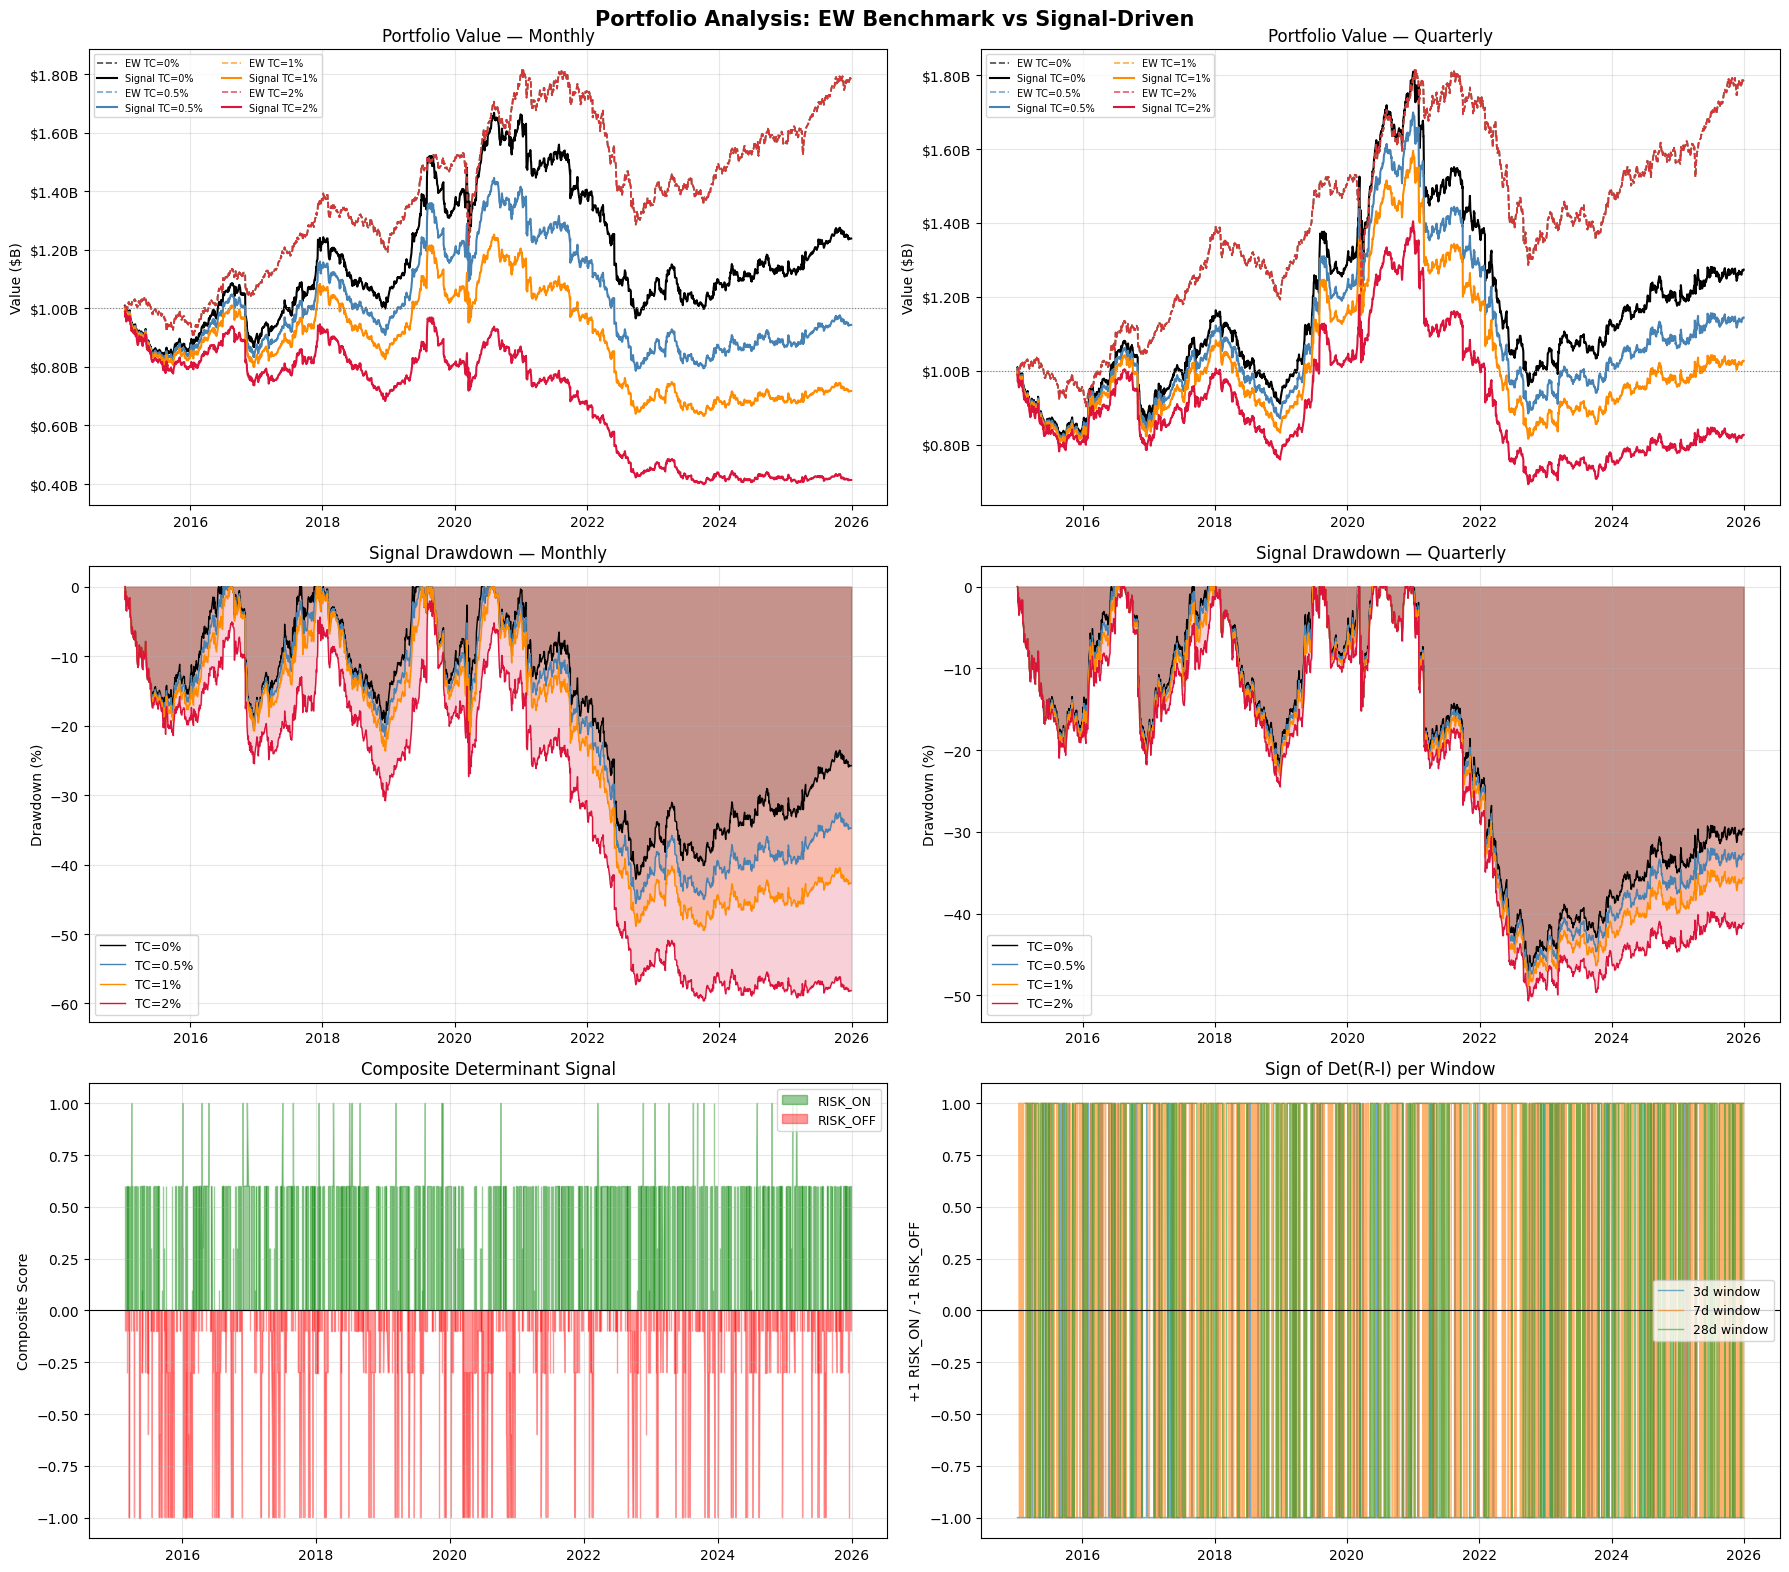

✓ Plot saved.
✓ All files saved.


In [38]:
# ============================================================
# SIGNAL PORTFOLIO — FULL SELF-CONTAINED VERSION
# Signals generated from Modified Determinant Model
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import requests
from io import StringIO

# ── 1. LOAD ALL DATA FROM GITHUB ─────────────────────────────────────────────
GITHUB_BASE = "https://raw.githubusercontent.com/kboroz/MSFE_Capstone_Project/main/01_Data/Streamlined/"

INDEX_FILE_MAP = {
    'ASX50':       'streamlined_asx_50.csv',
    'EUROSTOXX50': 'streamlined_euro_stoxx_50.csv',
    'FTSE100':     'streamlined_ftse_100.csv',
    'Ibovespa':    'streamlined_ibovespa.csv',
    'JSE40':       'streamlined_jse_top_40.csv',
    'NIKKEI225':   'streamlined_nikkei_225.csv',
    'SP500':       'streamlined_s&p_500.csv',
}

MACRO_FILE = 'streamlined_macro.csv'

def load_csv(url):
    r = requests.get(url)
    r.raise_for_status()
    df = pd.read_csv(StringIO(r.text), index_col=0, parse_dates=True)
    df.columns = df.columns.str.replace('[^a-zA-Z0-9]', '_', regex=True)
    return df.sort_index()

# Load macro
macro_df = load_csv(GITHUB_BASE + MACRO_FILE)
macro_df = macro_df[~macro_df.index.duplicated(keep='first')].sort_index()
print(f"macro_df shape : {macro_df.shape}")
print(f"Columns        : {macro_df.columns.tolist()}")

# Load individual index files (multi-column — OHLCV style)
index_data = {}
for name, fname in INDEX_FILE_MAP.items():
    try:
        df = load_csv(GITHUB_BASE + fname)
        index_data[name] = df
        print(f"✓ {name:15s} | shape={df.shape} | cols={df.columns.tolist()[:4]}")
    except Exception as e:
        print(f"✗ {name}: {e}")

# ── 2. EXTRACT PRICE SERIES FOR SIGNAL GENERATION ────────────────────────────
PRICE_COLS = ['Close', 'close', 'Price', 'price', 'Adj_Close', 'Last']

def get_price_series(df, name):
    col = next((c for c in PRICE_COLS if c in df.columns), df.columns[0])
    s   = pd.to_numeric(df[col], errors='coerce').dropna()
    print(f"  {name}: using column '{col}'")
    return s

index_prices = {}
for name, df in index_data.items():
    index_prices[name] = get_price_series(df, name)

# ── 3. MODIFIED DETERMINANT SIGNAL MODEL ─────────────────────────────────────
# Uses rolling correlation matrix of returns
# Signal = sign of det(R - I)
# RISK_ON  (+1) : det < 0  (correlations below identity — diversified)
# RISK_OFF (-1) : det >= 0 (correlations elevated — systemic risk)

DET_WINDOWS    = [3, 7, 28]
WINDOW_WEIGHTS = {3: 0.20, 7: 0.35, 28: 0.45}

def compute_modified_determinant(price_series_dict, windows=DET_WINDOWS):
    """
    For each window, compute rolling det(R - I) across all indices.
    Returns dict: {window: pd.DataFrame with columns per index and det column}
    """
    # Build returns dataframe from all indices
    prices = pd.DataFrame(price_series_dict).sort_index()
    rets   = prices.pct_change().dropna()

    det_results = {}

    for window in windows:
        det_series = []

        for i in range(window, len(rets)):
            window_rets = rets.iloc[i - window: i]

            # Drop columns with zero variance
            valid_cols = window_rets.columns[window_rets.std() > 1e-10]
            w = window_rets[valid_cols]

            if len(valid_cols) < 2:
                det_series.append(np.nan)
                continue

            try:
                R   = w.corr().values
                I   = np.eye(len(R))
                M   = R - I
                det = np.linalg.det(M)
            except Exception:
                det = np.nan

            det_series.append(det)

        idx = rets.index[window:]
        det_results[window] = pd.Series(det_series, index=idx, name=f'det_{window}d')
        print(f"  Window {window:2d}d | computed {len(det_series)} observations")

    return det_results

print("\n── Computing Modified Determinant ──")
det_results = compute_modified_determinant(index_prices)

# ── 4. GENERATE COMPOSITE SIGNAL PER INDEX ───────────────────────────────────
# For portfolio use we need per-index signals
# We compute each index's contribution by leaving it out (LOO) OR
# simply use the global composite score to drive all equity signals uniformly

def compute_composite_signal(det_results, window_weights=WINDOW_WEIGHTS):
    """
    Weighted average of sign across windows.
    Returns a Series of composite scores (between -1 and +1).
    Score > 0  → RISK_ON  → go long  (+1)
    Score <= 0 → RISK_OFF → go short (-1)
    """
    # Align all windows to common dates
    all_series = []
    for window, series in det_results.items():
        sign = np.sign(series).rename(f'sign_{window}d')
        all_series.append(sign)

    sign_df = pd.concat(all_series, axis=1).dropna()

    # Weighted composite
    composite = sum(
        sign_df[f'sign_{w}d'] * window_weights[w]
        for w in window_weights if f'sign_{w}d' in sign_df.columns
    )
    composite = composite / sum(window_weights.values())

    return composite, sign_df

composite_score, sign_df = compute_composite_signal(det_results)

print(f"\nComposite signal shape : {composite_score.shape}")
print(f"Date range             : {composite_score.index[0].date()} → "
      f"{composite_score.index[-1].date()}")
print(f"Score range            : {composite_score.min():.3f} → "
      f"{composite_score.max():.3f}")

# ── 5. BUILD SIGNAL DATAFRAME FOR PORTFOLIO ───────────────────────────────────
# Convert composite score to +1 / -1 per equity index
# We apply the SAME global signal to all equity indices
# (You can replace this with per-index LOO signals later)

EQUITY_ASSETS = list(index_prices.keys())  # indices we have signal data for

def build_signal_df(composite_score, equity_assets, macro_dates,
                    risk_on_threshold=0.0):
    """
    composite_score > threshold  → RISK_ON  → +1 (long)
    composite_score <= threshold → RISK_OFF → -1 (short)
    Reindexed to macro_dates with forward fill.
    """
    binary_signal = composite_score.apply(
        lambda x: 1 if x > risk_on_threshold else -1
    )

    signal_df = pd.DataFrame(index=macro_dates)
    for asset in equity_assets:
        aligned = binary_signal.reindex(macro_dates).ffill().bfill()
        signal_df[asset] = aligned

    return signal_df

signal_df = build_signal_df(composite_score, EQUITY_ASSETS, macro_df.index)

print(f"\nsignal_df shape : {signal_df.shape}")
print(f"Columns         : {signal_df.columns.tolist()}")
print(f"\nSignal distribution:")
for col in signal_df.columns:
    n_long  = (signal_df[col] == 1).sum()
    n_short = (signal_df[col] == -1).sum()
    print(f"  {col:15s} | LONG(+1): {n_long:4d} | SHORT(-1): {n_short:4d}")

# ── 6. DEFINE ASSET UNIVERSE ──────────────────────────────────────────────────
SAFE_BONDS = ['US_10Y', 'UK_10Y', 'AU_10Y', 'ZA_10Y']
FX         = ['AUDUSD', 'BRLUSD', 'EURUSD', 'GBPUSD', 'JPYUSD', 'ZARUSD']
COMMODITIES = ['Oil', 'Gold', 'Bitcoin']

ALL_ASSETS = EQUITY_ASSETS + FX + COMMODITIES + SAFE_BONDS
ALL_ASSETS = [a for a in ALL_ASSETS if a in macro_df.columns]

# Equity assets = those with signals AND in macro_df
equity_assets     = [a for a in EQUITY_ASSETS if a in ALL_ASSETS
                     and a in signal_df.columns]
non_equity_assets = [a for a in ALL_ASSETS if a not in equity_assets]

N           = len(ALL_ASSETS)
base_weight = 1.0 / N

print(f"\nTotal assets              : {N}")
print(f"Equity (signal-driven)    : {equity_assets}")
print(f"Non-equity (always long)  : {non_equity_assets}")
print(f"base_weight = 1/{N} = {base_weight:.4f}")

# ── 7. BUILD RETURNS ──────────────────────────────────────────────────────────
returns_raw = macro_df[ALL_ASSETS].pct_change(fill_method=None)

# Invert bond yields
for col in SAFE_BONDS:
    if col in returns_raw.columns:
        returns_raw[col] = -returns_raw[col]

# Fix Oil negative price days
if 'Oil' in macro_df.columns:
    bad_oil = macro_df['Oil'][macro_df['Oil'] <= 0].index
    for d in bad_oil:
        loc = returns_raw.index.get_loc(d)
        returns_raw.iloc[
            max(0, loc - 1): loc + 2,
            returns_raw.columns.get_loc('Oil')
        ] = 0.0

# Clip, fill, drop first row
returns = returns_raw.clip(lower=-0.50, upper=1.00).fillna(0).iloc[1:]

assert not returns.isnull().any().any(), "NaNs in returns"
assert not np.isinf(returns.values).any(), "Inf in returns"
print(f"\nReturns shape : {returns.shape}")
print("✓ Returns clean")

# ── 8. WEIGHT BUILDER ─────────────────────────────────────────────────────────
def build_weights(sig_row, equity_assets, non_equity_assets, base_weight, date):
    raw = {}

    for a in non_equity_assets:
        raw[a] = base_weight

    for a in equity_assets:
        if sig_row is not None and a in sig_row.index and not pd.isna(sig_row[a]):
            raw[a] = base_weight if sig_row[a] >= 0 else -base_weight
        else:
            raw[a] = base_weight

    # Reinvest short proceeds into long positions
    short_proceeds = sum(abs(w) for w in raw.values() if w < 0)
    long_assets    = [a for a, w in raw.items() if w > 0]
    n_long         = len(long_assets)

    if short_proceeds > 0 and n_long > 0:
        extra = short_proceeds / n_long
        for a in long_assets:
            raw[a] += extra

    total = sum(raw.values())
    if abs(total - 1.0) > 1e-6:
        raise ValueError(f"Weights sum to {total:.8f} on {date}")

    return raw

# ── 9. EQUAL-WEIGHT BENCHMARK ─────────────────────────────────────────────────
def build_weights(sig_row, equity_assets, non_equity_assets, base_weight, date):
    raw = {}

    for a in non_equity_assets:
        raw[a] = base_weight

    for a in equity_assets:
        if sig_row is not None and a in sig_row.index and not pd.isna(sig_row[a]):
            # FLIPPED: signal +1 (was RISK_ON) → now SHORT, signal -1 (was RISK_OFF) → now LONG
            raw[a] = base_weight if sig_row[a] < 0 else -base_weight
        else:
            raw[a] = base_weight

    # Reinvest short proceeds into long positions
    short_proceeds = sum(abs(w) for w in raw.values() if w < 0)
    long_assets    = [a for a, w in raw.items() if w > 0]
    n_long         = len(long_assets)

    if short_proceeds > 0 and n_long > 0:
        extra = short_proceeds / n_long
        for a in long_assets:
            raw[a] += extra
    elif short_proceeds > 0 and n_long == 0:
        for a in raw:
            raw[a] = 1.0 / len(raw)

    total = sum(raw.values())
    if total <= 0:
        for a in raw:
            raw[a] = 1.0 / len(raw)
    else:
        for a in raw:
            raw[a] = raw[a] / total

    return raw



# ── 10. SIGNAL-DRIVEN PORTFOLIO ───────────────────────────────────────────────
def run_signal_portfolio(returns, signal_df, equity_assets, non_equity_assets,
                          all_assets, freq='monthly', tc_rate=0.005,
                          initial_capital=1e9):

    N           = len(all_assets)
    base_weight = 1.0 / N

    freq_code     = 'MS' if freq == 'monthly' else 'QS'
    reb_dates_raw = returns.resample(freq_code).first().index
    actual_dates  = returns.index

    reb_set = set()
    for d in reb_dates_raw:
        future = actual_dates[actual_dates >= d]
        if len(future) > 0:
            reb_set.add(future[0])

    sig = signal_df.copy()
    sig.index = pd.to_datetime(sig.index)

    pv              = float(initial_capital)
    current_weights = None
    records         = []

    for date in actual_dates:
        if date in reb_set:
            past    = sig[sig.index <= date]
            sig_row = past.iloc[-1] if len(past) > 0 else None

            raw = build_weights(
                sig_row, equity_assets, non_equity_assets, base_weight, date
            )

            if current_weights is not None:
                all_keys = set(raw) | set(current_weights)
                turnover = sum(
                    abs(raw.get(a, 0) - current_weights.get(a, 0))
                    for a in all_keys
                ) / 2.0
                tc = turnover * tc_rate
            else:
                tc = tc_rate

            pv             *= (1 - tc)
            current_weights = raw.copy()

        if current_weights is not None:
            dr  = sum(current_weights.get(a, 0) * returns.loc[date, a]
                      for a in all_assets)
            pv *= (1 + dr)

        records.append({'date': date, 'portfolio_value': pv})

    return pd.DataFrame(records).set_index('date')

# ── 11. RUN ALL PORTFOLIOS ────────────────────────────────────────────────────
TC_LEVELS = {'0%': 0.00, '0.5%': 0.005, '1%': 0.01, '2%': 0.02}
FREQS     = ['monthly', 'quarterly']

ew_results = {}
for freq in FREQS:
    for tc_label, tc_rate in TC_LEVELS.items():
        label = f"EW_{freq}_TC{tc_label}"
        ew_results[label] = run_equal_weight(
            returns, ALL_ASSETS, tc_rate=tc_rate,
            rebal_freq=freq, initial_capital=1e9
        )
        print(f"✓ {label}")

signal_results = {}
for freq in FREQS:
    for tc_label, tc_rate in TC_LEVELS.items():
        label = f"Signal_{freq}_TC{tc_label}"
        signal_results[label] = run_signal_portfolio(
            returns, signal_df, equity_assets, non_equity_assets,
            ALL_ASSETS, freq=freq, tc_rate=tc_rate, initial_capital=1e9
        )
        print(f"✓ {label}")

print("\n✓ All portfolios computed")

# ── 12. PERFORMANCE METRICS ───────────────────────────────────────────────────
def compute_metrics(pv_series):
    pv        = pv_series['portfolio_value']
    daily_ret = pv.pct_change().dropna()
    n_years   = len(daily_ret) / 252
    total_ret = (pv.iloc[-1] / pv.iloc[0]) - 1
    cagr      = (1 + total_ret) ** (1 / n_years) - 1 if n_years > 0 else np.nan
    vol       = daily_ret.std() * np.sqrt(252)
    sharpe    = cagr / vol if vol > 0 else np.nan
    roll_max  = pv.cummax()
    max_dd    = ((pv - roll_max) / roll_max).min()
    calmar    = cagr / abs(max_dd) if max_dd != 0 else np.nan
    var_95    = daily_ret.quantile(0.05)

    return {
        'CAGR':         f"{cagr*100:.2f}%",
        'Volatility':   f"{vol*100:.2f}%",
        'Sharpe':       f"{sharpe:.2f}",
        'Max Drawdown': f"{max_dd*100:.2f}%",
        'Calmar':       f"{calmar:.2f}",
        'VaR 95%':      f"{var_95*100:.2f}%",
        'Total Return': f"{total_ret*100:.2f}%",
        'Final ($B)':   f"{pv.iloc[-1]/1e9:.3f}",
    }

print("\n" + "="*80)
print("EQUALLY-WEIGHTED BENCHMARK")
print("="*80)
ew_metrics = {k: compute_metrics(v) for k, v in ew_results.items()}
print(pd.DataFrame(ew_metrics).T.to_string())

print("\n" + "="*80)
print("SIGNAL-DRIVEN PORTFOLIO")
print("="*80)
sig_metrics = {k: compute_metrics(v) for k, v in signal_results.items()}
print(pd.DataFrame(sig_metrics).T.to_string())

# ── 13. DIAGNOSTIC: SIGNAL ACTIVITY ──────────────────────────────────────────
print("\n" + "="*80)
print("SIGNAL ACTIVITY SUMMARY")
print("="*80)
print(f"\nComposite score stats:\n{composite_score.describe()}")
print(f"\nSign distribution:")
print(f"  RISK_ON  (+1): {(composite_score > 0).sum()} days")
print(f"  RISK_OFF (-1): {(composite_score <= 0).sum()} days")

# ── 14. PLOTS ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 2, figsize=(18, 16))
fig.suptitle("Portfolio Analysis: EW Benchmark vs Signal-Driven",
             fontsize=15, fontweight='bold')

colors = {'0%': 'black', '0.5%': 'steelblue', '1%': 'darkorange', '2%': 'crimson'}

# Row 1: Portfolio values
for col_idx, freq in enumerate(FREQS):
    ax = axes[0][col_idx]
    for tc_label in TC_LEVELS:
        ew_pv  = ew_results[f"EW_{freq}_TC{tc_label}"]['portfolio_value']
        sig_pv = signal_results[f"Signal_{freq}_TC{tc_label}"]['portfolio_value']
        ax.plot(ew_pv.index,  ew_pv  / 1e9, '--',
                color=colors[tc_label], lw=1.2, alpha=0.7, label=f"EW TC={tc_label}")
        ax.plot(sig_pv.index, sig_pv / 1e9,
                color=colors[tc_label], lw=1.5, label=f"Signal TC={tc_label}")
    ax.axhline(1.0, color='grey', ls=':', lw=0.8)
    ax.set_title(f"Portfolio Value — {freq.capitalize()}", fontsize=12)
    ax.set_ylabel("Value ($B)")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.2f}B"))
    ax.legend(fontsize=7, ncol=2)
    ax.grid(True, alpha=0.3)

# Row 2: Drawdowns
for col_idx, freq in enumerate(FREQS):
    ax = axes[1][col_idx]
    for tc_label in TC_LEVELS:
        sig_pv = signal_results[f"Signal_{freq}_TC{tc_label}"]['portfolio_value']
        dd     = (sig_pv - sig_pv.cummax()) / sig_pv.cummax() * 100
        ax.fill_between(dd.index, dd.values, 0,
                        alpha=0.2, color=colors[tc_label])
        ax.plot(dd.index, dd.values,
                color=colors[tc_label], lw=1.0, label=f"TC={tc_label}")
    ax.set_title(f"Signal Drawdown — {freq.capitalize()}", fontsize=12)
    ax.set_ylabel("Drawdown (%)")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

# Row 3: Composite signal over time
ax = axes[2][0]
ax.fill_between(composite_score.index, composite_score.values, 0,
                where=(composite_score > 0), color='green', alpha=0.4, label='RISK_ON')
ax.fill_between(composite_score.index, composite_score.values, 0,
                where=(composite_score <= 0), color='red', alpha=0.4, label='RISK_OFF')
ax.axhline(0, color='black', lw=0.8)
ax.set_title("Composite Determinant Signal", fontsize=12)
ax.set_ylabel("Composite Score")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Row 3: Signal transitions per window
ax = axes[2][1]
for window, series in det_results.items():
    sign = np.sign(series)
    ax.plot(sign.index, sign.values, alpha=0.6,
            label=f"{window}d window", lw=1.0)
ax.axhline(0, color='black', lw=0.8)
ax.set_title("Sign of Det(R-I) per Window", fontsize=12)
ax.set_ylabel("+1 RISK_ON / -1 RISK_OFF")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("signal_vs_ew_portfolio.png", dpi=150, bbox_inches='tight')
plt.show()
print("✓ Plot saved.")

# ── 15. SAVE ──────────────────────────────────────────────────────────────────
for label, df in {**ew_results, **signal_results}.items():
    df.to_csv(f"{label}_portfolio.csv")

all_metrics = pd.DataFrame({**ew_metrics, **sig_metrics}).T
all_metrics.to_csv("all_portfolio_metrics.csv")

composite_score.to_csv("composite_signal.csv")
signal_df.to_csv("signal_df_packaged.csv")

print("✓ All files saved.")
